# Previsão Antecipada do Tempo de Internamento na UCI: Engenharia de Dados e Preparação para Machine Learning no MIMIC-III

## Fase 1: Arquitetura, Extração, Limpeza e Preparação dos Dados

**Estudantes:** Beatriz Seabra, Iara Ferreira  
**Instituição:** Faculdade de Ciências da Universidade do Porto (FCUP)  
**Curso:** Licenciatura em Inteligência Artificial e Ciência de Dados  
**Dataset:** MIMIC-III (Medical Information Mart for Intensive Care)


## 0. Introdução e Contextualização do Problema

O **MIMIC-III** é uma base de dados relacional que contém dados clínicos anonimizados de pacientes internados em Unidades de Cuidados Intensivos (UCI). A informação encontra-se distribuída por várias tabelas interligadas através de identificadores como `SUBJECT_ID`, `HADM_ID`, `ICUSTAY_ID` e `ITEMID`.

No contexto de uma UCI, a capacidade de antecipar o tempo provável de internamento de um doente pode apoiar a gestão de camas, a alocação de recursos hospitalares, o planeamento clínico e a organização das equipas. Um modelo capaz de estimar o **tempo de internamento na UCI** (*Length of Stay*: `LOS`) a partir de informação disponível nas primeiras horas após a admissão pode contribuir para uma tomada de decisão mais atempada e informada.

O objetivo global deste projeto é desenvolver uma pipeline de Machine Learning para prever o `LOS` na UCI. Nesta primeira fase, o foco está na construção de uma matriz preditiva limpa, coerente e pronta para modelação, utilizando principalmente sinais clínicos registados na tabela `CHARTEVENTS`, informação temporal da tabela `ICUSTAYS` e dados demográficos da tabela `PATIENTS`.

Uma decisão metodológica central consiste em considerar a **estadia na UCI** como unidade principal de análise. Assim, cada observação da matriz final corresponde a um `ICUSTAY_ID`, e não apenas a um `SUBJECT_ID`, uma vez que um mesmo paciente pode ter várias admissões hospitalares e várias estadias em UCI.


### Questões de Investigação

1. É possível construir uma matriz preditiva para estimar o `LOS` em UCI usando apenas informação disponível nas primeiras horas após a admissão?
2. Qual é o melhor compromisso entre antecipação da previsão e disponibilidade de informação clínica: uma janela temporal de 24h, 48h ou 72h?
3. Que sinais clínicos apresentam maior relação exploratória com o tempo de internamento na UCI?
4. Que impacto têm as decisões de pré-processamento, limpeza de dados e agregação temporal na qualidade da matriz final de Machine Learning?


### Estrutura da Fase 1

```text
Fase 1
├── Configuração da infraestrutura em Google Cloud Platform e BigQuery
├── Extração e validação estrutural das tabelas necessárias
├── Seleção e validação semântica dos ITEMIDs com recurso à tabela D_ITEMS
├── Cruzamento relacional entre CHARTEVENTS, ICUSTAYS e PATIENTS
├── Feature engineering temporal e demográfico
├── Limpeza, descodificação semântica e tratamento de valores fisiologicamente inválidos
├── Análise exploratória dos dados e caracterização da amostra
├── Análise comparativa de janelas temporais: 24h, 48h e 72h
├── Construção da feature matrix agregada por ICUSTAY_ID
├── Análise de valores em falta e preparação da estratégia de imputação
├── Profiling de performance e tempos de execução
└── Output final: matriz preditiva pronta para a Fase 2

## 1. Configuração do Ambiente e Autenticação GCP

### 1.1 Bibliotecas Utilizadas

| Biblioteca | Versão | Papel no Pipeline |
|---|---:|---|
| `google-cloud-bigquery` | ≥ 3.x | Ligação entre o notebook e o Data Warehouse no BigQuery |
| `pandas` | ≥ 1.5 | Manipulação local de DataFrames após extração e filtragem dos dados |
| `numpy` | ≥ 1.23 | Operações numéricas vetorizadas |
| `matplotlib` | ≥ 3.6 | Construção de visualizações base |
| `seaborn` | ≥ 0.12 | Visualizações estatísticas e exploratórias |
| `time` | stdlib | Medição de tempos de execução e apoio ao profiling |
| `warnings` | stdlib | Controlo de avisos durante a execução do notebook |

### 1.2 Protocolo de Autenticação

Dado que o ficheiro `CHARTEVENTS.csv.gz` possui uma dimensão elevada, o processamento inicial dos dados foi realizado no **Google BigQuery**, evitando carregar a tabela completa diretamente para a memória local do Google Colab.

A autenticação foi realizada através da Google Cloud CLI. Esta opção foi escolhida porque, em alguns ambientes Colab, o método `auth.authenticate_user()` pode ser bloqueado por restrições de *cross-origin* associadas a *iframes* do browser.

Assim, foi utilizado o seguinte comando:

```bash
gcloud auth application-default login --no-launch-browser

In [1]:
%%time
import time
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.cloud import bigquery

# Autenticação via CLI
!gcloud auth application-default login --no-launch-browser
!gcloud auth application-default set-quota-project myproject20939

# Configuração global
PROJECT_ID = 'myproject20939'
DATASET = 'dataset_icu'
client = bigquery.Client(project=PROJECT_ID)

# Paleta de cores consistente
PALETTE = {
    'primary': '#6A0DAD',
    'secondary': '#2E86AB',
    'accent': '#E07B39',
    'neutral': '#4A4E69',
    'danger': '#C1292E',
    'success': '#2D6A4F',
}

sns.set_theme(style='whitegrid', font_scale=1.05)

print(f"Ambiente configurado. Ligado ao projeto: {PROJECT_ID}")
print(f"Dataset alvo: {PROJECT_ID}.{DATASET}")

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=sNuiA95Qyj7SMmggR5BQWVhebkrgTe&prompt=consent&token_usage=remote&access_type=offline&code_challenge=_yZCzrIkQfAdcaXyOPIqpiDcflLMwSTRWaf2tKGiKWY&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AeoWuM95ynsTxoQ4y-V2GZ_uPheghjyXHpHkUHfW_Y4DZcgpE37M1vilxWrkEjrS7DdmfA

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

### 1.3 Cronómetro Global do Pipeline

Para monitorizar a eficiência computacional e o custo de processamento da pipeline de dados, é iniciado neste ponto um cronómetro global. O tempo total de execução será registado no final da Fase 1, permitindo avaliar o esforço computacional associado às etapas de extração, limpeza, análise exploratória e construção da matriz preditiva.

In [2]:
import time
PIPELINE_START = time.time()  # Cronómetro global
print(f"Cronómetro global iniciado.")

Cronómetro global iniciado.


## 2. Arquitetura de Dados: Tabelas Selecionadas e Excluídas

O MIMIC-III é uma base de dados relacional composta por múltiplas tabelas clínicas, administrativas e de dicionário. Como o objetivo deste trabalho é prever o tempo de internamento na UCI a partir de informação disponível numa janela inicial, foi necessário selecionar apenas as tabelas relevantes para a construção da matriz preditiva e para a análise exploratória exigida pelo enunciado.

A estratégia adotada privilegia três critérios principais:

1. **Disponibilidade temporal**, evitando variáveis que possam incorporar informação posterior ao momento da previsão;
2. **Comparabilidade entre estadias**, favorecendo variáveis estruturadas e fisiológicas presentes em grande parte da amostra;
3. **Eficiência computacional**, reduzindo o volume de dados processado localmente após a extração inicial no BigQuery.

### 2.1 Estrutura Central Preditiva: Tabelas Consideradas

| Tabela | Papel no Trabalho | Chaves Relevantes |
|---|---|---|
| `CHARTEVENTS` | Fonte principal de observações clínicas estruturadas registadas durante a estadia na UCI | `SUBJECT_ID`, `HADM_ID`, `ICUSTAY_ID`, `ITEMID`, `CHARTTIME`, `VALUENUM` |
| `ICUSTAYS` | Definição das estadias na UCI, tempos de entrada/saída e variável-alvo `LOS` | `SUBJECT_ID`, `HADM_ID`, `ICUSTAY_ID`, `INTIME`, `OUTTIME`, `LOS` |
| `PATIENTS` | Informação demográfica do paciente, usada para calcular idade e género | `SUBJECT_ID`, `GENDER`, `DOB` |
| `ADMISSIONS` | Contexto da admissão hospitalar; usada para validação relacional e enquadramento da estrutura `HADM_ID` | `SUBJECT_ID`, `HADM_ID`, `ADMITTIME`, `DIAGNOSIS` |
| `D_ITEMS` | Dicionário semântico dos `ITEMID`s usados em `CHARTEVENTS` e `INPUTEVENTS_MV` | `ITEMID`, `LABEL`, `CATEGORY`, `UNITNAME` |
| `INPUTEVENTS_MV` | Usada apenas para a visualização exploratória obrigatória do enunciado relativa aos eventos de input da estadia `ICUSTAY_ID = 200072`; não integrada na matriz preditiva final | `ICUSTAY_ID`, `ITEMID`, `STARTTIME`, `AMOUNT` |

> **Nota sobre a unidade temporal:**  
> A separação entre `ADMISSIONS` e `ICUSTAYS` é essencial. `ADMISSIONS` representa o internamento hospitalar geral, enquanto `ICUSTAYS` representa uma estadia específica na UCI. Como o objetivo é prever o tempo de internamento na UCI, a referência temporal correta é `ICUSTAYS.INTIME`, e não `ADMISSIONS.ADMITTIME`.

> **Nota sobre `INPUTEVENTS_MV`:**  
> A tabela `INPUTEVENTS_MV` foi utilizada apenas para responder ao requisito visual do enunciado relativo aos eventos de input de uma estadia específica (`ICUSTAY_ID = 200072`). A matriz preditiva final não inclui features derivadas desta tabela, porque `INPUTEVENTS_MV` cobre apenas o subconjunto MetaVision e poderia introduzir heterogeneidade adicional entre sistemas. Assim, a matriz final foi construída a partir de `CHARTEVENTS`, `ICUSTAYS`, `PATIENTS` e `D_ITEMS`, mantendo variáveis fisiológicas mais comparáveis entre CareVue e MetaVision.

### 2.2 Tabelas Excluídas: Critérios de Exclusão

**Critério 1: Prevenção de Data Leakage**

Tabelas como `DIAGNOSES_ICD`, `CPTEVENTS`, `DRGCODES` e `PROCEDURES_ICD` foram excluídas porque contêm informação de diagnóstico, procedimentos ou faturação que pode ser registada ou consolidada após a evolução clínica do internamento. A sua inclusão poderia introduzir informação não disponível no momento da previsão e comprometer a validade temporal do modelo.

**Critério 2: Âmbito e Latência Clínica**

Tabelas como `LABEVENTS` e `MICROBIOLOGYEVENTS` contêm informação clinicamente relevante, mas foram excluídas nesta fase para manter o foco nos sinais clínicos estruturados de `CHARTEVENTS`. Além disso, algumas medições laboratoriais e microbiológicas podem ter latência variável, dependendo do tipo de exame e do tempo de processamento. A sua inclusão exigiria uma análise temporal adicional para garantir que apenas resultados efetivamente disponíveis dentro da janela inicial fossem usados.

**Critério 3: Dados Não Estruturados, Logísticos ou de Maior Complexidade**

`NOTEEVENTS` foi excluída por conter texto clínico não estruturado, cuja utilização exigiria técnicas de Processamento de Linguagem Natural. Tabelas como `TRANSFERS`, `CALLOUT` e `SERVICES` foram excluídas para evitar que informação logística ou administrativa influenciasse diretamente a previsão. `PRESCRIPTIONS` também não foi incluída nesta fase, uma vez que representa medicação prescrita e não necessariamente administrada, exigindo tratamento adicional para distinguir intenção clínica de execução efetiva.

### 2.3 Infraestrutura GCP: Diagrama de Fluxo

```text
                                  Google Cloud Storage           Google BigQuery
Fonte de Dados                   (gs://meu-bucket-beatriz)      (dataset_icu)
       │                                │                             │
CHARTEVENTS.csv.gz ──── wget ──────────►│──── bq load ────────────► chartevents
PATIENTS.csv.gz ─────── wget ──────────►│──── bq load ────────────► patients
ADMISSIONS.csv.gz ───── wget ──────────►│──── bq load ────────────► admissions
ICUSTAYS.csv.gz ─────── wget ──────────►│──── bq load ────────────► icustays
D_ITEMS.csv.gz ──────── wget ──────────►│──── bq load ────────────► d_items
INPUTEVENTS_MV.csv.gz ─ wget ──────────►│──── bq load ────────────► inputevents_mv
                                                                       │
                                                                 Google Colab
                                                                 SQL queries via SDK
                                                                 pandas para análise local
```

### 2.4 Configurações de Carga no BigQuery

- **Schema manual como `STRING`:** as colunas foram inicialmente carregadas como texto para reduzir falhas de tipo causadas por ruído ou inconsistências nos registos hospitalares. As conversões numéricas e temporais foram feitas posteriormente de forma controlada.

- **`header_rows_to_skip = 1`:** os cabeçalhos originais dos ficheiros CSV foram ignorados, uma vez que os nomes das colunas foram definidos manualmente.

- **`allow_quoted_newlines = True`:** esta opção foi usada para lidar com campos textuais que possam conter quebras de linha.

- **`max_bad_records = 10000`:** margem de tolerância usada durante a ingestão para evitar que um número reduzido de linhas problemáticas impedisse o carregamento de tabelas de grande dimensão.

### 2.5 Histórico de Comandos de Ingestão

> **Nota:** Os comandos abaixo documentam a extração inicial e transferência dos dados para a Google Cloud. Foram executados apenas uma vez. Como os dados já se encontram carregados no BigQuery, não é necessário reexecutar esta etapa para correr o notebook.

```bash
# Criação do bucket na Google Cloud
gcloud storage buckets create gs://meu-bucket-beatriz --location=EU

# Download dos dados
wget -c "http://www.dcc.fc.up.pt/~ines/MIMIC-III/CHARTEVENTS.csv.gz"
wget -c "http://www.dcc.fc.up.pt/~ines/MIMIC-III/PATIENTS.csv.gz"
wget -c "http://www.dcc.fc.up.pt/~ines/MIMIC-III/ADMISSIONS.csv.gz"
wget -c "http://www.dcc.fc.up.pt/~ines/MIMIC-III/ICUSTAYS.csv.gz"
wget -c "http://www.dcc.fc.up.pt/~ines/MIMIC-III/D_ITEMS.csv.gz"
wget -c "http://www.dcc.fc.up.pt/~ines/MIMIC-III/INPUTEVENTS_MV.csv.gz"

# Transferência dos ficheiros para o Cloud Storage
gcloud storage cp CHARTEVENTS.csv.gz     gs://meu-bucket-beatriz/
gcloud storage cp PATIENTS.csv.gz        gs://meu-bucket-beatriz/
gcloud storage cp ADMISSIONS.csv.gz      gs://meu-bucket-beatriz/
gcloud storage cp ICUSTAYS.csv.gz        gs://meu-bucket-beatriz/
gcloud storage cp D_ITEMS.csv.gz         gs://meu-bucket-beatriz/
gcloud storage cp INPUTEVENTS_MV.csv.gz  gs://meu-bucket-beatriz/
```

## 3. Validação Inicial de Estrutura (*Sanity Check*)

Antes de avançar para as agregações relacionais (*JOINs*) e para a construção da matriz analítica, foi realizada uma validação técnica inicial às 6 tabelas consideradas no trabalho. Esta etapa teve como objetivo confirmar que os dados foram corretamente carregados no BigQuery e identificar antecipadamente aspetos estruturais relevantes para o restante pipeline.

Esta validação cumpre três objetivos principais:

1. **Validação da infraestrutura:** confirmar a conectividade com o BigQuery, a disponibilidade das tabelas e a viabilidade de executar consultas SQL diretamente sobre o Data Warehouse.

2. **Caracterização inicial dos dados:** identificar particularidades do MIMIC-III, incluindo a anonimização temporal aplicada às datas, que podem surgir projetadas para anos futuros, e a heterogeneidade clínica dos registos, nomeadamente a coexistência de valores numéricos e qualitativos em campos como `VALUE`.

3. **Estatísticas de extração:** verificar a dimensão, cardinalidade e completude de cada tabela, analisando o número de linhas, número de colunas, identificadores principais e percentagem de valores em falta.

Esta etapa funciona como um controlo de qualidade inicial, permitindo detetar problemas de ingestão, inconsistências estruturais ou limitações de cobertura antes das fases de limpeza, cruzamento relacional e feature engineering.

In [3]:
%%time
import time
_t0 = time.time()

# Estatísticas de cada tabela extraída
tabelas_meta = {
    'chartevents':    {'desc': 'Biometria contínua da UCI',       'esperado': '>330M linhas'},
    'patients':       {'desc': 'Dados demográficos dos pacientes','esperado': '~46k linhas'},
    'admissions':     {'desc': 'Histórico de internamentos',      'esperado': '~58k linhas'},
    'icustays':       {'desc': 'Estadias específicas na UCI',     'esperado': '~61k linhas'},
    'd_items':        {'desc': 'Dicionário de ITEMIDs',           'esperado': '~12k linhas'},
    'inputevents_mv': {'desc': 'Fluidos e terapêutica (MetaVision)','esperado': '~3.6M linhas'}
}

# Consulta otimizada aos metadados (Zero-Byte Query)
query_meta = f"""
SELECT
    table_id,
    row_count,
    size_bytes / (1024*1024*1024) AS size_gb
FROM `{PROJECT_ID}.{DATASET}.__TABLES__`
WHERE table_id IN ('chartevents', 'patients', 'admissions', 'icustays', 'd_items', 'inputevents_mv')
ORDER BY row_count DESC
"""
# Tabela de descrição de cada uma das 6 tabelas que vão ser utilizadas
df_meta = client.query(query_meta).to_dataframe()

# Mapeamento do dicionário para validação
df_meta['descricao'] = df_meta['table_id'].map({k: v['desc'] for k, v in tabelas_meta.items()})
df_meta['esperado']  = df_meta['table_id'].map({k: v['esperado'] for k, v in tabelas_meta.items()})

# Formatação visual (espaços nos milhares e 2 casas decimais no GB)
df_meta['row_count'] = df_meta['row_count'].apply(lambda x: f"{x:,}".replace(',', ' '))
df_meta['size_gb']   = df_meta['size_gb'].apply(lambda x: f"{x:.2f} GB")

# Renomear colunas para apresentação
df_meta = df_meta.rename(columns={'table_id': 'tabela_bq', 'row_count': 'linhas_extraidas'})
colunas_ordem = ['tabela_bq', 'descricao', 'linhas_extraidas', 'esperado', 'size_gb']

print("DESCRIÇÃO DAS TABELAS NO BIGQUERY:\n")
display(df_meta[colunas_ordem])

# Amostra da tabela principal (CHARTEVENTS)
query_sample = f"""
SELECT
    SUBJECT_ID, HADM_ID, ICUSTAY_ID,
    ITEMID, CHARTTIME, VALUE, VALUEUOM
FROM `{PROJECT_ID}.{DATASET}.chartevents`
WHERE VALUE IS NOT NULL AND ICUSTAY_ID IS NOT NULL
LIMIT 5
"""
df_sample = client.query(query_sample).to_dataframe()

print(f"\nAMOSTRA CHARTEVENTS (5 linhas):")
display(df_sample)

print(f"\n Tempo Sanity Check: {time.time()-_t0:.1f}s")

DESCRIÇÃO DAS TABELAS NO BIGQUERY:



,tabela_bq,descricao,linhas_extraidas,esperado,size_gb
0,chartevents,Biometria contínua da UCI,330 712 483,>330M linhas,33.85 GB
1,inputevents_mv,Fluidos e terapêutica (MetaVision),3 618 991,~3.6M linhas,0.94 GB
2,icustays,Estadias específicas na UCI,61 532,~61k linhas,0.01 GB
3,admissions,Histórico de internamentos,58 976,~58k linhas,0.01 GB
4,patients,Dados demográficos dos pacientes,46 520,~46k linhas,0.00 GB
5,d_items,Dicionário de ITEMIDs,12 487,~12k linhas,0.00 GB



AMOSTRA CHARTEVENTS (5 linhas):


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,ITEMID,CHARTTIME,VALUE,VALUEUOM
0,30154,188029,225709,228096,2181-07-25 08:00:00,0 Alert and calm,None
1,51577,191473,250130,228096,2197-03-25 08:00:00,0 Alert and calm,None
2,40120,146466,283260,228096,2120-01-29 11:00:00,0 Alert and calm,None
3,42300,139006,224058,228096,2185-07-27 20:29:00,0 Alert and calm,None
4,48344,150713,214656,228096,2185-04-27 04:09:00,0 Alert and calm,None



 Tempo Sanity Check: 3.4s
CPU times: user 149 ms, sys: 25 ms, total: 175 ms
Wall time: 3.39 s


### 3.1 Análise da Validação de Estrutura

A validação inicial confirmou que as 6 tabelas necessárias foram corretamente carregadas no BigQuery e apresentam dimensões coerentes com a volumetria esperada após a ingestão. Destaca-se a dimensão da tabela `CHARTEVENTS`, com mais de 330 milhões de registos, o que justifica a utilização de BigQuery como camada principal de processamento antes da extração local para `pandas`.

A observação dos resultados permite identificar três características estruturais relevantes:

1. **Anonimização temporal:**  
   As datas observadas surgem projetadas para anos futuros, como 2104-2210. Esta característica resulta do processo de anonimização temporal aplicado ao MIMIC-III para proteção da identidade dos pacientes. Apesar da deslocação das datas absolutas, os intervalos temporais entre eventos são preservados, pelo que o cálculo de variáveis como tempo desde a admissão na UCI e `LOS` não é comprometido.

2. **Heterogeneidade de tipos na coluna `VALUE`:**  
   A amostra de `CHARTEVENTS` mostra que a coluna `VALUE` pode conter valores qualitativos, como `"0 Alert and calm"`, além de medições numéricas. Esta heterogeneidade valida a decisão de ingerir inicialmente as colunas como `STRING`, adiando a conversão numérica para etapas posteriores e mais controladas do pipeline.

3. **Presença de identificadores relacionais:**  
   A existência de chaves como `SUBJECT_ID`, `HADM_ID`, `ICUSTAY_ID` e `ITEMID` nos registos relevantes confirma a possibilidade de cruzar `CHARTEVENTS` com `ICUSTAYS`, `PATIENTS` e `D_ITEMS`. Esta estrutura é essencial para associar cada medição clínica à respetiva estadia na UCI, calcular a variável-alvo `LOS` e validar semanticamente os sinais clínicos através do dicionário de `ITEMID`s.

Assim, esta etapa confirma a integridade estrutural inicial do ambiente de dados e sustenta as decisões seguintes de filtragem, conversão de tipos, seleção de variáveis e construção da matriz preditiva.

### 3.2 Verificação da Qualidade dos Dados e Quantificação de Nulos

Nesta etapa é feita uma validação estrutural das 6 tabelas carregadas no BigQuery, com foco na dimensão das tabelas, nas chaves principais e na presença de valores nulos em campos relevantes.

Para reduzir o número de consultas ao BigQuery, as verificações foram consolidadas numa única query com `UNION ALL`. Como esta operação exige que todas as tabelas devolvam o mesmo formato de output, os valores nulos foram organizados nas colunas genéricas `Nulos_1` e `Nulos_2`.

A interpretação destas colunas depende da tabela analisada:

| Tabela | `Nulos_1` | `Nulos_2` |
|---|---|---|
| `chartevents` | `VALUE` | `ICUSTAY_ID` |
| `inputevents_mv` | `AMOUNT` | `ICUSTAY_ID` |
| `patients` | `GENDER` | `DOB` |
| `icustays` | `INTIME` | `LOS` |
| `admissions` | `HADM_ID` | Não aplicável |
| `d_items` | `LABEL` | Não aplicável |

In [4]:
%%time
import time
_t0 = time.time()


# Uso de UNION ALL para consolidar 6 pedidos num único job de BigQuery
query_qualidade = f"""
SELECT 'chartevents' AS Tabela, 'VALUE, ICUSTAY_ID' AS Colunas_Avaliadas, COUNT(*) AS Total, COUNTIF(VALUE IS NULL) AS Nulos_1, COUNTIF(ICUSTAY_ID IS NULL) AS Nulos_2 FROM `{PROJECT_ID}.{DATASET}.chartevents`
UNION ALL
SELECT 'inputevents_mv', 'AMOUNT, ICUSTAY_ID', COUNT(*), COUNTIF(AMOUNT IS NULL), COUNTIF(ICUSTAY_ID IS NULL) FROM `{PROJECT_ID}.{DATASET}.inputevents_mv`
UNION ALL
SELECT 'patients', 'GENDER, DOB', COUNT(*), COUNTIF(GENDER IS NULL), COUNTIF(DOB IS NULL) FROM `{PROJECT_ID}.{DATASET}.patients`
UNION ALL
SELECT 'admissions', 'HADM_ID', COUNT(*), COUNTIF(HADM_ID IS NULL), 0 FROM `{PROJECT_ID}.{DATASET}.admissions`
UNION ALL
SELECT 'icustays', 'INTIME, LOS', COUNT(*), COUNTIF(INTIME IS NULL), COUNTIF(LOS IS NULL) FROM `{PROJECT_ID}.{DATASET}.icustays`
UNION ALL
SELECT 'd_items', 'LABEL', COUNT(*), COUNTIF(LABEL IS NULL), 0 FROM `{PROJECT_ID}.{DATASET}.d_items`
"""

df_nulos = client.query(query_qualidade).to_dataframe()

# Formatação visual (adicionar separador de milhares para leitura fácil)
for col in ['Total', 'Nulos_1', 'Nulos_2']:
    df_nulos[col] = df_nulos[col].apply(lambda x: f"{x:,}".replace(',', ' ') if x > 0 else "-")

print("QUALIDADE DOS DADOS - NULOS NAS COLUNAS CRÍTICAS ")
display(df_nulos)

print(f"\n Tempo análise de nulos: {time.time()-_t0:.1f}s")

QUALIDADE DOS DADOS - NULOS NAS COLUNAS CRÍTICAS 


,Tabela,Colunas_Avaliadas,Total,Nulos_1,Nulos_2
0,admissions,HADM_ID,58 976,-,-
1,d_items,LABEL,12 487,3,-
2,patients,"GENDER, DOB",46 520,-,-
3,icustays,"INTIME, LOS",61 532,-,10
4,inputevents_mv,"AMOUNT, ICUSTAY_ID",3 618 991,-,1 164
5,chartevents,"VALUE, ICUSTAY_ID",330 712 483,2 071 349,297 529



 Tempo análise de nulos: 1.7s
CPU times: user 46.3 ms, sys: 6.3 ms, total: 52.6 ms
Wall time: 1.69 s


### 3.3 Interpretação da Qualidade dos Dados

A análise de nulos revela uma boa completude estrutural nas tabelas principais, permitindo avançar para as etapas de cruzamento relacional e construção da matriz preditiva.

As principais conclusões são:

- **Tabelas demográficas e administrativas:**  
  As tabelas `patients` e `admissions` não apresentam nulos nos campos críticos avaliados, o que confirma a sua adequação para cruzamento com as restantes tabelas através de `SUBJECT_ID` e `HADM_ID`.

- **Variável-alvo em `icustays`:**  
  A tabela `icustays` apresenta apenas 10 registos sem `LOS`, num total de 61 532 estadias UCI. Estes casos representam uma fração residual da amostra analisada e serão removidos antes da construção da matriz final, uma vez que não é possível treinar modelos supervisionados sem variável-alvo.

- **Nulos em `chartevents`:**  
  A tabela `chartevents` apresenta 2 071 349 valores nulos em `VALUE` e 297 529 registos sem `ICUSTAY_ID`, num universo de 330 712 483 linhas. Embora estes números absolutos sejam elevados, representam uma proporção reduzida da tabela total. Estes registos serão tratados nas etapas seguintes, através da conversão controlada de valores numéricos, exclusão de medições sem valor clínico utilizável e remoção de registos sem ligação direta a uma estadia UCI.

- **Dicionário `d_items`:**  
  A tabela `d_items` apresenta apenas 3 valores nulos em `LABEL`, o que não compromete a validação semântica dos `ITEMID`s selecionados.

Assim, esta validação confirma que as tabelas carregadas têm qualidade estrutural suficiente para prosseguir com o pipeline, sendo os principais problemas de completude concentrados em `chartevents`, como esperado numa tabela clínica de grande dimensão.

## 4. Seleção Clínica de Sinais Vitais via `D_ITEMS`

A tabela `CHARTEVENTS` regista observações clínicas através de identificadores numéricos (`ITEMID`). Como estes códigos não são diretamente interpretáveis, é necessário recorrer à tabela `D_ITEMS` para descodificar semanticamente cada variável e selecionar apenas os sinais clínicos relevantes para o problema.

Para garantir uma matriz preditiva coerente, a seleção dos sinais não deve ser arbitrária. Assim, o primeiro passo consistiu em analisar a frequência absoluta dos `ITEMID`s em `CHARTEVENTS`, permitindo identificar quais as variáveis mais representadas na base de dados e avaliar a sua relevância clínica.

### 4.1 Análise Exploratória de Frequência dos `ITEMID`s

In [5]:
%%time
import time
_t0 = time.time()

# Query para descobrir quais são os 15 sinais mais frequentemente registados
query_top_frequencia = f"""
SELECT
    c.ITEMID,
    d.LABEL,
    COUNT(*) as ocorrencias
FROM `{PROJECT_ID}.{DATASET}.chartevents` c
JOIN `{PROJECT_ID}.{DATASET}.d_items` d ON CAST(c.ITEMID AS STRING) = CAST(d.ITEMID AS STRING)
GROUP BY c.ITEMID, d.LABEL
ORDER BY ocorrencias DESC
LIMIT 15
"""

df_top_freq = client.query(query_top_frequencia).to_dataframe()

# Formatação visual
df_top_freq['ocorrencias'] = df_top_freq['ocorrencias'].apply(lambda x: f"{x:,}".replace(',', ' '))

print("TOP 15 ITEMIDs MAIS FREQUENTES NO MIMIC-III")
display(df_top_freq)

print(f"\n Tempo da análise de frequência: {time.time()-_t0:.1f}s")

TOP 15 ITEMIDs MAIS FREQUENTES NO MIMIC-III


,ITEMID,LABEL,ocorrencias
0,211,Heart Rate,5 180 809
1,742,calprevflg,3 464 326
2,646,SpO2,3 418 917
3,618,Respiratory Rate,3 386 719
4,212,Heart Rhythm,3 303 151
5,161,Ectopy Type,3 236 350
6,128,Code Status,3 216 866
7,550,Precautions,3 205 052
8,1125,Service Type,2 955 851
9,220045,Heart Rate,2 762 225



 Tempo da análise de frequência: 1.6s
CPU times: user 37.6 ms, sys: 4.06 ms, total: 41.7 ms
Wall time: 1.58 s


> **Conclusão da EDA:**  
> A análise do Top 15 mostra que uma seleção baseada apenas na frequência absoluta dos `ITEMID`s não seria adequada. Alguns registos muito frequentes, como `calprevflg`, `Code Status` ou `Risk for Falls`, correspondem a metadados, estados administrativos ou anotações clínicas/logísticas, e não a sinais fisiológicos contínuos diretamente úteis para a matriz preditiva.
>
> A tabela também evidencia a fragmentação estrutural do MIMIC-III: o mesmo sinal clínico pode surgir com diferentes `ITEMID`s, refletindo a coexistência dos sistemas CareVue e MetaVision. Por exemplo, `Heart Rate` aparece nos `ITEMID`s 211 e 220045. Esta observação justifica a necessidade de agrupar semanticamente `ITEMID`s equivalentes antes da construção das features.

### 4.2 Painel de Sinais Clínicos Selecionados

Para reduzir ruído, harmonizar a fragmentação entre sistemas e manter a interpretabilidade clínica da matriz preditiva, a seleção final dos sinais foi feita com base em frequência, relevância clínica e validação semântica através de `D_ITEMS`.

Foram retidos 11 sinais clínicos, combinando sinais vitais clássicos com componentes neurológicas da escala de Glasgow:

| Sinal Clínico | ITEMIDs CareVue | ITEMIDs MetaVision | Unidade / Escala |
|---|---:|---:|---|
| Frequência Cardíaca | 211 | 220045 | bpm |
| Pressão Arterial Sistólica | 51 | 220179 | mmHg |
| Pressão Arterial Diastólica | 8368 | 220180 | mmHg |
| Pressão Arterial Média | 456 | 220052 | mmHg |
| SpO₂ | 646 | 220277 | % |
| Temperatura | 678 | 223761 | °C após conversão |
| Frequência Respiratória | 618 | 220210 | rpm |
| GCS Total | 198 | — | score |
| GCS Eye Opening | — | 220739 | score |
| GCS Motor Response | — | 223901 | score |
| GCS Verbal Response | — | 223900 | score |

### 4.3 Implementação e Validação do Dicionário

Com a seleção clínica definida, o passo seguinte consiste em materializar esta lógica num dicionário de configuração (`SINAIS_VITAIS`). Este dicionário centraliza os `ITEMID`s selecionados, as unidades clínicas e os limites fisiológicos usados nas etapas posteriores de limpeza.

Esta célula cumpre três objetivos principais:

- **Mapeamento e unificação:** associa diferentes `ITEMID`s dos sistemas CareVue e MetaVision a uma única variável clínica padronizada, evitando que o mesmo sinal permaneça fragmentado em colunas distintas.

- **Definição de limites fisiológicos:** estabelece intervalos plausíveis para cada variável (`min_fisiologico` e `max_fisiologico`), permitindo remover valores incompatíveis com medições clínicas realistas ou resultantes de erros de registo.

- **Validação de integridade:** consulta a tabela `D_ITEMS` para confirmar que todos os `ITEMID`s definidos existem na base de dados e correspondem semanticamente aos sinais pretendidos.

> **Nota metodológica sobre os limites fisiológicos:**  
> Os limites usados para exclusão de outliers foram definidos com base em conhecimento clínico geral, práticas comuns de limpeza de séries temporais clínicas e valores de plausibilidade frequentemente usados em estudos com MIMIC-III. O objetivo não é remover valores clinicamente extremos por si só, mas sim excluir medições incompatíveis com a realidade fisiológica ou provavelmente resultantes de erro de registo, unidade ou codificação.

In [6]:
%%time
import time
_t0 = time.time()

# A MIMIC-III integra dados de dois sistemas: CareVue e MetaVision.
# Por isso, alguns conceitos clínicos aparecem com mais do que um ITEMID.
# O GCS Total foi separado das componentes do GCS para evitar misturar variáveis clinicamente diferentes.
# ITEMIDs associados a APACHE foram excluídos por serem scores derivados.

SINAIS_VITAIS = {
    'Heart Rate': {
        'itemids': [211, 220045],
        'unidade': 'bpm',
        'min_fisiologico': 1,
        'max_fisiologico': 300
    },

    'SBP': {
        'itemids': [51, 220179],
        'unidade': 'mmHg',
        'min_fisiologico': 1,
        'max_fisiologico': 375
    },

    'DBP': {
        'itemids': [8368, 220180],
        'unidade': 'mmHg',
        'min_fisiologico': 1,
        'max_fisiologico': 375
    },

    'MBP': {
        'itemids': [456, 220052],
        'unidade': 'mmHg',
        'min_fisiologico': 1,
        'max_fisiologico': 375
    },

    'SpO2': {
        'itemids': [646, 220277],
        'unidade': '%',
        'min_fisiologico': 1,
        'max_fisiologico': 100
    },

    'Temperature': {
        'itemids': [678, 223761],
        'unidade': '°F',
        'min_fisiologico': 70,
        'max_fisiologico': 120
    },

    'Respiratory Rate': {
        'itemids': [618, 220210],
        'unidade': 'rpm',
        'min_fisiologico': 1,
        'max_fisiologico': 70
    },

    'GCS Total': {
        'itemids': [198],
        'unidade': 'score',
        'min_fisiologico': 3,
        'max_fisiologico': 15
    },

    'GCS Eye Opening': {
        'itemids': [220739],
        'unidade': 'score',
        'min_fisiologico': 1,
        'max_fisiologico': 4
    },

    'GCS Motor Response': {
        'itemids': [223901],
        'unidade': 'score',
        'min_fisiologico': 1,
        'max_fisiologico': 6
    },

    'GCS Verbal Response': {
        'itemids': [223900],
        'unidade': 'score',
        'min_fisiologico': 1,
        'max_fisiologico': 5
    }
}

# Lista de items id
ALL_ITEMIDS = [
    str(iid)
    for sinal in SINAIS_VITAIS.values()
    for iid in sinal['itemids']
]

ALL_ITEMIDS_STR = ', '.join(f"'{iid}'" for iid in ALL_ITEMIDS)

print("Número de dimensões clínicas selecionadas:", len(SINAIS_VITAIS))
print("Número total de ITEMIDs selecionados:", len(ALL_ITEMIDS))
print("ITEMIDs selecionados:", ALL_ITEMIDS)

# validacao dos items id na tabela D_ITEMS
query_vitems = f"""
SELECT
    ITEMID,
    LABEL,
    CATEGORY,
    UNITNAME
FROM `{PROJECT_ID}.{DATASET}.d_items`
WHERE CAST(ITEMID AS STRING) IN ({ALL_ITEMIDS_STR})
ORDER BY LABEL, ITEMID
"""

df_vitems = client.query(query_vitems).to_dataframe()

print("\nSINAIS CLÍNICOS SELECIONADOS: VERIFICAÇÃO VIA D_ITEMS\n")
display(df_vitems)

# Verificação de items em falta
itemids_validados = set(df_vitems['ITEMID'].astype(str))
itemids_esperados = set(ALL_ITEMIDS)
itemids_em_falta = sorted(itemids_esperados - itemids_validados)

print(f"\n{len(df_vitems)} ITEMIDs validados com sucesso no dicionário D_ITEMS.")

if len(itemids_em_falta) > 0:
    print("\nATENÇÃO: os seguintes ITEMIDs não foram encontrados em D_ITEMS:")
    print(itemids_em_falta)
else:
    print("\nTodos os ITEMIDs selecionados foram encontrados em D_ITEMS.")


# o item id passa para o seu nome unifiormizado defenido no dicionario
ITEMID_TO_NOME = {}

for nome_sinal, cfg in SINAIS_VITAIS.items():
    for iid in cfg['itemids']:
        ITEMID_TO_NOME[str(iid)] = nome_sinal

print("\nMapeamento ITEMID para variável clínica:")
for iid, nome in ITEMID_TO_NOME.items():
    print(f"  {iid} -> {nome}")

print(f"\nTempo total do bloco: {time.time() - _t0:.1f}s")

Número de dimensões clínicas selecionadas: 11
Número total de ITEMIDs selecionados: 18
ITEMIDs selecionados: ['211', '220045', '51', '220179', '8368', '220180', '456', '220052', '646', '220277', '678', '223761', '618', '220210', '198', '220739', '223901', '223900']

SINAIS CLÍNICOS SELECIONADOS: VERIFICAÇÃO VIA D_ITEMS



,ITEMID,LABEL,CATEGORY,UNITNAME
0,8368,Arterial BP [Diastolic],None,None
1,51,Arterial BP [Systolic],None,None
2,220052,Arterial Blood Pressure mean,Routine Vital Signs,mmHg
3,220739,GCS - Eye Opening,Neurological,None
4,223901,GCS - Motor Response,Neurological,None
5,223900,GCS - Verbal Response,Neurological,None
6,198,GCS Total,None,None
7,211,Heart Rate,None,None
8,220045,Heart Rate,Routine Vital Signs,bpm
9,456,NBP Mean,None,None



18 ITEMIDs validados com sucesso no dicionário D_ITEMS.

Todos os ITEMIDs selecionados foram encontrados em D_ITEMS.

Mapeamento ITEMID para variável clínica:
  211 -> Heart Rate
  220045 -> Heart Rate
  51 -> SBP
  220179 -> SBP
  8368 -> DBP
  220180 -> DBP
  456 -> MBP
  220052 -> MBP
  646 -> SpO2
  220277 -> SpO2
  678 -> Temperature
  223761 -> Temperature
  618 -> Respiratory Rate
  220210 -> Respiratory Rate
  198 -> GCS Total
  220739 -> GCS Eye Opening
  223901 -> GCS Motor Response
  223900 -> GCS Verbal Response

Tempo total do bloco: 1.5s
CPU times: user 38.4 ms, sys: 8.23 ms, total: 46.6 ms
Wall time: 1.53 s


> **Análise da validação dos `ITEMID`s selecionados**
>
> O output confirma a integridade do dicionário construído: foram selecionadas 11 dimensões clínicas, correspondentes a 18 `ITEMID`s, e todos foram encontrados na tabela `D_ITEMS`.
>
> A validação também evidencia algumas heterogeneidades estruturais do MIMIC-III. Observa-se, por exemplo, ausência de metadados em vários registos do sistema legado CareVue, diferenças de nomenclatura para o mesmo sinal clínico, como `SpO2` e `O2 saturation pulseoxymetry`, e pequenos artefactos de codificação, como a unidade `?F` associada à temperatura.
>
> Estas diferenças justificam a utilização de um dicionário central (`SINAIS_VITAIS`), responsável por harmonizar semanticamente os `ITEMID`s equivalentes, atribuir uma designação clínica única a cada variável e garantir a padronização necessária antes da construção da matriz preditiva.

> **Nota metodológica sobre o Glasgow Coma Scale (GCS)**
>
> A variável `GCS Total` foi mantida apenas com o `ITEMID = 198`, correspondente ao score total registado diretamente na base de dados. As componentes `GCS Eye Opening`, `GCS Motor Response` e `GCS Verbal Response` foram mantidas como variáveis separadas, porque representam dimensões clínicas distintas e não devem ser misturadas com o score total.
>
> Foram identificados outros `ITEMID`s relacionados com GCS, como `226755` e `227013`, mas estes pertencem a categorias associadas a scores APACHE. Por esse motivo, não foram incluídos no dicionário principal, uma vez que representam variáveis derivadas e não observações clínicas brutas diretamente equivalentes ao `GCS Total`.
>
> Esta decisão evita misturar medições clínicas diretas com scores derivados, preservando a coerência semântica das variáveis selecionadas.

### 4.4 Auditoria Complementar dos `ITEMID`s Relacionados com GCS

Depois da validação do dicionário principal, foi realizada uma visualização adicional aos `ITEMID`s associados ao Glasgow Coma Scale. O objetivo é confirmar que os códigos selecionados correspondem a medições clínicas diretas e distinguir esses registos de scores derivados, como os associados ao sistema APACHE.

In [7]:
%%time

query_gcs_auditoria = f"""
SELECT
    ITEMID,
    LABEL,
    CATEGORY,
    UNITNAME
FROM `{PROJECT_ID}.{DATASET}.d_items`
WHERE LOWER(LABEL) LIKE '%gcs%'
   OR LOWER(LABEL) LIKE '%glasgow%'
   OR ITEMID IN ('198', '220739', '223901', '223900', '226755', '227013')
ORDER BY CATEGORY, LABEL, ITEMID
"""

df_gcs_auditoria = client.query(query_gcs_auditoria).to_dataframe()

print("Visulaização dos ITEMIDs relacionados com GCS:")
display(df_gcs_auditoria)

Visulaização dos ITEMIDs relacionados com GCS:


,ITEMID,LABEL,CATEGORY,UNITNAME
0,198,GCS Total,None,None
1,220739,GCS - Eye Opening,Neurological,None
2,223901,GCS - Motor Response,Neurological,None
3,223900,GCS - Verbal Response,Neurological,None
4,226756,GCSEyeApacheIIValue,Scores - APACHE II,None
5,226757,GCSMotorApacheIIValue,Scores - APACHE II,None
6,226758,GCSVerbalApacheIIValue,Scores - APACHE II,None
7,228112,GCSVerbalApacheIIValue (intubated),Scores - APACHE II,None
8,226755,GcsApacheIIScore,Scores - APACHE II,None
9,227011,GCSEye_ApacheIV,Scores - APACHE IV (2),None


CPU times: user 36.8 ms, sys: 5.75 ms, total: 42.5 ms
Wall time: 1.36 s


> **Interpretação da Visualização GCS**
>
> A visualização confirma a distinção entre medições diretas do Glasgow Coma Scale e variáveis derivadas associadas a scores APACHE. Os `ITEMID`s `198`, `220739`, `223901` e `223900` correspondem diretamente ao `GCS Total` e às suas componentes clínicas principais.
>
> Em contraste, os restantes registos identificados pertencem às categorias `Scores - APACHE II` ou `Scores - APACHE IV`, como `GcsApacheIIScore` e `GcsScore_ApacheIV`. Estes scores são variáveis derivadas e não observações clínicas brutas.
>
> Por esse motivo, foram excluídos da matriz preditiva final, evitando misturar medições clínicas diretas com scores compostos calculados a partir de outros critérios clínicos.

## 5. Cruzamento Relacional e Criação da Base para o Feature Engineering

### 5.1 Query Principal: `JOIN` Triplo

A query central do pipeline integra três tabelas (`CHARTEVENTS`, `PATIENTS` e `ICUSTAYS`) numa única operação SQL executada diretamente no BigQuery. Esta abordagem reduz a necessidade de carregar tabelas completas para memória local e evita erros de *Out of Memory* no Google Colab.

**Decisões arquiteturais do `JOIN`:**

- **Exclusão de `ADMISSIONS`:**  
  O alvo preditivo é o tempo de estadia na UCI. A tabela `ICUSTAYS` já contém as referências temporais necessárias (`INTIME`, `OUTTIME` e `LOS`), pelo que o cruzamento com `ADMISSIONS` não é necessário para a construção da matriz principal.

- **Exclusão de `D_ITEMS` na query principal:**  
  A validação semântica dos `ITEMID`s foi realizada previamente através de `D_ITEMS`. Assim, nesta etapa, os `ITEMID`s selecionados são usados diretamente na cláusula `WHERE`, evitando um `JOIN` adicional sobre a tabela `CHARTEVENTS`, que contém mais de 330 milhões de registos.

> **Nota de harmonização:**  
> Os 11 sinais clínicos selecionados são representados por 18 `ITEMID`s no MIMIC-III, devido à coexistência dos sistemas CareVue e MetaVision. O dicionário `SINAIS_VITAIS` permite mapear diferentes identificadores para a mesma variável clínica, garantindo harmonização semântica antes da agregação.

**Restrições de otimização aplicadas:**

- **`ICUSTAY_ID IS NOT NULL`:** garante que cada registo clínico está associado a uma estadia UCI identificável.

- **`ITEMID IN (...)`:** retém apenas os `ITEMID`s previamente validados na seleção clínica.

- **`VALUENUM IS NOT NULL`:** mantém apenas observações quantitativas, excluindo registos puramente textuais ou não convertíveis para valor numérico.

- **`CHARTTIME BETWEEN INTIME AND INTIME + 72h`:** limita a extração aos eventos registados nas primeiras 72 horas da estadia em UCI. Esta janela funciona como teto máximo de extração; as janelas de 24h e 48h serão analisadas posteriormente a partir desta base.

In [8]:
%%time
import time
_t0 = time.time()

print("A executar JOIN de larga escala no BigQuery e a extrair janela de 72h...\n")

query_principal = f"""
SELECT
    c.SUBJECT_ID,
    c.HADM_ID,
    c.ICUSTAY_ID,
    p.GENDER,
    p.DOB,
    i.INTIME,
    i.OUTTIME,
    CAST(i.LOS AS FLOAT64)  AS LOS_MIMIC,
    c.ITEMID,
    c.CHARTTIME,
    CAST(c.VALUENUM AS FLOAT64) AS VALUENUM,
    c.VALUE,
    c.VALUEUOM
FROM
    `{PROJECT_ID}.{DATASET}.chartevents` c
JOIN
    `{PROJECT_ID}.{DATASET}.patients` p
    ON CAST(c.SUBJECT_ID AS STRING) = CAST(p.SUBJECT_ID AS STRING)
JOIN
    `{PROJECT_ID}.{DATASET}.icustays` i
    ON CAST(c.ICUSTAY_ID AS STRING) = CAST(i.ICUSTAY_ID AS STRING)
WHERE
    c.ICUSTAY_ID IS NOT NULL
    AND c.VALUENUM IS NOT NULL
    AND CAST(c.ITEMID AS STRING) IN ({ALL_ITEMIDS_STR})
    -- O uso de LEAST garante que não extraímos dados após a alta (OUTTIME)
    AND CAST(c.CHARTTIME AS TIMESTAMP) BETWEEN CAST(i.INTIME AS TIMESTAMP)
                                        AND LEAST(TIMESTAMP_ADD(CAST(i.INTIME AS TIMESTAMP), INTERVAL 72 HOUR), CAST(i.OUTTIME AS TIMESTAMP))
"""

# Fazer o download do conjunto de dados para o Pandas
df_raw = client.query(query_principal).to_dataframe()

print(f" Extração Concluída e Carregada na Memória (RAM)")

print(f" Volumetria Final:  {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
print(f" Estadias UCI:      {df_raw['ICUSTAY_ID'].nunique():,}")
print(f" Pacientes Únicos:  {df_raw['SUBJECT_ID'].nunique():,}")
print(f" IDs de Sinais:     {df_raw['ITEMID'].nunique()}")

print(f" Tempo execução no motor Google: {time.time()-_t0:.1f}s\n")

# Mostrar as primeiras 5 linhas formatadas
display(df_raw.head())

A executar JOIN de larga escala no BigQuery e a extrair janela de 72h...

 Extração Concluída e Carregada na Memória (RAM)
 Volumetria Final:  16,608,803 linhas × 13 colunas
 Estadias UCI:      59,137
 Pacientes Únicos:  44,985
 IDs de Sinais:     18
 Tempo execução no motor Google: 46.7s



,SUBJECT_ID,HADM_ID,ICUSTAY_ID,GENDER,DOB,INTIME,OUTTIME,LOS_MIMIC,ITEMID,CHARTTIME,VALUENUM,VALUE,VALUEUOM
0,15888,194467,206917,M,2121-04-10 00:00:00,2192-11-02 10:54:00+00:00,2192-11-05 14:11:00+00:00,3.1368,456,2192-11-04 21:00:00,79.666702,None,mmHg
1,14409,157978,205409,F,2123-01-16 00:00:00,2194-03-28 11:53:00+00:00,2194-03-30 17:43:00+00:00,2.2431,51,2194-03-28 14:30:00,110.000000,None,mmHg
2,47785,151840,295669,F,2059-11-16 00:00:00,2133-10-01 07:04:34+00:00,2133-10-08 17:50:54+00:00,7.4488,220210,2133-10-01 21:39:00,0.000000,0,insp/min
3,3139,177556,273151,F,2049-05-10 00:00:00,2116-04-05 17:54:00+00:00,2116-04-08 21:02:00+00:00,3.1306,456,2116-04-05 19:25:00,0.000000,0,mmHg
4,23802,109016,242734,F,2149-10-09 00:00:00,2190-08-02 19:07:50+00:00,2190-08-03 15:59:07+00:00,0.8689,678,2190-08-03 03:00:00,100.099998,100.09999847412109,Deg. F


CPU times: user 39.4 s, sys: 12.9 s, total: 52.3 s
Wall time: 46.7 s


### 5.2 Observações Críticas do `JOIN`

A extração resultou numa base com 16 608 803 registos, correspondentes a 59 137 estadias UCI e 44 985 pacientes únicos. O resultado confirma que o cruzamento relacional entre `CHARTEVENTS`, `ICUSTAYS` e `PATIENTS` foi executado com sucesso.

As principais observações são:

- **Integridade relacional confirmada:**  
  O `JOIN` via `ICUSTAY_ID` permitiu associar cada medição clínica (`CHARTTIME`, `ITEMID`, `VALUENUM`) à respetiva estadia em UCI, incluindo as referências temporais `INTIME`, `OUTTIME` e `LOS_MIMIC`. A ligação com `PATIENTS` acrescenta ainda informação demográfica, como `GENDER` e `DOB`.

- **Extração ainda em formato bruto:**  
  A base extraída ainda contém medições clínicas antes da limpeza fisiológica. Por exemplo, surgem valores como frequência respiratória igual a 0 e temperaturas em Fahrenheit. Estes casos serão tratados nas próximas secções, através de conversão de unidades, filtragem fisiológica e harmonização semântica dos `ITEMID`s.

- **Uso de `VALUENUM` como valor quantitativo principal:**  
  A coluna `VALUENUM` foi usada como fonte principal das medições numéricas, uma vez que contém a representação quantitativa dos registos clínicos. A coluna `VALUE` foi mantida apenas para visualização e interpretação, permitindo verificar a forma original de alguns valores registados.

- **Eficiência operacional da janela de 72h:**  
  A extração foi limitada aos eventos registados nas primeiras 72 horas da estadia UCI. Esta escolha permite obter uma base máxima comum para posterior comparação entre janelas de 24h, 48h e 72h, evitando executar múltiplas queries pesadas sobre `CHARTEVENTS`.

## 6. Limpeza de Dados e Feature Engineering

Depois da extração relacional, a base ainda contém valores brutos provenientes de `CHARTEVENTS`, incluindo timestamps, unidades heterogéneas, possíveis erros fisiológicos e medições associadas a diferentes sistemas de registo.

Nesta secção são realizadas as principais etapas de preparação dos dados antes da construção da matriz preditiva. O objetivo é transformar os registos clínicos extraídos numa base coerente, temporalmente alinhada e adequada para posterior agregação por `ICUSTAY_ID`.

As operações principais incluem:

- normalização das colunas temporais;
- cálculo do tempo decorrido desde a admissão na UCI;
- cálculo da idade do paciente no momento da admissão;
- codificação de variáveis demográficas;
- mapeamento dos `ITEMID`s para sinais clínicos padronizados;
- conversão de unidades, quando necessário;
- remoção de valores fisiologicamente inválidos.

### 6.1 Conversões Temporais e Normalização de Timezones

#### 6.1.1 Normalização de Fuso Horário

O primeiro passo consiste em converter as colunas temporais para objetos `datetime` homogéneos em `pandas`. Como os timestamps extraídos do BigQuery podem incluir informação de fuso horário, esta informação é removida para permitir cálculos temporais consistentes entre colunas como `CHARTTIME`, `INTIME`, `OUTTIME` e `DOB`.

Esta normalização permite calcular corretamente o tempo decorrido entre a admissão na UCI e cada registo clínico, variável essencial para selecionar apenas as observações registadas dentro das primeiras horas da estadia.

In [9]:
%%time
import time
import pandas as pd

_t0 = time.time()
print("A executar Normalização de Fuso Horário (Timezone Stripping)...\n")

# Definição das colunas que contêm dados temporais no dataset extraído
colunas_temporais = ['DOB', 'INTIME', 'OUTTIME', 'CHARTTIME']

# Conversão Temporal e Remoção de Timezones
for col in colunas_temporais:
    # Converter para o formato datetime do Pandas (garantindo robustez na leitura do BigQuery)
    df_raw[col] = pd.to_datetime(df_raw[col])

    # Se a coluna for timezone-aware, normaliza para UTC e remove os metadados do fuso horário
    if df_raw[col].dt.tz is not None:
        df_raw[col] = df_raw[col].dt.tz_convert('UTC').dt.tz_localize(None)

print(f"Fusos horários normalizados com sucesso nas colunas: {colunas_temporais}")
print(f"Tempo de execução: {time.time()-_t0:.1f}s\n")

# Validação visual (verificar a ausência do sufixo de fuso horário, ex: +00:00)
display(df_raw[['SUBJECT_ID', 'DOB', 'INTIME', 'OUTTIME', 'CHARTTIME']].head())

A executar Normalização de Fuso Horário (Timezone Stripping)...

Fusos horários normalizados com sucesso nas colunas: ['DOB', 'INTIME', 'OUTTIME', 'CHARTTIME']
Tempo de execução: 18.8s



,SUBJECT_ID,DOB,INTIME,OUTTIME,CHARTTIME
0,15888,2121-04-10,2192-11-02 10:54:00,2192-11-05 14:11:00,2192-11-04 21:00:00
1,14409,2123-01-16,2194-03-28 11:53:00,2194-03-30 17:43:00,2194-03-28 14:30:00
2,47785,2059-11-16,2133-10-01 07:04:34,2133-10-08 17:50:54,2133-10-01 21:39:00
3,3139,2049-05-10,2116-04-05 17:54:00,2116-04-08 21:02:00,2116-04-05 19:25:00
4,23802,2149-10-09,2190-08-02 19:07:50,2190-08-03 15:59:07,2190-08-03 03:00:00


CPU times: user 17 s, sys: 1.1 s, total: 18.1 s
Wall time: 19.5 s


> **Análise da normalização temporal**
>
> A amostra confirma que as colunas temporais críticas (`DOB`, `INTIME`, `OUTTIME` e `CHARTTIME`) foram convertidas para um formato `datetime` homogéneo e sem metadados explícitos de fuso horário.
>
> Esta normalização permite realizar operações aritméticas consistentes entre timestamps, como o cálculo da idade no momento da admissão e do tempo decorrido desde a entrada na UCI até cada registo clínico.
>
> A remoção dos metadados de fuso horário evita erros de tipagem em operações vetorizadas do `pandas` e prepara a base para as etapas seguintes de feature engineering temporal.

### 6.1.2 Cálculo da Idade na Admissão e Correção do Artefacto de Anonimização

A idade do paciente no momento da admissão na UCI é uma variável relevante para caracterização clínica e posterior previsão do tempo de internamento (`LOS`). Neste trabalho, a idade é calculada através da diferença entre a data de admissão na UCI (`INTIME`) e a data de nascimento (`DOB`).

A utilização de `INTIME`, em vez da data de admissão hospitalar geral, é coerente com a unidade de análise escolhida: a estadia em UCI (`ICUSTAY_ID`). Como a variável-alvo corresponde ao tempo de permanência na UCI, a referência temporal principal deve ser o momento de entrada nesta unidade.

No MIMIC-III, devido ao processo de anonimização, pacientes com idade superior a 89 anos podem apresentar datas de nascimento deslocadas artificialmente para o passado. Isto pode originar idades calculadas muito superiores ao biologicamente plausível, por vezes próximas dos 300 anos.

Para evitar que este artefacto influencie a matriz preditiva, idades superiores a 100 anos foram tratadas como resultado da anonimização e recodificadas para 90 anos. Este valor funciona como aproximação conservadora para representar pacientes muito idosos, preservando a informação demográfica sem introduzir valores extremos artificiais.

Adicionalmente, foi aplicado um limite inferior de 0 anos, permitindo acomodar corretamente admissões neonatais ou pediátricas.

A executar Cálculo da Idade Exata e Correção HIPAA...



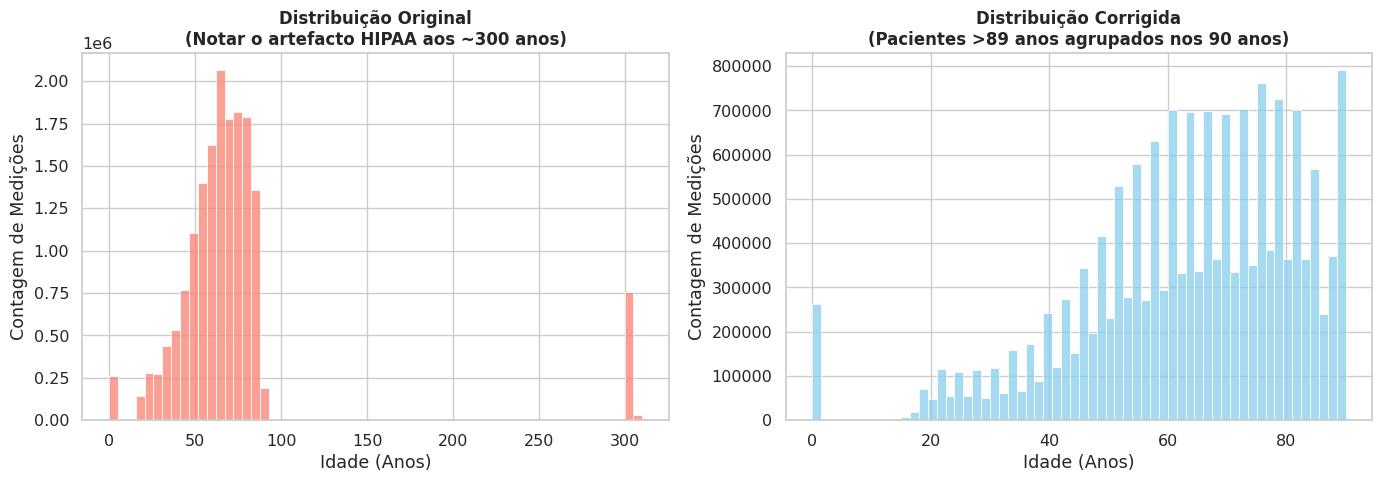

Idade exata calculada com sucesso para todas as 16,608,803 linhas.
Artefactos HIPAA corrigidos (>89 anos imputados para 90): 789,972
Tempo de execução: 42.3s



,SUBJECT_ID,DOB,INTIME,IDADE
0,15888,2121-04-10,2192-11-02 10:54:00,71.0
1,14409,2123-01-16,2194-03-28 11:53:00,71.0
2,47785,2059-11-16,2133-10-01 07:04:34,73.0
3,3139,2049-05-10,2116-04-05 17:54:00,66.0
4,23802,2149-10-09,2190-08-02 19:07:50,40.0


CPU times: user 36.1 s, sys: 5.93 s, total: 42 s
Wall time: 43.1 s


In [10]:
%%time
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

_t0 = time.time()
print("A executar Cálculo da Idade Exata e Correção HIPAA...\n")

# Cálculo da Idade Bruta com lógica de precisão cronológica (mês e dia)
anos_diff = df_raw['INTIME'].dt.year - df_raw['DOB'].dt.year
ainda_nao_fez = (
    (df_raw['INTIME'].dt.month < df_raw['DOB'].dt.month) |
    ((df_raw['INTIME'].dt.month == df_raw['DOB'].dt.month) & (df_raw['INTIME'].dt.day < df_raw['DOB'].dt.day))
)

# Criar coluna temporária com a idade bruta para representação gráfica do "Antes"
df_raw['IDADE_ORIGINAL'] = anos_diff - ainda_nao_fez.astype(int)

# Correção HIPAA (>89 anos imputados para 90) e salvaguarda de mínimos (Neonatologia)
n_hipaa = (df_raw['IDADE_ORIGINAL'] >= 100).sum()
df_raw['IDADE'] = np.where(df_raw['IDADE_ORIGINAL'] >= 100, 90.0, df_raw['IDADE_ORIGINAL'].astype(float))

# Mitigação de ruído de registo em recém-nascidos (truncatura do limite inferior a zero)
n_negativos = (df_raw['IDADE'] < 0).sum()
df_raw['IDADE'] = np.where(df_raw['IDADE'] < 0, 0.0, df_raw['IDADE'])

# Antes vs Depois: Visualização da distribuição das idades
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Antes da Correção (Evidencia a anomalia dos ~300 anos induzida pela HIPAA)
sns.histplot(df_raw['IDADE_ORIGINAL'], bins=60, color='salmon', ax=axes[0], kde=False)
axes[0].set_title('Distribuição Original\n(Notar o artefacto HIPAA aos ~300 anos)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Idade (Anos)')
axes[0].set_ylabel('Contagem de Medições')

# Gráfico 2: Depois da Correção (Distribuição demográfica fisiologicamente plausível)
sns.histplot(df_raw['IDADE'], bins=60, color='skyblue', ax=axes[1], kde=False)
axes[1].set_title('Distribuição Corrigida\n(Pacientes >89 anos agrupados nos 90 anos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Idade (Anos)')
axes[1].set_ylabel('Contagem de Medições')

plt.tight_layout()
plt.show()

# Limpeza de memória: Eliminar a coluna temporária original
df_raw.drop(columns=['IDADE_ORIGINAL'], inplace=True)

print(f"Idade exata calculada com sucesso para todas as {len(df_raw):,} linhas.")
print(f"Artefactos HIPAA corrigidos (>89 anos imputados para 90): {n_hipaa:,}")
if n_negativos > 0:
    print(f"Ruídos de data em neonatos corrigidos (ajustados para 0.0): {n_negativos:,}")
print(f"Tempo de execução: {time.time()-_t0:.1f}s\n")

# Validar o resultado em formato tabular
display(df_raw[['SUBJECT_ID', 'DOB', 'INTIME', 'IDADE']].head(5))

> **Análise do impacto da correção da idade**
>
> A comparação entre as duas distribuições confirma a necessidade da correção aplicada. No histograma original, observa-se um pico artificial próximo dos 300 anos, resultante do processo de anonimização do MIMIC-III para pacientes com idade superior a 89 anos.
>
> Após a recodificação desses casos para 90 anos, a distribuição passa a apresentar uma configuração mais plausível do ponto de vista demográfico, eliminando o artefacto extremo sem remover os registos correspondentes.
>
> Foram corrigidos 789 972 registos com idade superior a 89 anos. Este valor refere-se ao número de linhas da base extraída, e não ao número de pacientes únicos, uma vez que nesta fase cada paciente pode ter múltiplas medições clínicas associadas.
>
> Esta transformação preserva a informação de idade avançada, mas evita que valores artificiais próximos dos 300 anos distorçam estatísticas descritivas, visualizações e futuras etapas de modelação.

### 6.1.3 Validação de Integridade da Variável-Alvo (*Sanity Check* do LOS)

A variável-alvo do projeto é o tempo de internamento na UCI (`LOS`: *Length of Stay*), expresso em dias. Embora o MIMIC-III já disponibilize esta variável na tabela `ICUSTAYS`, é importante validar a sua consistência depois das transformações temporais realizadas anteriormente.

Nesta etapa, o `LOS` é recalculado a partir das colunas temporais limpas, usando a diferença entre o instante de saída da UCI (`OUTTIME`) e o instante de entrada (`INTIME`). O valor recalculado (`LOS_DIAS`) é depois comparado com o valor original da base (`LOS_MIMIC`).

Esta validação permite confirmar que a normalização temporal não introduziu inconsistências cronológicas e que a variável-alvo pode ser usada com segurança nas etapas seguintes do pipeline.

In [11]:
%%time
import time

_t0 = time.time()
print("A executar Recálculo do LOS e Validação de Integridade (Sanity Check)...\n")

# Recálculo matemático do Tempo de Internamento na UCI (em dias)
# Conversão para segundos e divisão por 86.400 (segundos num dia) para alinhar a escala com o MIT
df_raw['LOS_DIAS'] = ((df_raw['OUTTIME'] - df_raw['INTIME']).dt.total_seconds() / 86400).round(4)

# Extração do Coeficiente de Correlação de Pearson
# O método .dropna() isola os pares completos, garantindo a robustez estatística do cálculo
matriz_corr = df_raw[['LOS_DIAS', 'LOS_MIMIC']].dropna().astype(float).corr()
corr_los = matriz_corr.iloc[0, 1]

print(f"Métrica LOS recalculada a partir dos timestamps higienizados.")
print(f"Coeficiente de Correlação de Pearson: {corr_los:.6f}")

# Validação lógica do pipeline
if corr_los > 0.9999:
    print("Integridade temporal garantida: Correlação linear perfeita!")
else:
    print("Discrepância detetada nas operações temporais. Rever tratamento de fusos horários!")

print(f"\nTempo de execução: {time.time()-_t0:.1f}s\n")

# Amostragem tabular para auditoria visual direta
display(df_raw[['SUBJECT_ID', 'INTIME', 'OUTTIME', 'LOS_DIAS', 'LOS_MIMIC']].head())

A executar Recálculo do LOS e Validação de Integridade (Sanity Check)...

Métrica LOS recalculada a partir dos timestamps higienizados.
Coeficiente de Correlação de Pearson: 1.000000
Integridade temporal garantida: Correlação linear perfeita!

Tempo de execução: 2.1s



,SUBJECT_ID,INTIME,OUTTIME,LOS_DIAS,LOS_MIMIC
0,15888,2192-11-02 10:54:00,2192-11-05 14:11:00,3.1368,3.1368
1,14409,2194-03-28 11:53:00,2194-03-30 17:43:00,2.2431,2.2431
2,47785,2133-10-01 07:04:34,2133-10-08 17:50:54,7.4488,7.4488
3,3139,2116-04-05 17:54:00,2116-04-08 21:02:00,3.1306,3.1306
4,23802,2190-08-02 19:07:50,2190-08-03 15:59:07,0.8689,0.8689


CPU times: user 2 s, sys: 881 ms, total: 2.88 s
Wall time: 2.95 s


> **Análise da validação de integridade do LOS**
>
> O coeficiente de correlação de Pearson obtido entre `LOS_DIAS` e `LOS_MIMIC` foi igual a `1.000000`, confirmando a consistência entre o LOS recalculado a partir de `OUTTIME - INTIME` e o valor original disponibilizado na tabela `ICUSTAYS`.
>
> Este resultado indica que a normalização temporal realizada anteriormente não introduziu desvios cronológicos relevantes e que a variável-alvo `LOS_DIAS` está corretamente alinhada com os dados originais.
>
> A amostra apresentada reforça esta validação, mostrando valores coincidentes entre `LOS_DIAS` e `LOS_MIMIC` para diferentes estadias UCI. Assim, a variável `LOS_DIAS` pode ser usada como target nas etapas seguintes de preparação da matriz preditiva e, posteriormente, na Fase 2 de modelação.

### 6.1.4 Alinhamento Temporal, Mapeamento Semântico e Codificação Demográfica

Nesta etapa são criadas variáveis auxiliares essenciais para organizar a base ao nível temporal, clínico e demográfico antes da limpeza fisiológica.

As transformações realizadas são:

1. **Cálculo de `HORAS_UCI`:**  
   Calcula o tempo decorrido, em horas, entre a admissão na UCI (`INTIME`) e cada registo clínico (`CHARTTIME`). Esta variável permite selecionar posteriormente os eventos observados nas janelas de 24h, 48h e 72h.

2. **Mapeamento semântico dos `ITEMID`s:**  
   Converte cada `ITEMID` na respetiva variável clínica padronizada, usando o dicionário `SINAIS_VITAIS`. Esta etapa harmoniza identificadores equivalentes dos sistemas CareVue e MetaVision, como acontece com `Heart Rate`, `SpO2` ou `Respiratory Rate`.

3. **Codificação demográfica de `GENDER`:**  
   Transforma a variável `GENDER`, originalmente representada como texto (`M`/`F`), numa variável numérica binária (`GENDER_BIN`). Esta codificação facilita a sua utilização posterior em modelos de Machine Learning.

In [12]:
%%time
import time

_t0 = time.time()
print("A executar Alinhamento Temporal, Binarização e Mapeamento Semântico...\n")

# Alinhamento do Eixo Temporal
# Criam-se as colunas DELTA_HORAS e HORAS_UCI para garantir consistência e evitar KeyErrors nas secções 7 e 8
df_raw['DELTA_HORAS'] = ((df_raw['CHARTTIME'] - df_raw['INTIME']).dt.total_seconds() / 3600).round(4)
df_raw['HORAS_UCI'] = df_raw['DELTA_HORAS']

# Mapeamento Semântico (Tradução do ITEMID para o respetivo Nome do Sinal Vital)
df_raw['NOME_SINAL'] = df_raw['ITEMID'].astype(str).map(ITEMID_TO_NOME)

# Codificação Binária do Género (Mapeamento booleano para algoritmos de ML)
df_raw['GENDER_BIN'] = df_raw['GENDER'].map({'M': 1, 'F': 0})

print(f"Eixo temporal unificado calculado com sucesso ('DELTA_HORAS' e 'HORAS_UCI').")
print(f"Mapeamento semântico aplicado a {df_raw['ITEMID'].nunique()} ITEMIDs únicos.")
print(f"Atributo de género binarizado (M = 1, F = 0) com sucesso.")
print(f"Tempo de execução: {time.time()-_t0:.1f}s\n")

# Extração de amostra multidimensional para validação visual do estado "ML-Ready"
colunas_finais = ['SUBJECT_ID', 'IDADE', 'GENDER_BIN', 'LOS_DIAS', 'DELTA_HORAS', 'HORAS_UCI', 'NOME_SINAL', 'VALUENUM']
display(df_raw[colunas_finais].head(10))

A executar Alinhamento Temporal, Binarização e Mapeamento Semântico...

Eixo temporal unificado calculado com sucesso ('DELTA_HORAS' e 'HORAS_UCI').
Mapeamento semântico aplicado a 18 ITEMIDs únicos.
Atributo de género binarizado (M = 1, F = 0) com sucesso.
Tempo de execução: 6.2s



,SUBJECT_ID,IDADE,GENDER_BIN,LOS_DIAS,DELTA_HORAS,HORAS_UCI,NOME_SINAL,VALUENUM
0,15888,71.0,1,3.1368,58.1000,58.1000,MBP,79.666702
1,14409,71.0,0,2.2431,2.6167,2.6167,SBP,110.000000
2,47785,73.0,0,7.4488,14.5739,14.5739,Respiratory Rate,0.000000
3,3139,66.0,0,3.1306,1.5167,1.5167,MBP,0.000000
4,23802,40.0,0,0.8689,7.8694,7.8694,Temperature,100.099998
5,975,67.0,1,16.3453,39.4550,39.4550,Temperature,100.500000
6,12586,64.0,0,18.8675,7.5583,7.5583,Temperature,100.699997
7,77609,19.0,1,4.3502,7.2253,7.2253,Temperature,100.900000
8,7235,90.0,0,3.8601,22.6839,22.6839,Heart Rate,101.000000
9,18171,79.0,0,2.2642,36.7414,36.7414,Heart Rate,101.000000


CPU times: user 6.32 s, sys: 1.07 s, total: 7.39 s
Wall time: 7.33 s


> **Análise do alinhamento temporal e mapeamento semântico**
>
> A amostra confirma que as principais variáveis auxiliares foram criadas corretamente. O eixo temporal foi convertido para uma variável contínua (`HORAS_UCI`), permitindo selecionar posteriormente observações dentro das janelas de 24h, 48h e 72h. Além disso, os `ITEMID`s foram traduzidos para nomes clínicos interpretáveis através de `NOME_SINAL`, e a variável `GENDER` foi codificada numericamente em `GENDER_BIN`.
>
> No entanto, a base ainda não está pronta para modelação, uma vez que contém valores brutos que precisam de validação clínica. Por exemplo, observa-se uma frequência respiratória igual a `0.0`, valor incompatível com uma medição fisiológica válida em contexto clínico contínuo. Também surgem temperaturas ainda registadas em Fahrenheit, que terão de ser convertidas antes da análise final.
>
> Estes exemplos justificam a etapa seguinte de limpeza fisiológica, onde serão aplicados filtros de plausibilidade, conversão de unidades e remoção de registos incompatíveis com medições clínicas realistas.

### 6.2 Tratamento de Outliers Fisiológicos, Unificação de Unidades e Visualização Estatística

Após a construção da base longitudinal inicial, foi aplicada uma etapa de limpeza clínica aos sinais extraídos de `CHARTEVENTS`. Esta fase teve três objetivos principais: remover valores fisiologicamente inválidos, uniformizar a variável `Temperature` para Celsius e produzir uma visualização estatística antes/depois da limpeza.

A remoção de outliers foi feita com base em limites fisiológicos interpretáveis, em vez de critérios puramente estatísticos como percentis ou desvios-padrão. Esta decisão evita eliminar automaticamente valores extremos que, em contexto de UCI, podem representar estados clínicos graves mas reais.

No caso da temperatura, os `ITEMID`s selecionados registam valores em Fahrenheit. Por isso, a temperatura foi convertida para Celsius antes da aplicação dos limites fisiológicos finais.

Como o dataset contém milhões de registos, a filtragem foi executada com máscaras booleanas e remoção por índice, reduzindo a criação de cópias intermédias e melhorando a eficiência de memória. No final, foi criada a base `df_clean`, que será usada nas etapas seguintes de EDA, visualização temporal e construção da feature matrix.

In [13]:
%%time
import time
import gc
import pandas as pd
import numpy as np

_t0 = time.time()

print("A executar tratamento de outliers fisiológicos, unificação de unidades e auditoria estatística...\n")

# Validação mínima das colunas necessárias
colunas_necessarias = [
    'SUBJECT_ID',
    'HADM_ID',
    'ICUSTAY_ID',
    'ITEMID',
    'NOME_SINAL',
    'VALUENUM',
    'HORAS_UCI',
    'LOS_DIAS',
    'IDADE',
    'GENDER_BIN'
]

colunas_em_falta = [c for c in colunas_necessarias if c not in df_raw.columns]

if len(colunas_em_falta) > 0:
    raise ValueError(
        f"As seguintes colunas estão em falta antes da Secção 6.2: {colunas_em_falta}"
    )

# Garantir que VALUENUM está numérico
df_raw['VALUENUM'] = pd.to_numeric(df_raw['VALUENUM'], errors='coerce')

print(f"Registos antes da limpeza: {len(df_raw):,}".replace(",", " "))


# Atualização final dos limites fisiológicos
# Nota:
# A temperatura será convertida para Celsius antes da filtragem fisiológica final.
# Os limites abaixo são fisiológicos e não puramente estatísticos.
# Zeros impossíveis em sinais vitais são removidos nesta fase.

LIMITES_FISIOLOGICOS_FINAIS = {
    'Heart Rate': {
        'unidade': 'bpm',
        'min_fisiologico': 20,
        'max_fisiologico': 250
    },
    'SBP': {
        'unidade': 'mmHg',
        'min_fisiologico': 40,
        'max_fisiologico': 300
    },
    'DBP': {
        'unidade': 'mmHg',
        'min_fisiologico': 20,
        'max_fisiologico': 200
    },
    'MBP': {
        'unidade': 'mmHg',
        'min_fisiologico': 30,
        'max_fisiologico': 250
    },
    'SpO2': {
        'unidade': '%',
        'min_fisiologico': 50,
        'max_fisiologico': 100
    },
    'Temperature': {
        'unidade': '°C',
        'min_fisiologico': 22.2,
        'max_fisiologico': 43.3
    },
    'Respiratory Rate': {
        'unidade': 'rpm',
        'min_fisiologico': 4,
        'max_fisiologico': 70
    },
    'GCS Total': {
        'unidade': 'score',
        'min_fisiologico': 3,
        'max_fisiologico': 15
    }
}

# Atualizar o dicionário SINAIS_VITAIS já criado anteriormente.
# Mantém os ITEMIDs definidos na Secção 4.3, mas substitui unidades e limites.
for nome_sinal, limites in LIMITES_FISIOLOGICOS_FINAIS.items():
    if nome_sinal in SINAIS_VITAIS:
        SINAIS_VITAIS[nome_sinal]['unidade'] = limites['unidade']
        SINAIS_VITAIS[nome_sinal]['min_fisiologico'] = limites['min_fisiologico']
        SINAIS_VITAIS[nome_sinal]['max_fisiologico'] = limites['max_fisiologico']
    else:
        raise ValueError(f"O sinal '{nome_sinal}' não existe no dicionário SINAIS_VITAIS.")

print("\nLimites fisiológicos finais definidos:")
for nome_sinal, cfg in SINAIS_VITAIS.items():
    print(
        f"  {nome_sinal:<18} "
        f"[{cfg['min_fisiologico']} ; {cfg['max_fisiologico']}] {cfg['unidade']}"
    )

# Unificação da temperatura para Celsius
# se a mediana da temperatura for > 60, assumimos Fahrenheit
# se for <= 60, assumimos que já está em Celsius.

mask_temp = df_raw['NOME_SINAL'].eq('Temperature')
n_temp = int(mask_temp.sum())

if n_temp > 0:
    temp_mediana_antes = df_raw.loc[mask_temp, 'VALUENUM'].median()
    temp_min_antes = df_raw.loc[mask_temp, 'VALUENUM'].min()
    temp_max_antes = df_raw.loc[mask_temp, 'VALUENUM'].max()

    if pd.notna(temp_mediana_antes) and temp_mediana_antes > 60:
        df_raw.loc[mask_temp, 'VALUENUM'] = (
            (df_raw.loc[mask_temp, 'VALUENUM'] - 32) * (5.0 / 9.0)
        )

        temp_min_depois = df_raw.loc[mask_temp, 'VALUENUM'].min()
        temp_max_depois = df_raw.loc[mask_temp, 'VALUENUM'].max()

        print("\nConversão térmica aplicada:")
        print(f"  Registos de temperatura: {n_temp:,}".replace(",", " "))
        print(f"  Escala original provável: Fahrenheit")
        print(f"  Amplitude antes:  {temp_min_antes:.2f}°F a {temp_max_antes:.2f}°F")
        print(f"  Amplitude depois: {temp_min_depois:.2f}°C a {temp_max_depois:.2f}°C")

    else:
        print("\nConversão térmica não aplicada:")
        print(f"  Registos de temperatura: {n_temp:,}".replace(",", " "))
        print("  A temperatura aparenta já estar em Celsius.")

else:
    print("\nAviso: não existem registos de Temperature antes da limpeza.")


# Estatísticas antes da limpeza fisiológica
stats_antes = (
    df_raw
    .groupby('NOME_SINAL')['VALUENUM']
    .agg(['count', 'min', 'max'])
    .rename(columns={
        'count': 'Registos (Antes)',
        'min': 'Min (Antes)',
        'max': 'Max (Antes)'
    })
)

n_antes = len(df_raw)


# Aplicação dos filtros fisiológicos
# Estratégia usada:
# Criamos uma máscara global de remoção.
# Não fazemos cópias grandes do dataframe.
# No final removemos tudo de uma vez.

print("\nA aplicar filtros fisiológicos por sinal vital...\n")

mask_remover_global = df_raw['VALUENUM'].isna() | ~np.isfinite(df_raw['VALUENUM'])

resumo_remocoes = {}

for nome_sinal, cfg in SINAIS_VITAIS.items():
    mask_sinal = df_raw['NOME_SINAL'].eq(nome_sinal)

    mask_outlier = (
        mask_sinal &
        (
            (df_raw['VALUENUM'] < cfg['min_fisiologico']) |
            (df_raw['VALUENUM'] > cfg['max_fisiologico'])
        )
    )

    n_remover_sinal = int(mask_outlier.sum())
    resumo_remocoes[nome_sinal] = n_remover_sinal

    mask_remover_global = mask_remover_global | mask_outlier

    print(
        f"  {nome_sinal:<18} | "
        f"outliers removidos: {n_remover_sinal:,}".replace(",", " ")
    )

    del mask_sinal, mask_outlier
    gc.collect()

n_remover_total = int(mask_remover_global.sum())

print(f"\nTotal de linhas a remover: {n_remover_total:,}".replace(",", " "))

indices_para_remover = df_raw.index[mask_remover_global]

df_raw.drop(index=indices_para_remover, inplace=True)

del mask_remover_global, indices_para_remover
gc.collect()

# A partir daqui, df_clean é a matriz limpa usada no resto do notebook
df_clean = df_raw

n_depois = len(df_clean)


# Estatísticas depois da limpeza fisiológica
stats_depois = (
    df_clean
    .groupby('NOME_SINAL')['VALUENUM']
    .agg(['count', 'min', 'max'])
    .rename(columns={
        'count': 'Registos (Depois)',
        'min': 'Min (Depois)',
        'max': 'Max (Depois)'
    })
)


# Tabela de Visulaização antes/depois
ordem_sinais = list(SINAIS_VITAIS.keys())

tabela_comparativa = pd.concat([stats_antes, stats_depois], axis=1)
tabela_comparativa = tabela_comparativa.reindex(ordem_sinais)

for col in ['Registos (Antes)', 'Registos (Depois)']:
    tabela_comparativa[col] = tabela_comparativa[col].fillna(0).astype(int)

tabela_comparativa['Registos Removidos'] = (
    tabela_comparativa['Registos (Antes)'] -
    tabela_comparativa['Registos (Depois)']
)

tabela_comparativa['% Descarte'] = np.where(
    tabela_comparativa['Registos (Antes)'] > 0,
    tabela_comparativa['Registos Removidos'] / tabela_comparativa['Registos (Antes)'] * 100,
    0
)

tabela_comparativa = tabela_comparativa[
    [
        'Registos (Antes)',
        'Registos (Depois)',
        'Registos Removidos',
        '% Descarte',
        'Min (Antes)',
        'Min (Depois)',
        'Max (Antes)',
        'Max (Depois)'
    ]
]

print("\nMatriz de auditoria estatística antes/depois da limpeza:")

display(
    tabela_comparativa.style
    .format({
        'Registos (Antes)': '{:,.0f}',
        'Registos (Depois)': '{:,.0f}',
        'Registos Removidos': '{:,.0f}',
        '% Descarte': '{:.4f}%',
        'Min (Antes)': '{:.2f}',
        'Min (Depois)': '{:.2f}',
        'Max (Antes)': '{:.2f}',
        'Max (Depois)': '{:.2f}'
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]}
    ])
    .background_gradient(subset=['% Descarte'], cmap='Reds')
)


# Validação final da matriz limpa

print("RElatório final")


print(f"Registos antes da limpeza : {n_antes:,}".replace(",", " "))
print(f"Registos depois da limpeza: {n_depois:,}".replace(",", " "))
print(f"Registos removidos        : {n_antes - n_depois:,}".replace(",", " "))
print(f"Percentagem removida      : {100 * (n_antes - n_depois) / n_antes:.4f}%")

print("\nSinais vitais finais disponíveis:")
sinais_finais = sorted(df_clean['NOME_SINAL'].dropna().unique())
print(f"Total: {len(sinais_finais)} dimensões clínicas estruturadas.")
print(sinais_finais)

# Validação específica da temperatura
if 'Temperature' in sinais_finais:
    temp_final = df_clean.loc[df_clean['NOME_SINAL'].eq('Temperature'), 'VALUENUM']
    print("\nTemperatura preservada com sucesso.")
    print(f"Amplitude final da temperatura: {temp_final.min():.2f}°C a {temp_final.max():.2f}°C")
else:
    print("\nAVISO: Temperature desapareceu da matriz. É necessário rever a secção 6.2.")

# Validação de zeros impossíveis após limpeza
sinais_com_zero_impossivel = ['Heart Rate', 'SBP', 'DBP', 'MBP', 'SpO2', 'Respiratory Rate']
zeros_restantes = {}

for sinal in sinais_com_zero_impossivel:
    n_zeros = int(
        (
            df_clean['NOME_SINAL'].eq(sinal) &
            df_clean['VALUENUM'].eq(0)
        ).sum()
    )
    zeros_restantes[sinal] = n_zeros

print("\nZeros restantes em sinais onde zero é fisiologicamente inválido:")
for sinal, n_zeros in zeros_restantes.items():
    print(f"  {sinal:<18}: {n_zeros:,}".replace(",", " "))

if sum(zeros_restantes.values()) == 0:
    print("Validação concluída: zeros impossíveis removidos com sucesso.")
else:
    print("Aviso: ainda existem zeros em sinais vitais. Rever limites ou origem dos dados.")

print("\nEstado final:")
print(f"df_clean criado com shape: {df_clean.shape[0]:,} linhas × {df_clean.shape[1]} colunas".replace(",", " "))
print(f"Tempo total da Secção 6.2: {time.time() - _t0:.1f}s")

A executar tratamento de outliers fisiológicos, unificação de unidades e auditoria estatística...

Registos antes da limpeza: 16 608 803

Limites fisiológicos finais definidos:
  Heart Rate         [20 ; 250] bpm
  SBP                [40 ; 300] mmHg
  DBP                [20 ; 200] mmHg
  MBP                [30 ; 250] mmHg
  SpO2               [50 ; 100] %
  Temperature        [22.2 ; 43.3] °C
  Respiratory Rate   [4 ; 70] rpm
  GCS Total          [3 ; 15] score
  GCS Eye Opening    [1 ; 4] score
  GCS Motor Response [1 ; 6] score
  GCS Verbal Response [1 ; 5] score

Conversão térmica aplicada:
  Registos de temperatura: 631 051
  Escala original provável: Fahrenheit
  Amplitude antes:  -99.90°F a 9637.00°F
  Amplitude depois: -73.28°C a 5336.11°C

A aplicar filtros fisiológicos por sinal vital...

  Heart Rate         | outliers removidos: 1 414
  SBP                | outliers removidos: 4 978
  DBP                | outliers removidos: 5 674
  MBP                | outliers removidos: 5

,Registos (Antes),Registos (Depois),Registos Removidos,% Descarte,Min (Antes),Min (Depois),Max (Antes),Max (Depois)
NOME_SINAL,,,,,,,,
Heart Rate,"3,468,304","3,466,890","1,414",0.0408%,0.00,20.00,6632.00,250.00
SBP,"1,722,218","1,717,240","4,978",0.2890%,-69.00,40.00,141146.04,300.00
DBP,"1,721,548","1,715,874","5,674",0.3296%,-2.00,20.00,114108.98,199.00
MBP,"1,394,174","1,388,220","5,954",0.4271%,-135.00,30.00,88106.03,250.00
SpO2,"3,085,187","3,083,116","2,071",0.0671%,0.00,50.00,3333331.00,100.00
Temperature,"631,051","630,287",764,0.1211%,-73.28,22.78,5336.11,42.78
Respiratory Rate,"3,140,185","3,125,154","15,031",0.4787%,0.00,4.00,2355555.00,70.00
GCS Total,"458,447","458,447",0,0.0000%,3.00,3.00,15.00,15.00
GCS Eye Opening,"329,964","329,964",0,0.0000%,1.00,1.00,4.00,4.00


RElatório final
Registos antes da limpeza : 16 608 803
Registos depois da limpeza: 16 572 917
Registos removidos        : 35 886
Percentagem removida      : 0.2161%

Sinais vitais finais disponíveis:
Total: 11 dimensões clínicas estruturadas.
['DBP', 'GCS Eye Opening', 'GCS Motor Response', 'GCS Total', 'GCS Verbal Response', 'Heart Rate', 'MBP', 'Respiratory Rate', 'SBP', 'SpO2', 'Temperature']

Temperatura preservada com sucesso.
Amplitude final da temperatura: 22.78°C a 42.78°C

Zeros restantes em sinais onde zero é fisiologicamente inválido:
  Heart Rate        : 0
  SBP               : 0
  DBP               : 0
  MBP               : 0
  SpO2              : 0
  Respiratory Rate  : 0
Validação concluída: zeros impossíveis removidos com sucesso.

Estado final:
df_clean criado com shape: 16 572 917 linhas × 19 colunas
Tempo total da Secção 6.2: 43.3s
CPU times: user 41.1 s, sys: 2.4 s, total: 43.5 s
Wall time: 43.3 s


> **Análise da limpeza fisiológica e auditoria estatística**
>
> A etapa de limpeza removeu 35 886 registos de um total inicial de 16 608 803, correspondendo a apenas 0.2161% da base extraída. Esta percentagem reduzida indica que os filtros fisiológicos atuaram sobretudo sobre artefactos extremos, preservando a quase totalidade dos dados clinicamente utilizáveis.
>
> A visualização antes/depois confirma a presença de valores biologicamente incompatíveis nos dados brutos, como frequências cardíacas iguais a 0, pressões arteriais negativas, valores de SpO₂ superiores a 100% e temperaturas extremamente fora da escala fisiológica. Após a aplicação dos filtros, os mínimos e máximos de cada sinal passaram a situar-se dentro dos limites definidos.
>
> No caso da temperatura, os valores foram convertidos de Fahrenheit para Celsius antes da filtragem final. A amplitude final ficou entre 22.78°C e 42.78°C, indicando que a conversão e a preservação dos registos válidos foram efetuadas corretamente.
>
> A validação final confirma ainda que não restam zeros em sinais onde esse valor é fisiologicamente inválido, como `Heart Rate`, `SBP`, `DBP`, `MBP`, `SpO2` e `Respiratory Rate`.
>
> As variáveis associadas ao Glasgow Coma Scale não sofreram remoções, o que é consistente com os seus intervalos discretos esperados. Assim, a base `df_clean` fica validada para as etapas seguintes de análise exploratória, seleção de janelas temporais e construção da matriz preditiva.

## 7. Análise Exploratória de Dados (EDA)

Com a matriz `df_clean` consolidada após a limpeza fisiológica, inicia-se a caracterização estatística e visual da população analisada. O objetivo desta fase é compreender a distribuição dos sinais clínicos, a evolução temporal das medições e a relação exploratória entre as variáveis disponíveis e o tempo de internamento na UCI.

As visualizações desta secção não têm apenas função descritiva: servem também para fundamentar decisões metodológicas posteriores, nomeadamente a escolha da janela temporal, a agregação por `ICUSTAY_ID` e a construção da matriz preditiva final.

### 7.1 Visualização Dinâmica do Perfil Clínico Temporal

Nesta secção é apresentada uma visualização temporal de uma estadia individual em UCI, usando os sinais clínicos extraídos de `CHARTEVENTS`.

O objetivo é ilustrar a estrutura longitudinal dos dados, mostrando como múltiplas medições clínicas são registadas ao longo das primeiras 24 horas de internamento.

Esta visualização é complementar à análise específica do `ICUSTAY_ID = 200072` apresentada na Secção 7.7, que replica o exemplo do enunciado com base em `INPUTEVENTS_MV`.

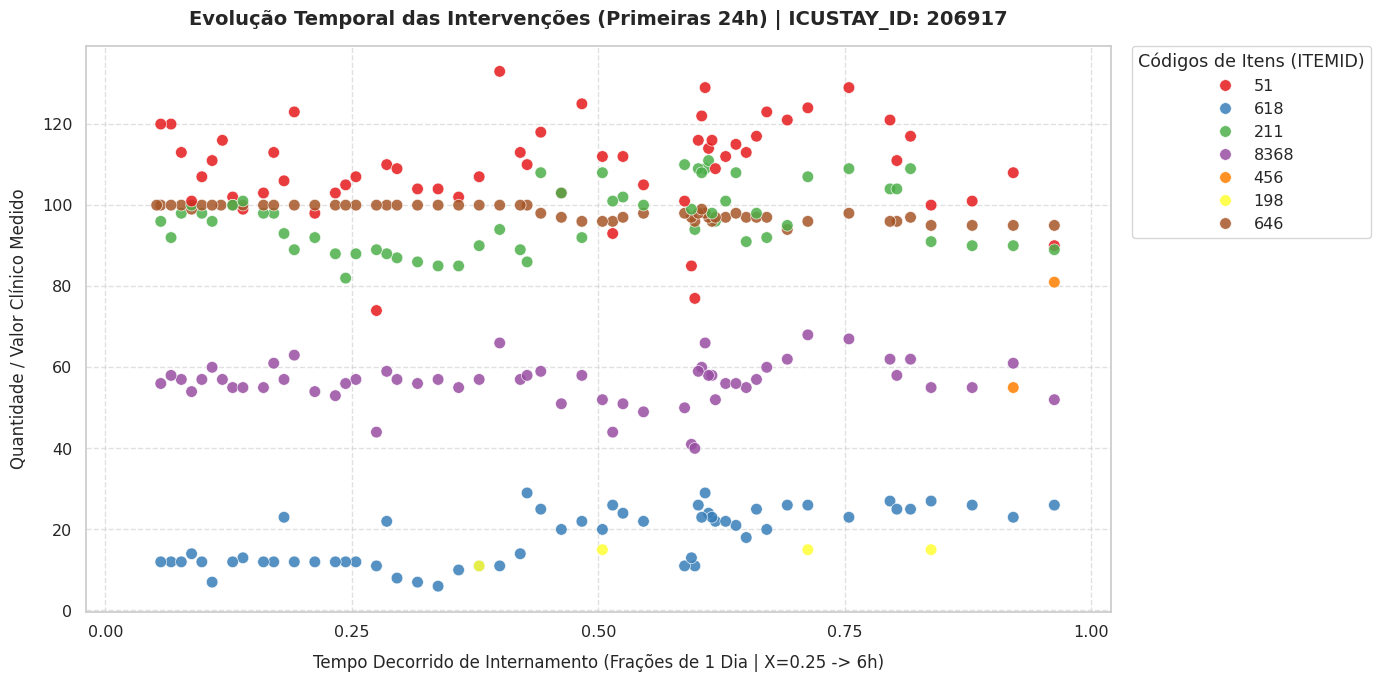

Gráfico gerado para a estadia UCI 206917.
Total de medições registadas para esta estadia nas primeiras 24h: 294 linhas.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar um ICUSTAY_ID que exista no  df_clean e que tenha dados ricos
# Vamos escolher o primeiro ID disponível na amostra limpa
id_paciente_exemplo = df_clean['ICUSTAY_ID'].unique()[0]

# Filtrar os dados desse paciente específico a partir do df_clean
df_grafico = df_clean[df_clean['ICUSTAY_ID'] == id_paciente_exemplo].copy()

# Calcular a fração do dia baseada no DELTA_HORAS (gerado no ponto 6.1.4)
# X = 0.0 (entrada na UCI), X = 1.0 (fim do 1º dia)
df_grafico['FRACAO_DIA'] = df_grafico['DELTA_HORAS'] / 24.0

# Filtrar rigorosamente para o primeiro dia de intervenção (X entre 0 e 1)
df_primeiro_dia = df_grafico[(df_grafico['FRACAO_DIA'] >= 0) & (df_grafico['FRACAO_DIA'] <= 1.0)]

# Construção do gráfico de dispersão (Scatter Plot) idêntico ao solicitado
plt.figure(figsize=(14, 7))

# Criamos o scatter plot usando o ITEMID ou o NOME_SINAL na legenda
sns.scatterplot(
    data=df_primeiro_dia,
    x='FRACAO_DIA',
    y='VALUENUM',
    hue='ITEMID',          # Mostra os códigos numéricos como pedido no enunciado
    palette='Set1',        # Palete de cores vivas e distintas para cada item
    s=70,                  # Tamanho visível dos pontos (dots)
    alpha=0.85,            # Opacidade para o caso de haver pontos sobrepostos
    edgecolor='w',
    linewidth=0.5
)

# Configurações estéticas e limites dos eixos
plt.title(f'Evolução Temporal das Intervenções (Primeiras 24h) | ICUSTAY_ID: {id_paciente_exemplo}',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tempo Decorrido de Internamento (Frações de 1 Dia | X=0.25 -> 6h)', fontsize=12, labelpad=10)
plt.ylabel('Quantidade / Valor Clínico Medido', fontsize=12, labelpad=10)

# Forçar o eixo X a ir exatamente de 0 a 1 em passos de 0.25
plt.xlim(-0.02, 1.02)
plt.xticks([0.0, 0.25, 0.50, 0.75, 1.0])

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title="Códigos de Itens (ITEMID)", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

print(f"Gráfico gerado para a estadia UCI {id_paciente_exemplo}.")
print(f"Total de medições registadas para esta estadia nas primeiras 24h: {len(df_primeiro_dia)} linhas.")

> **Análise do perfil clínico temporal**
>
> A visualização mostra a evolução dos sinais clínicos registados durante as primeiras 24 horas de uma estadia individual em UCI. Observa-se uma elevada densidade de medições ao longo do primeiro dia, confirmando a natureza longitudinal e intensiva dos dados em `CHARTEVENTS`.
>
> O gráfico evidencia a coexistência de múltiplos sinais clínicos, como frequência cardíaca, pressão arterial, SpO₂, frequência respiratória e GCS, registados em momentos sucessivos.
>
> Como os sinais estão representados no mesmo eixo vertical mas possuem escalas clínicas diferentes, esta visualização deve ser interpretada sobretudo como uma análise da densidade temporal e da disponibilidade dos registos, e não como comparação direta entre magnitudes fisiológicas.
>
> Esta estrutura justifica a necessidade de transformar os dados longitudinais numa matriz agregada por `ICUSTAY_ID` antes da modelação.

### 7.2 Distribuição dos Sinais Clínicos após Limpeza

Nesta etapa é analisada a distribuição dos sinais clínicos presentes em `df_clean` após a aplicação dos filtros fisiológicos.

Foi utilizado um *violin plot* combinado com *boxplot*, porque esta representação permite observar simultaneamente a densidade da distribuição, a mediana, os quartis e a presença de valores extremos. Esta visualização é útil para verificar se os sinais apresentam amplitudes plausíveis após a limpeza e para identificar assimetrias ou concentrações relevantes nos dados.

Geração de Violin e Boxplots com amostragem controlada



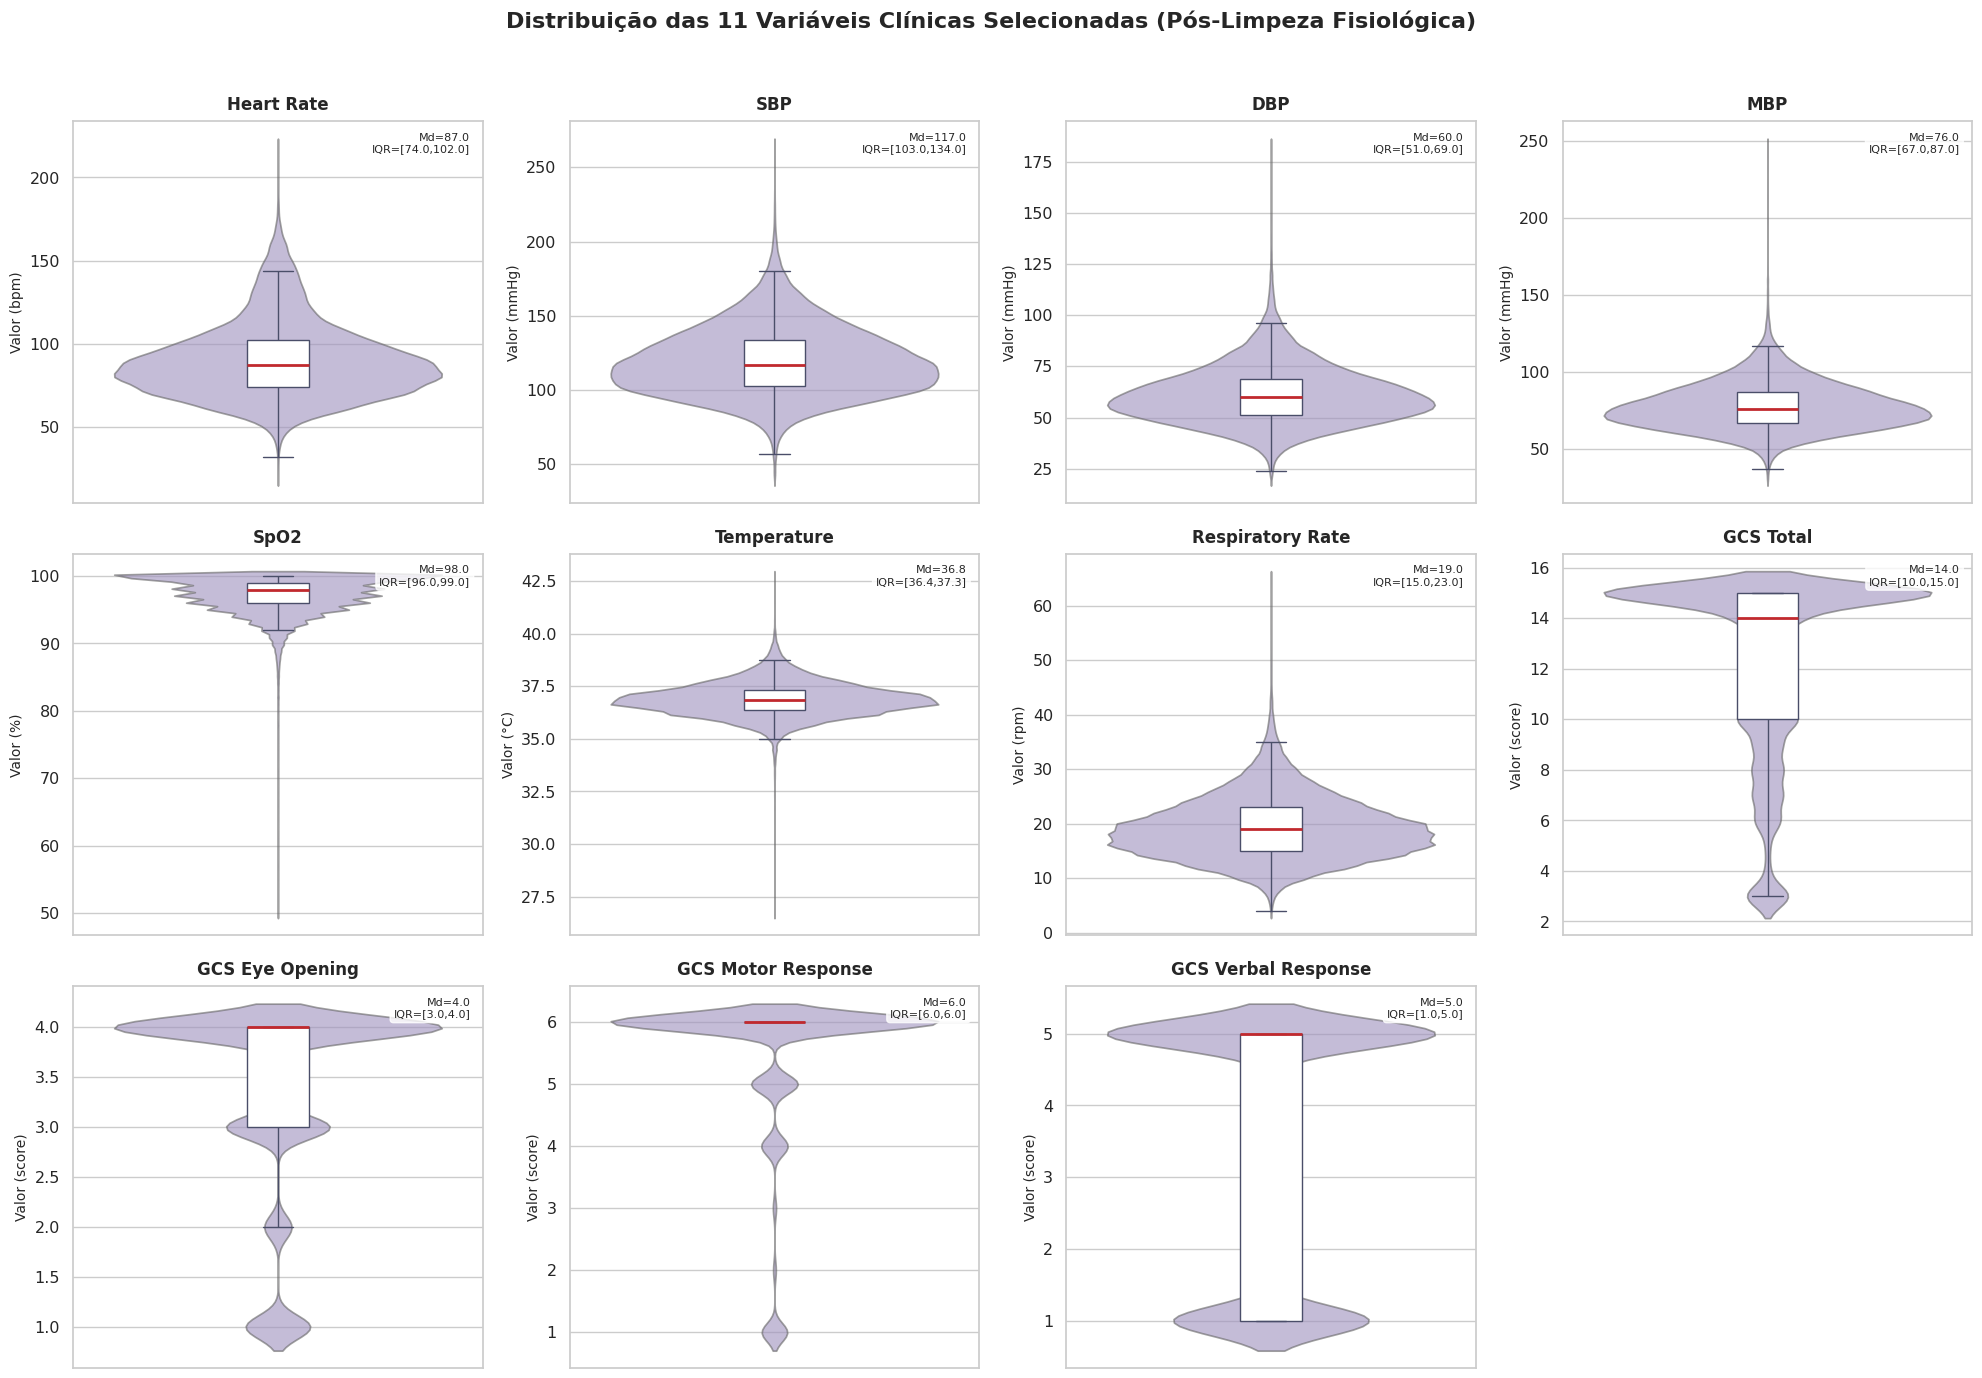


Estatísticas Descritivas por Variável Clínica: dados completos:


,count,mean,std,min,25%,50%,75%,max
NOME_SINAL,,,,,,,,
DBP,1715874.0,61.19,14.28,20.00,51.00,60.00,69.00,199.00
GCS Eye Opening,329964.0,3.33,1.04,1.00,3.00,4.00,4.00,4.00
GCS Motor Response,328754.0,5.43,1.29,1.00,6.00,6.00,6.00,6.00
GCS Total,458447.0,12.08,3.78,3.00,10.00,14.00,15.00,15.00
GCS Verbal Response,328971.0,3.52,1.82,1.00,1.00,5.00,5.00,5.00
Heart Rate,3466890.0,90.37,23.18,20.00,74.00,87.00,102.00,250.00
MBP,1388220.0,78.07,15.76,30.00,67.00,76.00,87.00,250.00
Respiratory Rate,3125154.0,19.31,5.77,4.00,15.00,19.00,23.00,70.00
SBP,1717240.0,119.61,23.39,40.00,103.00,117.00,134.00,300.00


CPU times: user 29.2 s, sys: 623 ms, total: 29.8 s
Wall time: 29.1 s


In [15]:
%%time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

print("Geração de Violin e Boxplots com amostragem controlada\n")

# Configuração da grelha
sinais_ordem = list(SINAIS_VITAIS.keys())
n_sinais = len(sinais_ordem)

n_cols = 4
n_rows = math.ceil(n_sinais / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten()

# Número máximo de observações usadas apenas para visualização.
# As estatísticas descritivas continuam a ser calculadas com todos os dados.
MAX_AMOSTRA_POR_SINAL = 50000
RANDOM_STATE = 42

# VIOLIN + BOXPLOT por variavel clinica
for idx, nome_sinal in enumerate(sinais_ordem):
    ax = axes[idx]

    dados_sinal_completos = df_clean.loc[
        df_clean['NOME_SINAL'] == nome_sinal,
        'VALUENUM'
    ].dropna()

    if len(dados_sinal_completos) == 0:
        ax.set_title(f'{nome_sinal}\nSem dados disponíveis')
        ax.axis('off')
        continue

    # Amostragem apenas para visualização
    if len(dados_sinal_completos) > MAX_AMOSTRA_POR_SINAL:
        dados_plot = dados_sinal_completos.sample(
            n=MAX_AMOSTRA_POR_SINAL,
            random_state=RANDOM_STATE
        )
    else:
        dados_plot = dados_sinal_completos

    sns.violinplot(
        y=dados_plot,
        ax=ax,
        color='#9B89C4',
        inner=None,
        alpha=0.6
    )

    sns.boxplot(
        y=dados_plot,
        ax=ax,
        width=0.15,
        color='white',
        showfliers=False,
        boxprops=dict(edgecolor='#4A4E69'),
        medianprops=dict(color='#C1292E', linewidth=2),
        whiskerprops=dict(color='#4A4E69'),
        capprops=dict(color='#4A4E69')
    )

    unidade = SINAIS_VITAIS[nome_sinal]['unidade']

    ax.set_title(f'{nome_sinal}', fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel(f'Valor ({unidade})', fontsize=10)
    ax.set_xlabel('')

    # Estatísticas calculadas com todos os dados, não só com a amostra
    mediana = dados_sinal_completos.median()
    q1, q3 = dados_sinal_completos.quantile([0.25, 0.75])

    ax.text(
        0.97,
        0.97,
        f'Md={mediana:.1f}\nIQR=[{q1:.1f},{q3:.1f}]',
        transform=ax.transAxes,
        fontsize=8,
        va='top',
        ha='right',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            alpha=0.8
        )
    )

# Desligar eixos vazios
for j in range(n_sinais, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    f'Distribuição das {n_sinais} Variáveis Clínicas Selecionadas '
    '(Pós-Limpeza Fisiológica)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('violin_sinais_clinicos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEstatísticas Descritivas por Variável Clínica: dados completos:")
resumo = df_clean.groupby('NOME_SINAL')['VALUENUM'].describe().round(2)
display(resumo)



> **Análise descritiva dos sinais clínicos**
>
> A análise visual e estatística confirma que, após a limpeza fisiológica, os 11 sinais clínicos selecionados apresentam amplitudes compatíveis com os limites definidos na Secção 6.2. Os *violin plots* permitem observar a forma das distribuições, enquanto os *boxplots* evidenciam a mediana, os quartis e a dispersão central de cada variável.
>
> Observa-se uma diferença clara na volumetria entre sinais. Variáveis monitorizadas de forma contínua, como `Heart Rate`, `SpO2` e `Respiratory Rate`, apresentam mais de 3 milhões de registos cada. Em contraste, variáveis registadas com menor frequência, como `Temperature` e as componentes de `GCS`, têm menor número de observações. Esta diferença é esperada em contexto de UCI, uma vez que nem todos os sinais são medidos com a mesma periodicidade.
>
> As variáveis cardiovasculares e respiratórias apresentam distribuições concentradas em intervalos clinicamente plausíveis. Por exemplo, `Heart Rate` apresenta mediana de 87 bpm, `SBP` mediana de 117 mmHg e `Respiratory Rate` mediana de 19 rpm. A `SpO2` apresenta forte concentração em valores elevados, com mediana de 98%, refletindo a monitorização e suporte respiratório frequentes em ambiente de cuidados intensivos.
>
> A variável `Temperature`, já convertida para Celsius, apresenta mediana de 36.83°C e intervalo interquartil entre 36.39°C e 37.33°C, o que confirma a correta padronização da unidade após a conversão.
>
> As variáveis associadas ao Glasgow Coma Scale apresentam distribuições discretas, como esperado pela natureza ordinal destes scores. O `GCS Total` apresenta mediana de 14, enquanto as componentes `GCS Eye Opening`, `GCS Motor Response` e `GCS Verbal Response` mostram concentração nos valores superiores, mas preservam também registos compatíveis com estados neurológicos mais graves.
>
> Esta análise confirma que a limpeza fisiológica produziu uma base coerente para as etapas seguintes, mantendo variabilidade clínica relevante sem preservar artefactos extremos incompatíveis com medições reais.

### 7.3 Distribuição do `LOS_DIAS`: Análise da Variável-Alvo

A variável-alvo `LOS_DIAS` (*Length of Stay*) representa o tempo de internamento na UCI, expresso em dias. Antes da construção da matriz final e da posterior modelação na Fase 2, é essencial compreender a sua distribuição.

Em dados clínicos de UCI, o `LOS` tende a apresentar assimetria à direita: muitas estadias concentram-se em poucos dias, enquanto um número menor de casos apresenta internamentos prolongados. Esta característica pode influenciar a escolha das métricas de avaliação, a interpretação dos erros e a eventual necessidade de transformar a variável-alvo na fase de modelação.

Nesta secção, a distribuição de `LOS_DIAS` é analisada através de histogramas, estatísticas descritivas e percentis, permitindo identificar a concentração central da variável e a presença de caudas longas.

A extrair dados da variável alvo



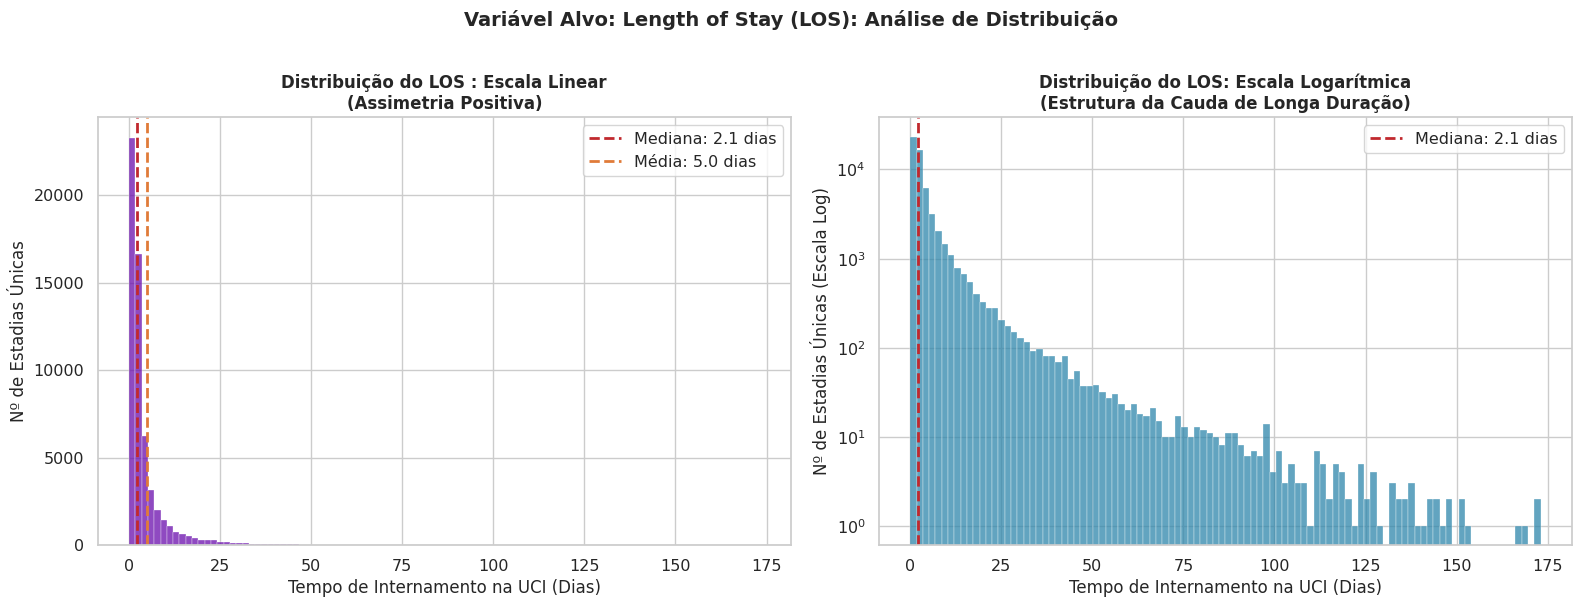

  Estatisticas da variavel alvo: LOS (dias)
  Nº de estadias únicas      : 59 135
  Média                      : 5.01 dias
  Mediana                    : 2.14 dias
  Desvio Padrão              : 9.59 dias
  Mínimo                     : 0.01 dias
  Máximo                     : 173.07 dias
  Percentil 90               : 11.03 dias
  Percentil 99               : 47.05 dias
  Skewness                   : 6.28  (Forte assimetria à direita)

Distribuição Clínica por Categoria de Duração:
                    Nº de Estadias
LOS_DIAS                          
Curto (<2d)                  27312
Médio (2–7d)                 22117
Longo (7–14d)                 5317
Muito Longo (>14d)            4389

=== Estatistica de readmissão (por paciente) ===
            Nº de Pacientes
ICUSTAY_ID                 
1                     36697
2                      5513
3                      1515
4                       624
5                       278
6                       144
7                        74
8

In [16]:
# %%time
import matplotlib.pyplot as plt
import pandas as pd

print("A extrair dados da variável alvo\n")

# Extrair LOS único por estadia
los_unicos = df_clean[['ICUSTAY_ID', 'LOS_DIAS']].drop_duplicates('ICUSTAY_ID')['LOS_DIAS']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Escala Linear (Mostra a densidade e a assimetria real)
ax = axes[0]
ax.hist(los_unicos, bins=100, color='#6A0DAD', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(los_unicos.median(), color='#C1292E', linewidth=2,
           linestyle='--', label=f'Mediana: {los_unicos.median():.1f} dias')
ax.axvline(los_unicos.mean(), color='#E07B39', linewidth=2,
           linestyle='--', label=f'Média: {los_unicos.mean():.1f} dias')
ax.set_xlabel('Tempo de Internamento na UCI (Dias)', fontsize=12)
ax.set_ylabel('Nº de Estadias Únicas', fontsize=12)
ax.set_title('Distribuição do LOS : Escala Linear\n(Assimetria Positiva)', fontsize=12, fontweight='bold')
ax.legend()

# Escala Logarítmica (Revela a estrutura microscópica da cauda)
ax = axes[1]
ax.hist(los_unicos, bins=100, color='#2E86AB', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.axvline(los_unicos.median(), color='#C1292E', linewidth=2, linestyle='--',
           label=f'Mediana: {los_unicos.median():.1f} dias')
ax.set_xlabel('Tempo de Internamento na UCI (Dias)', fontsize=12)
ax.set_ylabel('Nº de Estadias Únicas (Escala Log)', fontsize=12)
ax.set_title('Distribuição do LOS: Escala Logarítmica\n(Estrutura da Cauda de Longa Duração)', fontsize=12, fontweight='bold')
ax.legend()

plt.suptitle('Variável Alvo: Length of Stay (LOS): Análise de Distribuição',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuicao_los.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas da variável alvo

print("  Estatisticas da variavel alvo: LOS (dias)")

print(f"  Nº de estadias únicas      : {los_unicos.count():,}".replace(',', ' ')) # Corrigido para Estadias
print(f"  Média                      : {los_unicos.mean():.2f} dias")
print(f"  Mediana                    : {los_unicos.median():.2f} dias")
print(f"  Desvio Padrão              : {los_unicos.std():.2f} dias")
print(f"  Mínimo                     : {los_unicos.min():.2f} dias")
print(f"  Máximo                     : {los_unicos.max():.2f} dias")
print(f"  Percentil 90               : {los_unicos.quantile(0.90):.2f} dias")
print(f"  Percentil 99               : {los_unicos.quantile(0.99):.2f} dias")
print(f"  Skewness                   : {los_unicos.skew():.2f}  (Forte assimetria à direita)")

# Categorização clínica do LOS
bins_los   = [0, 2, 7, 14, float('inf')]
labels_los = ['Curto (<2d)', 'Médio (2–7d)', 'Longo (7–14d)', 'Muito Longo (>14d)']
los_cat = pd.cut(los_unicos, bins=bins_los, labels=labels_los)
print("\nDistribuição Clínica por Categoria de Duração:")
print(los_cat.value_counts().sort_index().to_frame(name='Nº de Estadias')) # Corrigido para Estadias

# Profiling e Performance
estadias_por_paciente = df_clean.groupby('SUBJECT_ID')['ICUSTAY_ID'].nunique()
print("\n=== Estatistica de readmissão (por paciente) ===")
print(estadias_por_paciente.value_counts().sort_index().to_frame(name='Nº de Pacientes'))
print(f"Média de estadias na UCI por paciente: {estadias_por_paciente.mean():.2f}")

> **Análise estatística da variável-alvo `LOS_DIAS`**
>
> A distribuição do `LOS_DIAS`, calculada sobre 59 135 estadias UCI únicas, apresenta forte assimetria à direita. A média é de 5.01 dias, enquanto a mediana é de 2.14 dias, mostrando que a maioria das estadias se concentra em durações relativamente curtas, mas existe uma cauda longa de internamentos prolongados.
>
> O valor de *skewness* de 6.28 confirma esta assimetria positiva. O percentil 90 situa-se nos 11.03 dias, enquanto o percentil 99 atinge 47.05 dias, indicando que apenas uma pequena fração das estadias apresenta duração muito elevada. O máximo observado é de 173.07 dias.
>
> A categorização clínica reforça esta leitura: 27 312 estadias pertencem à categoria `Curto (<2d)` e 22 117 à categoria `Médio (2–7d)`. Assim, a maioria dos casos concentra-se nos primeiros dias de internamento, enquanto os grupos `Longo` e `Muito Longo` representam uma fração menor, mas importante, da população analisada.
>
> A análise de readmissões mostra uma média de 1.31 estadias UCI por paciente. Embora a maioria dos pacientes tenha apenas uma estadia, existe um subconjunto com múltiplas admissões em UCI. Este resultado reforça a decisão de usar `ICUSTAY_ID` como unidade de análise, preservando episódios clínicos distintos do mesmo paciente.
>
> Para a Fase 2, esta distribuição terá implicações relevantes na modelação. A avaliação deverá considerar métricas robustas, como `MAE`, em conjunto com métricas sensíveis a erros elevados, como `RMSE`. Também poderá ser testada uma transformação logarítmica do target, de forma a reduzir o impacto da cauda longa nos modelos paramétricos.
>
> A elevada proporção de estadias curtas também sustenta a necessidade de analisar cuidadosamente a janela temporal de extração. Janelas mais longas, como 48h ou 72h, podem deixar de ser úteis para muitos pacientes cujo internamento termina antes desse período. Por esse motivo, a escolha da janela de 24h será avaliada na secção seguinte como compromisso entre precocidade da previsão e disponibilidade de dados clínicos.

### 7.4 Quantificação de Estadias com `LOS_DIAS` Muito Curto

Além da análise global da distribuição do `LOS_DIAS`, é importante quantificar explicitamente as estadias extremamente curtas. Estes casos podem corresponder a transferências rápidas, óbitos precoces, erros administrativos ou episódios clínicos/logísticos atípicos.

Nesta etapa, são contabilizadas as estadias com duração inferior a vários limiares horários, permitindo avaliar se estes casos representam uma fração relevante da população analisada.

In [17]:
%%time


print("Analise de estadias com LOS muito curto")


# Uma linha por estadia UCI
los_estadias = (
    df_clean[['ICUSTAY_ID', 'LOS_DIAS']]
    .drop_duplicates('ICUSTAY_ID')
    .copy()
)

limiares_horas = [0.5, 1, 2, 6, 12, 24]

resultados_los_curto = []

for h in limiares_horas:
    limite_dias = h / 24
    n_estadias = int((los_estadias['LOS_DIAS'] < limite_dias).sum())
    pct_estadias = 100 * n_estadias / len(los_estadias)

    resultados_los_curto.append({
        'Limiar': f'LOS < {h}h',
        'Limiar em dias': round(limite_dias, 4),
        'Nº de estadias': n_estadias,
        '% das estadias': round(pct_estadias, 2)
    })

df_los_curto = pd.DataFrame(resultados_los_curto)

display(df_los_curto)

print("\nResumo:")
print(f"LOS mínimo observado: {los_estadias['LOS_DIAS'].min():.4f} dias")
print(f"LOS mediano observado: {los_estadias['LOS_DIAS'].median():.2f} dias")
print(f"LOS máximo observado: {los_estadias['LOS_DIAS'].max():.2f} dias")



Analise de estadias com LOS muito curto


,Limiar,Limiar em dias,Nº de estadias,% das estadias
0,LOS < 0.5h,0.0208,4,0.01
1,LOS < 1h,0.0417,47,0.08
2,LOS < 2h,0.0833,283,0.48
3,LOS < 6h,0.2500,2161,3.65
4,LOS < 12h,0.5000,3293,5.57
5,LOS < 24h,1.0000,10638,17.99



Resumo:
LOS mínimo observado: 0.0144 dias
LOS mediano observado: 2.14 dias
LOS máximo observado: 173.07 dias
CPU times: user 1.81 s, sys: 119 ms, total: 1.93 s
Wall time: 1.92 s


> **Análise das estadias com `LOS_DIAS` muito curto**
>
> A análise mostra que as estadias extremamente curtas representam uma fração reduzida da população analisada. Apenas 4 estadias têm duração inferior a 30 minutos e 47 estadias têm duração inferior a 1 hora.
>
> A proporção aumenta para 283 estadias com `LOS_DIAS < 2h` e 2 161 estadias com `LOS_DIAS < 6h`, mas continua a representar uma percentagem limitada do conjunto total de estadias.
>
> No entanto, observa-se que 10 638 estadias, correspondentes a 17.99%, têm duração inferior a 24 horas. Este resultado é relevante para a escolha da janela temporal, porque confirma que uma parte não desprezável das estadias termina antes de completar o primeiro dia de internamento.
>
> Nesta Fase 1, estas estadias foram mantidas para preservar a população original. Na Fase 2, poderá ser feita uma análise de sensibilidade removendo estadias extremamente curtas, por exemplo abaixo de 0.5h ou 1h, para avaliar o impacto dessa decisão no treino e desempenho dos modelos.

### 7.5 `LOS_DIAS` por Faixa Etária e Género

Nesta secção é analisada a relação exploratória entre variáveis demográficas e o tempo de internamento na UCI (`LOS_DIAS`).

A idade (`IDADE`) e o género codificado (`GENDER_BIN`) foram extraídos na fase de feature engineering e poderão ser usados como variáveis preditivas na Fase 2. Antes disso, é útil avaliar se existem diferenças na distribuição do `LOS_DIAS` entre grupos etários e entre géneros.

Como a variável `LOS_DIAS` apresenta forte assimetria à direita, foram utilizados testes não paramétricos: Kruskal-Wallis para comparar faixas etárias e Mann-Whitney U para comparar os grupos de género.

A extrair demografia por estadia para inferência estatística



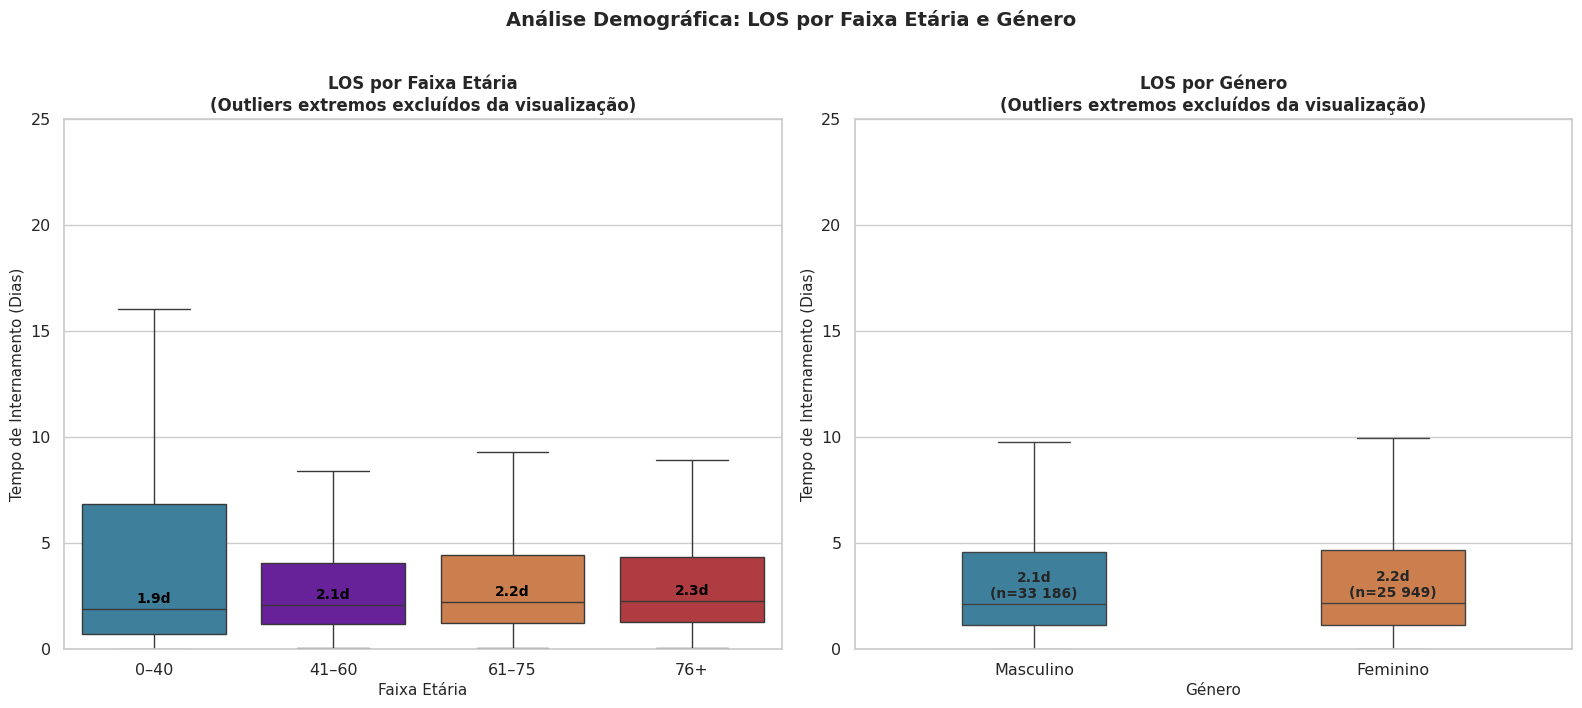

Inferência Estatística (dados não normais / assimétricos)

Teste Kruskal-Wallis (LOS por Faixa Etária):
  H = 288.05 | p-value = 3.8401e-62
  - Diferença estatisticamente significativa (p < 0.05)

Teste Mann-Whitney U (LOS por Género):
  U = 429029195 | p-value = 4.5397e-01
  - Sem diferença estatisticamente significativa


In [18]:
# %%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("A extrair demografia por estadia para inferência estatística\n")

# Selecionar uma linha por estadia em UCI
cols_demo = ['ICUSTAY_ID', 'SUBJECT_ID', 'IDADE', 'GENDER_BIN', 'LOS_DIAS']
demo = df_clean[cols_demo].drop_duplicates('ICUSTAY_ID').copy()

# Garantir que idade e LOS são numéricos
demo['IDADE'] = pd.to_numeric(demo['IDADE'], errors='coerce')
demo['LOS_DIAS'] = pd.to_numeric(demo['LOS_DIAS'], errors='coerce')

# Remover observações sem idade, género ou LOS
demo = demo.dropna(subset=['IDADE', 'GENDER_BIN', 'LOS_DIAS']).copy()

# Criar faixas etárias
# Nota: usa-se np.inf no último intervalo para evitar excluir idades elevadas.
bins_idade = [0, 40, 60, 75, np.inf]
labels_idade = ['0–40', '41–60', '61–75', '76+']

demo['FAIXA_ETARIA'] = pd.cut(
    demo['IDADE'],
    bins=bins_idade,
    labels=labels_idade,
    include_lowest=True,
    right=True
)

demo['GENERO_LABEL'] = demo['GENDER_BIN'].map({1: 'Masculino', 0: 'Feminino'})

# Remover casos que não ficaram classificados
demo = demo.dropna(subset=['FAIXA_ETARIA', 'GENERO_LABEL']).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Boxplot LOS por Faixa Etária
ax = axes[0]
palette_faixas = ['#2E86AB', '#6A0DAD', '#E07B39', '#C1292E']

sns.boxplot(
    data=demo,
    x='FAIXA_ETARIA',
    y='LOS_DIAS',
    order=labels_idade,
    palette=palette_faixas,
    showfliers=False,
    ax=ax
)

# Anotar mediana em cada caixa
for i, faixa in enumerate(labels_idade):
    valores = demo.loc[demo['FAIXA_ETARIA'] == faixa, 'LOS_DIAS'].dropna()
    if len(valores) > 0:
        med = valores.median()
        ax.text(
            i,
            med + 0.3,
            f'{med:.1f}d',
            ha='center',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

ax.set_title(
    'LOS por Faixa Etária\n(Outliers extremos excluídos da visualização)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Faixa Etária', fontsize=11)
ax.set_ylabel('Tempo de Internamento (Dias)', fontsize=11)
ax.set_ylim(0, 25)

# Gráfico 2: Boxplot LOS por Género
ax = axes[1]
ordem_genero = ['Masculino', 'Feminino']

sns.boxplot(
    data=demo,
    x='GENERO_LABEL',
    y='LOS_DIAS',
    order=ordem_genero,
    palette={'Masculino': '#2E86AB', 'Feminino': '#E07B39'},
    showfliers=False,
    ax=ax,
    width=0.4
)

for i, genero in enumerate(ordem_genero):
    valores = demo.loc[demo['GENERO_LABEL'] == genero, 'LOS_DIAS'].dropna()
    if len(valores) > 0:
        med = valores.median()
        count = len(valores)
        ax.text(
            i,
            med + 0.3,
            f'{med:.1f}d\n(n={count:,})'.replace(',', ' '),
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

ax.set_title(
    'LOS por Género\n(Outliers extremos excluídos da visualização)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Género', fontsize=11)
ax.set_ylabel('Tempo de Internamento (Dias)', fontsize=11)
ax.set_ylim(0, 25)

plt.suptitle(
    'Análise Demográfica: LOS por Faixa Etária e Género',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig('los_demografico.png', dpi=150, bbox_inches='tight')
plt.show()

# Testes estatísticos não paramétricos
print("Inferência Estatística (dados não normais / assimétricos)\n")

# Teste Kruskal-Wallis (>2 grupos)
grupos_faixa = [
    demo.loc[demo['FAIXA_ETARIA'] == faixa, 'LOS_DIAS'].dropna()
    for faixa in labels_idade
]

# Garantir que só são usados grupos não vazios
grupos_faixa_validos = [grupo for grupo in grupos_faixa if len(grupo) > 0]

if len(grupos_faixa_validos) >= 2:
    stat_kw, p_kw = stats.kruskal(*grupos_faixa_validos)

    print("Teste Kruskal-Wallis (LOS por Faixa Etária):")
    print(f"  H = {stat_kw:.2f} | p-value = {p_kw:.4e}")
    print(
        "  - "
        + (
            "Diferença estatisticamente significativa (p < 0.05)"
            if p_kw < 0.05
            else "Sem diferença estatisticamente significativa"
        )
        + "\n"
    )
else:
    print("Teste Kruskal-Wallis não realizado: número insuficiente de grupos etários válidos.\n")

# Teste Mann-Whitney U (2 grupos)
grupo_masculino = demo.loc[demo['GENERO_LABEL'] == 'Masculino', 'LOS_DIAS'].dropna()
grupo_feminino = demo.loc[demo['GENERO_LABEL'] == 'Feminino', 'LOS_DIAS'].dropna()

if len(grupo_masculino) > 0 and len(grupo_feminino) > 0:
    stat_mw, p_mw = stats.mannwhitneyu(
        grupo_masculino,
        grupo_feminino,
        alternative='two-sided'
    )

    print("Teste Mann-Whitney U (LOS por Género):")
    print(f"  U = {stat_mw:.0f} | p-value = {p_mw:.4e}")
    print(
        "  - "
        + (
            "Diferença estatisticamente significativa (p < 0.05)"
            if p_mw < 0.05
            else "Sem diferença estatisticamente significativa"
        )
    )
else:
    print("Teste Mann-Whitney U não realizado: um dos grupos de género está vazio.")

> **Análise demográfica do `LOS_DIAS`**
>
> A análise por faixa etária mostra uma diferença estatisticamente significativa na distribuição do `LOS_DIAS` entre grupos etários. O teste de Kruskal-Wallis apresentou `H = 205.94` e `p-value = 2.1981e-44`, indicando que pelo menos uma faixa etária apresenta uma distribuição de LOS diferente das restantes.
>
> Visualmente, observa-se um aumento gradual da mediana do LOS com a idade: a faixa 18–40 apresenta mediana de 1.9 dias, enquanto as faixas mais avançadas apresentam medianas próximas de 2.2–2.3 dias. Embora esta diferença seja estatisticamente significativa, a magnitude visual da diferença é moderada, pelo que a sua relevância preditiva deverá ser avaliada na Fase 2.
>
> Na comparação por género, o teste de Mann-Whitney U apresentou `p-value = 0.454`, superior ao limiar de significância de 0.05. Assim, não há evidência estatística de uma diferença relevante no `LOS_DIAS` entre os grupos masculino e feminino nesta análise univariada.
>
> Estes resultados sugerem que `IDADE` poderá conter informação útil para a modelação preditiva. A variável `GENDER_BIN`, apesar de não apresentar associação univariada significativa com o LOS, pode ainda ser mantida inicialmente na matriz preditiva e avaliada posteriormente através de regularização, importância de variáveis ou seleção de features.

### 7.6 Análise Estatística por Paciente (`SUBJECT_ID`)

O enunciado solicita uma análise estatística e visualização dos dados ao nível do paciente (`SUBJECT_ID`). Esta secção avalia a variabilidade entre pacientes, considerando que um mesmo paciente pode ter uma ou mais estadias em UCI.

Esta análise é importante por dois motivos:

1. permite caracterizar a distribuição do número de estadias por paciente;
2. justifica a necessidade de, na Fase 2, separar treino e teste por `SUBJECT_ID`, evitando que estadias diferentes do mesmo paciente apareçam simultaneamente nos dois conjuntos.

Assim, esta etapa reforça a decisão metodológica de usar `ICUSTAY_ID` como unidade de observação, mas `SUBJECT_ID` como variável de agrupamento para validação futura.

A calcular estatísticas agregadas por SUBJECT_ID...

Estadias UCI únicas identificadas: 59 135
Pacientes únicos identificados: 44 983

Estatisticas Descritivas por SUBJECT_ID



,n_estadias,n_registos,los_total_dias,los_medio_dias,idade
count,44983.00,44983.00,44983.00,44983.00,44983.00
mean,1.31,368.43,6.58,5.10,54.09
std,0.98,601.40,12.14,9.93,27.73
min,1.00,1.00,0.01,0.01,0.00
25%,1.00,127.00,1.22,1.18,41.00
50%,1.00,281.00,2.64,2.19,61.00
75%,1.00,459.00,6.40,4.74,76.00
max,41.00,28776.00,268.62,171.62,90.00



Distribuição do número de estadias UCI por paciente:


,n_estadias,n_pacientes
0,1,36697
1,2,5513
2,3,1515
3,4,624
4,5,278
5,6,144
6,7,74
7,8,38
8,9,26
9,10,22


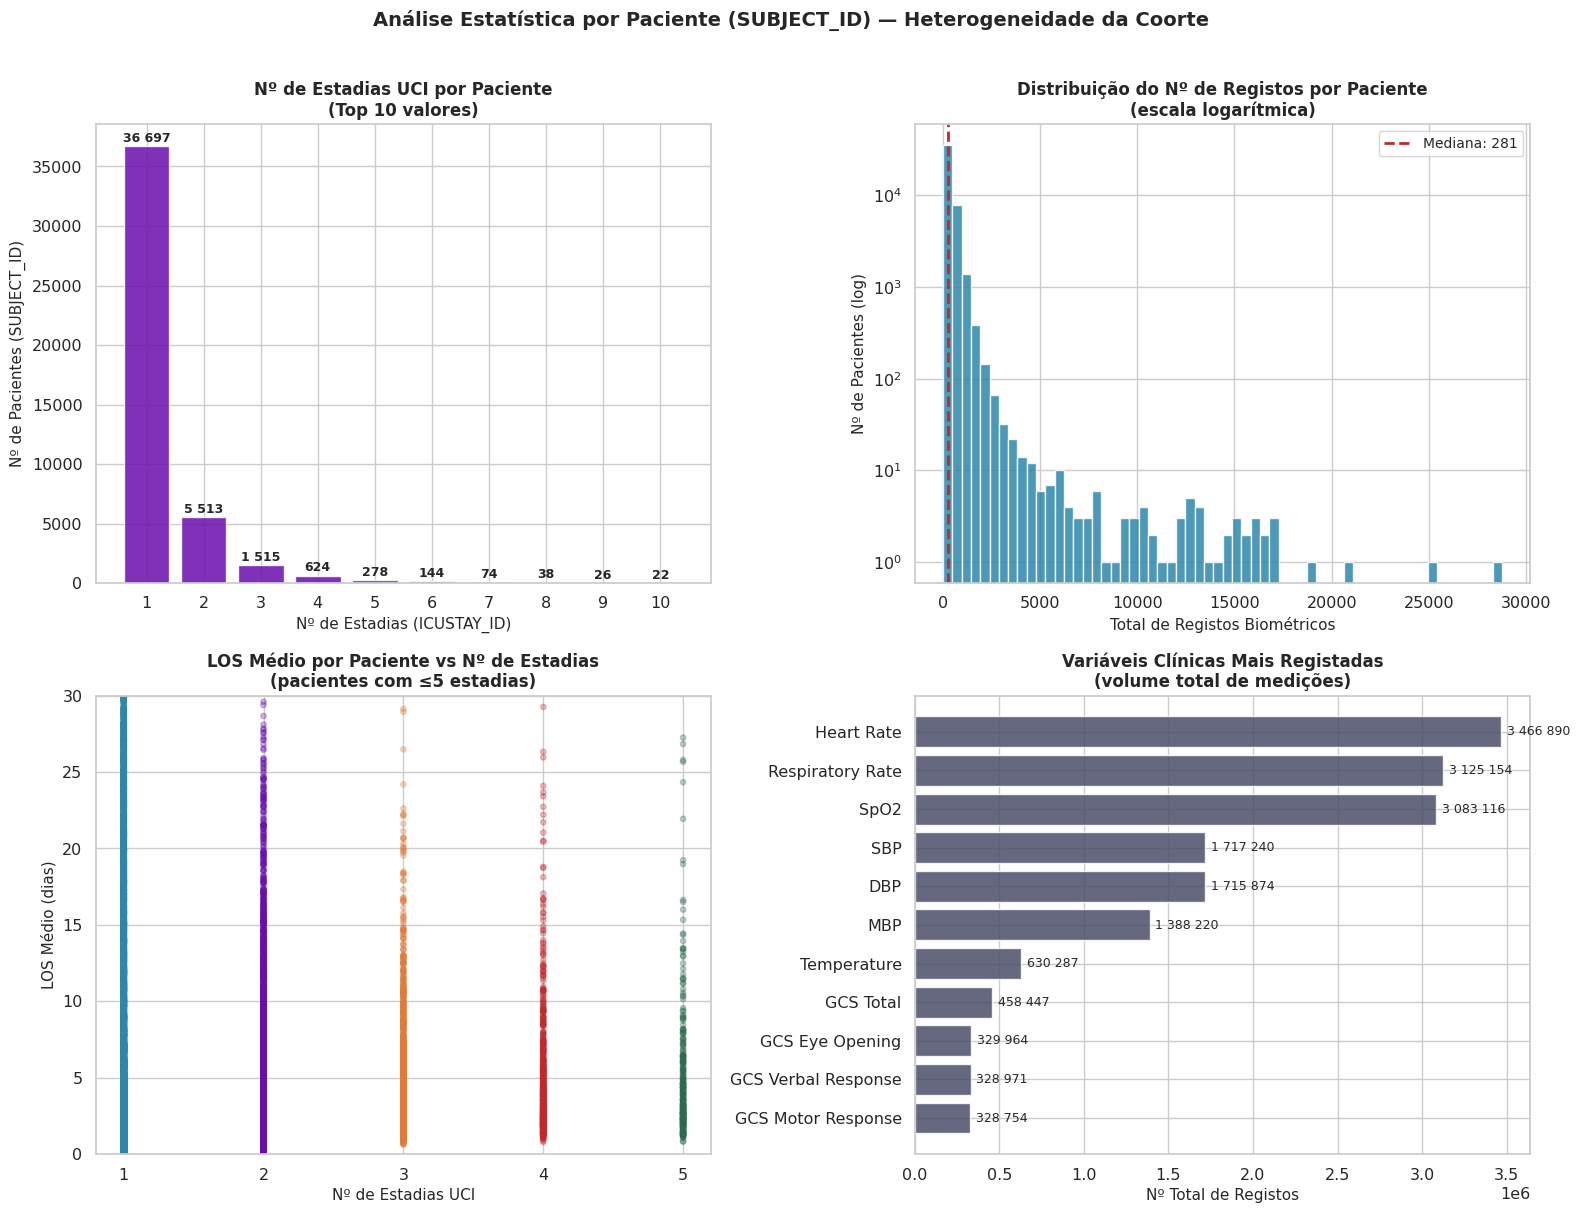


Verificações finais 
Nº de pacientes em stats_por_paciente: 44 983
Nº de linhas em stats_por_paciente: 44 983
LOS total médio por paciente: 6.58 dias
LOS médio por estadia/paciente: 5.10 dias
Nº mediano de registos por paciente: 281

Tempo execução: 12.4s
CPU times: user 11.5 s, sys: 779 ms, total: 12.2 s
Wall time: 12.4 s


In [19]:
%%time
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

_t0 = time.time()
print("A calcular estatísticas agregadas por SUBJECT_ID...\n")


# uma linha por estadia na uci
df_estadias_unicas = (
    df_clean[
        [
            'SUBJECT_ID',
            'ICUSTAY_ID',
            'LOS_DIAS',
            'IDADE',
            'GENDER_BIN'
        ]
    ]
    .drop_duplicates(subset=['ICUSTAY_ID'])
    .copy()
)

print(f"Estadias UCI únicas identificadas: {df_estadias_unicas['ICUSTAY_ID'].nunique():,}".replace(',', ' '))
print(f"Pacientes únicos identificados: {df_estadias_unicas['SUBJECT_ID'].nunique():,}".replace(',', ' '))


# Numero total de registos por paciente

registos_por_paciente = (
    df_clean
    .groupby('SUBJECT_ID')['VALUENUM']
    .count()
    .rename('n_registos')
)


# Agregação por SUBJECT_ID
stats_por_paciente = (
    df_estadias_unicas
    .groupby('SUBJECT_ID')
    .agg(
        n_estadias=('ICUSTAY_ID', 'nunique'),
        los_total_dias=('LOS_DIAS', 'sum'),
        los_medio_dias=('LOS_DIAS', 'mean'),
        idade=('IDADE', 'first'),
        genero=('GENDER_BIN', 'first')
    )
    .merge(registos_por_paciente, on='SUBJECT_ID', how='left')
    .reset_index()
)

# Garantir que não há valores nulos em n_registos
stats_por_paciente['n_registos'] = stats_por_paciente['n_registos'].fillna(0).astype(int)


#Estatisticas
print("\nEstatisticas Descritivas por SUBJECT_ID\n")

resumo_paciente = stats_por_paciente[
    [
        'n_estadias',
        'n_registos',
        'los_total_dias',
        'los_medio_dias',
        'idade'
    ]
].describe().round(2)

display(resumo_paciente)

print("\nDistribuição do número de estadias UCI por paciente:")
display(
    stats_por_paciente['n_estadias']
    .value_counts()
    .sort_index()
    .rename_axis('n_estadias')
    .reset_index(name='n_pacientes')
)


#visualização dos resultados
fig, axes = plt.subplots(2, 2, figsize=(16, 12))



# Distribuição do número de estadias UCI por paciente
ax = axes[0, 0]

contagem_estadias = (
    stats_por_paciente['n_estadias']
    .value_counts()
    .sort_index()
    .head(10)
)

ax.bar(
    contagem_estadias.index.astype(str),
    contagem_estadias.values,
    color='#6A0DAD',
    alpha=0.85,
    edgecolor='white'
)

ax.set_title(
    'Nº de Estadias UCI por Paciente\n(Top 10 valores)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Nº de Estadias (ICUSTAY_ID)', fontsize=11)
ax.set_ylabel('Nº de Pacientes (SUBJECT_ID)', fontsize=11)

for i, (_, val) in enumerate(contagem_estadias.items()):
    ax.text(
        i,
        val + max(contagem_estadias.values) * 0.01,
        f'{val:,}'.replace(',', ' '),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )


# Distribuição do número de registos biométricos por paciente
ax = axes[0, 1]

ax.hist(
    stats_por_paciente['n_registos'],
    bins=60,
    color='#2E86AB',
    alpha=0.85,
    edgecolor='white',
    log=True
)

ax.set_title(
    'Distribuição do Nº de Registos por Paciente\n(escala logarítmica)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Total de Registos Biométricos', fontsize=11)
ax.set_ylabel('Nº de Pacientes (log)', fontsize=11)

mediana_reg = stats_por_paciente['n_registos'].median()

ax.axvline(
    mediana_reg,
    color='#C1292E',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {mediana_reg:.0f}'
)

ax.legend(fontsize=10)


# LOS médio por paciente vs número de estadias
ax = axes[1, 0]

scatter_data = stats_por_paciente[
    stats_por_paciente['n_estadias'] <= 5
].copy()

cores_scatter = scatter_data['n_estadias'].map(
    {
        1: '#2E86AB',
        2: '#6A0DAD',
        3: '#E07B39',
        4: '#C1292E',
        5: '#2D6A4F'
    }
)

ax.scatter(
    scatter_data['n_estadias'],
    scatter_data['los_medio_dias'],
    c=cores_scatter,
    alpha=0.3,
    s=15
)

ax.set_title(
    'LOS Médio por Paciente vs Nº de Estadias\n(pacientes com ≤5 estadias)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Nº de Estadias UCI', fontsize=11)
ax.set_ylabel('LOS Médio (dias)', fontsize=11)
ax.set_ylim(0, 30)
ax.set_xticks(sorted(scatter_data['n_estadias'].unique()))


# Variáveis clínicas mais registadas
ax = axes[1, 1]

top_items = (
    df_clean
    .groupby('NOME_SINAL')['VALUENUM']
    .count()
    .sort_values(ascending=False)
    .head(len(SINAIS_VITAIS))
)

bars = ax.barh(
    top_items.index[::-1],
    top_items.values[::-1],
    color='#4A4E69',
    alpha=0.85,
    edgecolor='white'
)

ax.set_title(
    'Variáveis Clínicas Mais Registadas\n(volume total de medições)',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Nº Total de Registos', fontsize=11)

for bar, val in zip(bars, top_items.values[::-1]):
    ax.text(
        bar.get_width() + top_items.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}'.replace(',', ' '),
        va='center',
        fontsize=9
    )


#formatação final
plt.suptitle(
    'Análise Estatística por Paciente (SUBJECT_ID) — Heterogeneidade da Coorte',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig('eda_por_subject_id.png', dpi=150, bbox_inches='tight')
plt.show()


#verificações finais
print("\nVerificações finais ")
print(f"Nº de pacientes em stats_por_paciente: {stats_por_paciente['SUBJECT_ID'].nunique():,}".replace(',', ' '))
print(f"Nº de linhas em stats_por_paciente: {len(stats_por_paciente):,}".replace(',', ' '))
print(f"LOS total médio por paciente: {stats_por_paciente['los_total_dias'].mean():.2f} dias")
print(f"LOS médio por estadia/paciente: {stats_por_paciente['los_medio_dias'].mean():.2f} dias")
print(f"Nº mediano de registos por paciente: {stats_por_paciente['n_registos'].median():.0f}")

print(f"\nTempo execução: {time.time() - _t0:.1f}s")

> **Análise estatística por paciente**
>
> A análise ao nível de `SUBJECT_ID` confirma que a população analisada contém 44 983 pacientes únicos e 59 135 estadias UCI. Em média, cada paciente apresenta 1.31 estadias, embora a mediana seja 1, indicando que a maioria dos pacientes tem apenas uma passagem pela UCI.
>
> A distribuição do número de estadias mostra que 36 697 pacientes têm uma única estadia, enquanto um subconjunto menor apresenta múltiplas readmissões. O valor máximo observado é de 41 estadias UCI para um mesmo paciente, evidenciando a existência de casos com elevada recorrência clínica.
>
> A análise do número de registos por paciente também mostra forte heterogeneidade. A mediana é de 281 registos por paciente, mas existem pacientes com volumes muito superiores de medições, refletindo diferenças na duração da estadia, intensidade de monitorização e número de admissões.
>
> Estes resultados reforçam duas decisões metodológicas importantes: a unidade de observação da matriz preditiva deve ser `ICUSTAY_ID`, porque cada estadia representa um episódio clínico distinto; porém, na Fase 2, a separação entre treino e teste deve ser feita por `SUBJECT_ID`, para evitar que estadias diferentes do mesmo paciente apareçam em ambos os conjuntos.

### 7.7 Análise Exploratória de Eventos de Input Estadia `ICUSTAY_ID = 200072`

Esta secção responde a um requisito específico do enunciado: a análise visual dos eventos de input associados à estadia `ICUSTAY_ID = 200072`.

Ao contrário das secções anteriores, que se baseiam principalmente em `CHARTEVENTS`, esta análise utiliza a tabela `INPUTEVENTS_MV`, que contém registos de administração de fluidos, nutrição e outros inputs clínicos no sistema MetaVision.

O objetivo é representar temporalmente a quantidade administrada durante as primeiras 24 horas da estadia, usando o eixo X como fração de dia. Assim, `0.25` corresponde a 6 horas e `1.0` corresponde ao final das primeiras 24 horas.

Esta análise tem finalidade exploratória e cumpre o requisito visual do enunciado. Os eventos de input não são incorporados na feature matrix final da Fase 1, uma vez que a matriz preditiva foi construída com base em sinais clínicos de `CHARTEVENTS`, dados temporais de `ICUSTAYS` e informação demográfica de `PATIENTS`.

A extrair dados de input (INPUTEVENTS_MV) para a estadia 200072 via BigQuery...

Dados extraídos com sucesso: 46 registos de input encontrados.



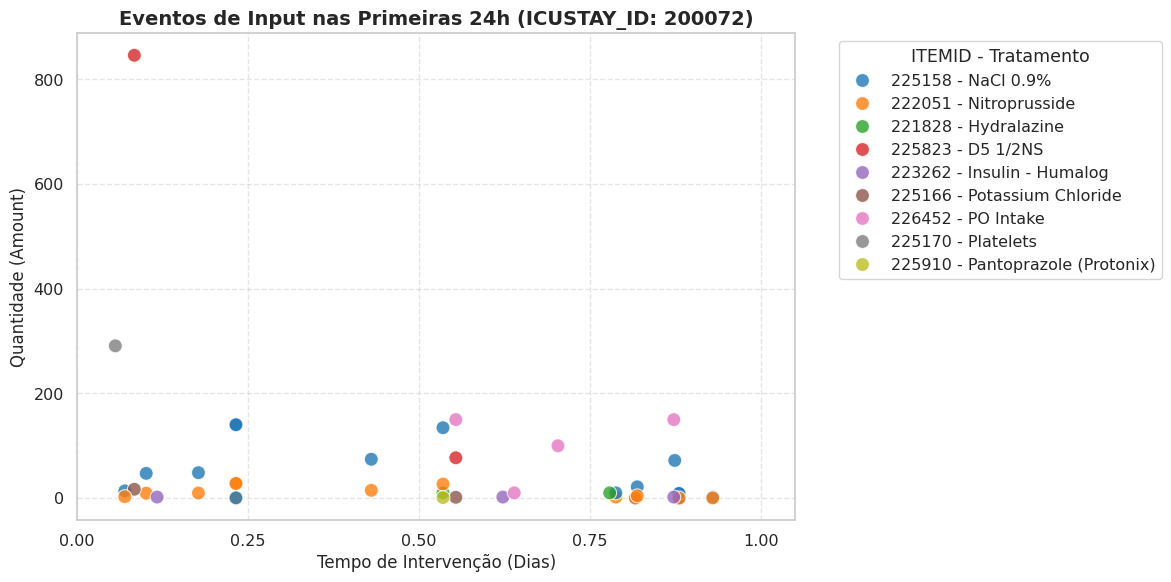

In [20]:
# %%time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("A extrair dados de input (INPUTEVENTS_MV) para a estadia 200072 via BigQuery...\n")

# Query com SAFE_CAST para proteger contra lixo/strings vazias na tabela do BigQuery
query_200072 = f"""
SELECT
    i.STARTTIME,
    i.ITEMID,
    SAFE_CAST(i.AMOUNT AS FLOAT64) AS AMOUNT,
    i.AMOUNTUOM,
    d.LABEL,
    icu.INTIME
FROM `{PROJECT_ID}.{DATASET}.inputevents_mv` i
JOIN `{PROJECT_ID}.{DATASET}.icustays` icu
  ON CAST(i.ICUSTAY_ID AS STRING) = CAST(icu.ICUSTAY_ID AS STRING)
JOIN `{PROJECT_ID}.{DATASET}.d_items` d
  ON CAST(i.ITEMID AS STRING) = CAST(d.ITEMID AS STRING)
WHERE CAST(i.ICUSTAY_ID AS STRING) = '200072'
  AND SAFE_CAST(i.STARTTIME AS TIMESTAMP) BETWEEN SAFE_CAST(icu.INTIME AS TIMESTAMP)
  AND TIMESTAMP_ADD(SAFE_CAST(icu.INTIME AS TIMESTAMP), INTERVAL 24 HOUR)
  AND SAFE_CAST(i.AMOUNT AS FLOAT64) IS NOT NULL
"""

df_200072 = client.query(query_200072).to_dataframe()

if df_200072.empty:
    print("AVISO: Nenhum dado encontrado para o doente 200072 nas primeiras 24h.")
else:
    # Conversão temporal
    df_200072['STARTTIME'] = pd.to_datetime(df_200072['STARTTIME'])
    df_200072['INTIME'] = pd.to_datetime(df_200072['INTIME'])

    # Avaliar e limpar as duas colunas individualmente
    for col in ['STARTTIME', 'INTIME']:
        if str(df_200072[col].dt.tz) != 'None':
            df_200072[col] = df_200072[col].dt.tz_convert('UTC').dt.tz_localize(None)

    # Cálculo: tempo passado desde a admissão a dividir por 86400 segundos (para dar em dias)
    df_200072['DIAS_DESDE_ADMISSAO'] = (df_200072['STARTTIME'] - df_200072['INTIME']).dt.total_seconds() / 86400.0

    # Criar uma coluna combinada para a legenda ficar bonita e sem dar erros
    df_200072['ITEM_DESC'] = df_200072['ITEMID'].astype(str) + " - " + df_200072['LABEL']

    print(f"Dados extraídos com sucesso: {len(df_200072)} registos de input encontrados.\n")

    # Geração do gráfico idêntico ao do enunciado
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.scatterplot(
        data=df_200072,
        x='DIAS_DESDE_ADMISSAO',
        y='AMOUNT',
        hue='ITEM_DESC',
        palette='tab10',
        s=100,
        alpha=0.8,
        ax=ax
    )

    ax.set_title('Eventos de Input nas Primeiras 24h (ICUSTAY_ID: 200072)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tempo de Intervenção (Dias)', fontsize=12)
    ax.set_ylabel('Quantidade (Amount)', fontsize=12)

    # Forçar o eixo X de 0 a 1 (um dia completo) com marcadores a cada 0.25
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0.0, 0.25, 0.50, 0.75, 1.0])

    # Colocar a legenda fora do gráfico para não tapar os pontos
    ax.legend(title='ITEMID - Tratamento', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

> **Análise dos eventos de input da estadia `ICUSTAY_ID = 200072`**
>
> A visualização mostra os eventos de input registados nas primeiras 24 horas da estadia `ICUSTAY_ID = 200072`, com o eixo temporal representado em frações de dia. Observa-se a administração de diferentes itens clínicos, incluindo fluidos, eletrólitos, medicação e produtos sanguíneos.
>
> A maioria dos eventos ocorre de forma pontual ao longo do primeiro dia, com quantidades administradas bastante diferentes entre itens. Destaca-se, por exemplo, um registo de maior volume associado ao item `D5 1/2NS`, enquanto outros inputs apresentam valores mais baixos e dispersos no tempo.
>
> Esta análise confirma a natureza longitudinal e heterogénea da tabela `INPUTEVENTS_MV`, que regista intervenções clínicas administradas ao longo da estadia. No entanto, estes eventos não foram incorporados na matriz preditiva final da Fase 1, uma vez que o modelo foi estruturado a partir dos sinais clínicos de `CHARTEVENTS`, informação temporal de `ICUSTAYS` e dados demográficos de `PATIENTS`.
>
> Assim, esta secção tem finalidade exploratória e cumpre o requisito visual do enunciado, sem alterar a construção da feature matrix principal.

## 8. Análise Comparativa de Janelas Temporais: 24h / 48h / 72h

Esta secção responde à **Questão de Investigação nº 2**: qual deve ser a janela temporal inicial usada para construir a matriz preditiva?

A escolha da janela temporal é uma decisão metodológica central. Uma janela mais curta permite gerar previsões mais cedo, mas pode conter menos informação clínica. Por outro lado, uma janela mais longa acumula mais medições, mas atrasa a previsão e pode deixar de ser útil para estadias curtas.

Foram comparadas três janelas candidatas:

- **24h:** previsão no primeiro dia de UCI;
- **48h:** maior acumulação de dados, mas decisão mais tardia;
- **72h:** maior cobertura temporal, mas menor utilidade para previsão precoce.

A análise seguinte não treina modelos preditivos. O objetivo é comparar as janelas do ponto de vista da cobertura da população analisada, volume de registos, diversidade de sinais clínicos e proporção de estadias cujo `LOS_DIAS` é inferior à própria janela temporal.

Esta comparação permite escolher uma janela principal para a construção da feature matrix da Fase 1, mantendo o equilíbrio entre precocidade da previsão e quantidade de informação clínica disponível.

In [21]:
%%time
import time
import pandas as pd
import gc
import matplotlib.pyplot as plt

_t0 = time.time()

print("A calcular métricas descritivas para as janelas temporais 24h / 48h / 72h...\n")

JANELAS_HORAS = [24, 48, 72]

# Verificação de colunas necessárias
colunas_necessarias = ['ICUSTAY_ID', 'SUBJECT_ID', 'NOME_SINAL', 'VALUENUM', 'LOS_DIAS', 'HORAS_UCI']
colunas_em_falta = [c for c in colunas_necessarias if c not in df_clean.columns]

if len(colunas_em_falta) > 0:
    raise ValueError(f"Colunas em falta em df_clean: {colunas_em_falta}")

resultados_janelas = {}

plot_dados = {
    'janelas': [],
    'estadias_com_dados': [],
    'registos_medios': [],
    'cobertura_sinais': [],
    'los_menor_janela_pct': []
}

# Total de estadias presentes na base longitudinal limpa
total_estadias_base = df_clean['ICUSTAY_ID'].nunique()

for h in JANELAS_HORAS:
    t0 = time.time()

    nome_janela = f'{h}h'
    limite_dias = h / 24

    # Eventos disponíveis desde a entrada na UCI até ao limite da janela.
    # Como a extração principal já respeita o OUTTIME, estadias curtas
    # contribuem apenas com os dados disponíveis até à alta.
    mask_janela = (
        (df_clean['HORAS_UCI'] >= 0) &
        (df_clean['HORAS_UCI'] <= h)
    )

    df_janela_min = df_clean.loc[
        mask_janela,
        ['ICUSTAY_ID', 'SUBJECT_ID', 'NOME_SINAL', 'VALUENUM', 'LOS_DIAS']
    ]

    n_registos = len(df_janela_min)
    n_estadias_com_dados = df_janela_min['ICUSTAY_ID'].nunique()
    n_pacientes_com_dados = df_janela_min['SUBJECT_ID'].nunique()

    reg_por_estadia = (
        round(n_registos / n_estadias_com_dados, 1)
        if n_estadias_com_dados > 0
        else 0
    )

    sinais_unicos = df_janela_min['NOME_SINAL'].nunique()

    # Número de sinais clínicos distintos por estadia dentro da janela
    sinais_por_estadia = (
        df_janela_min
        .groupby('ICUSTAY_ID')['NOME_SINAL']
        .nunique()
    )

    pct_estadias_5_sinais = (
        round(100 * (sinais_por_estadia >= 5).sum() / n_estadias_com_dados, 1)
        if n_estadias_com_dados > 0
        else 0
    )

    mediana_sinais_por_estadia = (
        round(sinais_por_estadia.median(), 1)
        if n_estadias_com_dados > 0
        else 0
    )

    # Tabela com uma linha por estadia dentro da janela
    estadias_janela = (
        df_janela_min[['ICUSTAY_ID', 'LOS_DIAS']]
        .drop_duplicates('ICUSTAY_ID')
    )

    # Estadias cujo LOS total é inferior à janela.
    n_los_menor_janela = (estadias_janela['LOS_DIAS'] < limite_dias).sum()

    pct_los_menor_janela = (
        round(100 * n_los_menor_janela / n_estadias_com_dados, 1)
        if n_estadias_com_dados > 0
        else 0
    )

    cobertura_base_pct = (
        round(100 * n_estadias_com_dados / total_estadias_base, 1)
        if total_estadias_base > 0
        else 0
    )

    resultados_janelas[nome_janela] = {
        'Estadias com dados na janela': f"{n_estadias_com_dados:,}".replace(',', ' '),
        'Pacientes com dados na janela': f"{n_pacientes_com_dados:,}".replace(',', ' '),
        'Cobertura da base (%)': f"{cobertura_base_pct}%",
        'Total de registos': f"{n_registos:,}".replace(',', ' '),
        'Registos / estadia': reg_por_estadia,
        'Sinais únicos': sinais_unicos,
        'Mediana sinais / estadia': mediana_sinais_por_estadia,
        '% Estadias ≥5 sinais': f"{pct_estadias_5_sinais}%",
        'Estadias com LOS < janela': f"{n_los_menor_janela:,} ({pct_los_menor_janela}%)".replace(',', ' '),
        'Tempo processamento': f"{time.time() - t0:.1f}s"
    }

    plot_dados['janelas'].append(nome_janela)
    plot_dados['estadias_com_dados'].append(n_estadias_com_dados)
    plot_dados['registos_medios'].append(reg_por_estadia)
    plot_dados['cobertura_sinais'].append(pct_estadias_5_sinais)
    plot_dados['los_menor_janela_pct'].append(pct_los_menor_janela)

    # Limpeza de objetos temporários
    del df_janela_min
    del sinais_por_estadia
    del estadias_janela
    del mask_janela
    gc.collect()

df_janelas = pd.DataFrame(resultados_janelas).T


print("Comparacao descritiva das janelas termporais ")
display(df_janelas)

print("\nNota metodológica:")
print(
    "A coluna 'Estadias com LOS < janela' não representa erro de extração. "
    "Ela indica os casos em que esperar até ao fim dessa janela seria demasiado tardio, "
    "porque a estadia na UCI terminaria antes desse momento."
)

print(f"\nTempo total da análise de janelas: {time.time() - _t0:.1f}s")

A calcular métricas descritivas para as janelas temporais 24h / 48h / 72h...

Comparacao descritiva das janelas termporais 


,Estadias com dados na janela,Pacientes com dados na janela,Cobertura da base (%),Total de registos,Registos / estadia,Sinais únicos,Mediana sinais / estadia,% Estadias ≥5 sinais,Estadias com LOS < janela,Tempo processamento
24h,59 057,44 940,99.9%,8 198 353,138.8,11,8.0,88.5%,10 638 (18.0%),7.9s
48h,59 115,44 974,100.0%,13 278 585,224.6,11,8.0,88.5%,27 309 (46.2%),13.5s
72h,59 135,44 983,100.0%,16 572 917,280.3,11,8.0,88.5%,36 813 (62.3%),17.0s



Nota metodológica:
A coluna 'Estadias com LOS < janela' não representa erro de extração. Ela indica os casos em que esperar até ao fim dessa janela seria demasiado tardio, porque a estadia na UCI terminaria antes desse momento.

Tempo total da análise de janelas: 42.3s
CPU times: user 38.4 s, sys: 3.54 s, total: 42 s
Wall time: 42.3 s


> **Análise comparativa das janelas temporais**
>
> A comparação entre 24h, 48h e 72h mostra que a janela de 24h já apresenta uma cobertura praticamente total da base, incluindo 59 057 estadias UCI e 44 940 pacientes. Esta janela contém 8 198 353 registos, com uma mediana de 8 sinais clínicos por estadia e 88.5% das estadias com pelo menos 5 sinais disponíveis.
>
> O aumento da janela para 48h e 72h acrescenta volume de registos, passando para 13 278 585 e 16 572 917 medições, respetivamente. No entanto, a diversidade clínica não aumenta de forma relevante, uma vez que as três janelas mantêm os mesmos 11 sinais únicos e a mesma mediana de sinais por estadia.
>
> A principal diferença está na utilidade temporal da previsão. Na janela de 24h, 10 638 estadias, correspondentes a 18.0%, têm `LOS_DIAS` inferior à própria janela. Este valor aumenta para 46.2% na janela de 48h e 62.3% na janela de 72h.
>
> Assim, embora janelas mais longas acumulem mais medições, elas tornam a previsão demasiado tardia para uma proporção elevada de estadias. A janela de 24h representa o melhor compromisso nesta Fase 1: mantém elevada cobertura, preserva diversidade clínica suficiente e permite uma previsão mais precoce.
>
> Por este motivo, a feature matrix final será construída com base nos registos observados nas primeiras 24 horas de internamento na UCI.

### 8.1 Visualização do *Trade-Off* Temporal

A visualização seguinte resume o compromisso entre quatro dimensões relevantes para a escolha da janela temporal:

1. **Número de estadias com dados disponíveis dentro da janela**, avaliando a cobertura da população analisada;
2. **Densidade informacional média**, medida pelo número médio de registos por estadia;
3. **Percentagem de estadias com pelo menos 5 sinais clínicos distintos**, avaliando a diversidade mínima de informação clínica disponível;
4. **Percentagem de estadias cujo `LOS_DIAS` é inferior ao tamanho da janela**, indicando os casos em que a previsão chegaria demasiado tarde para ter utilidade prática.

Esta análise permite comparar o ganho de informação obtido ao aumentar a janela temporal com a perda de precocidade da previsão.

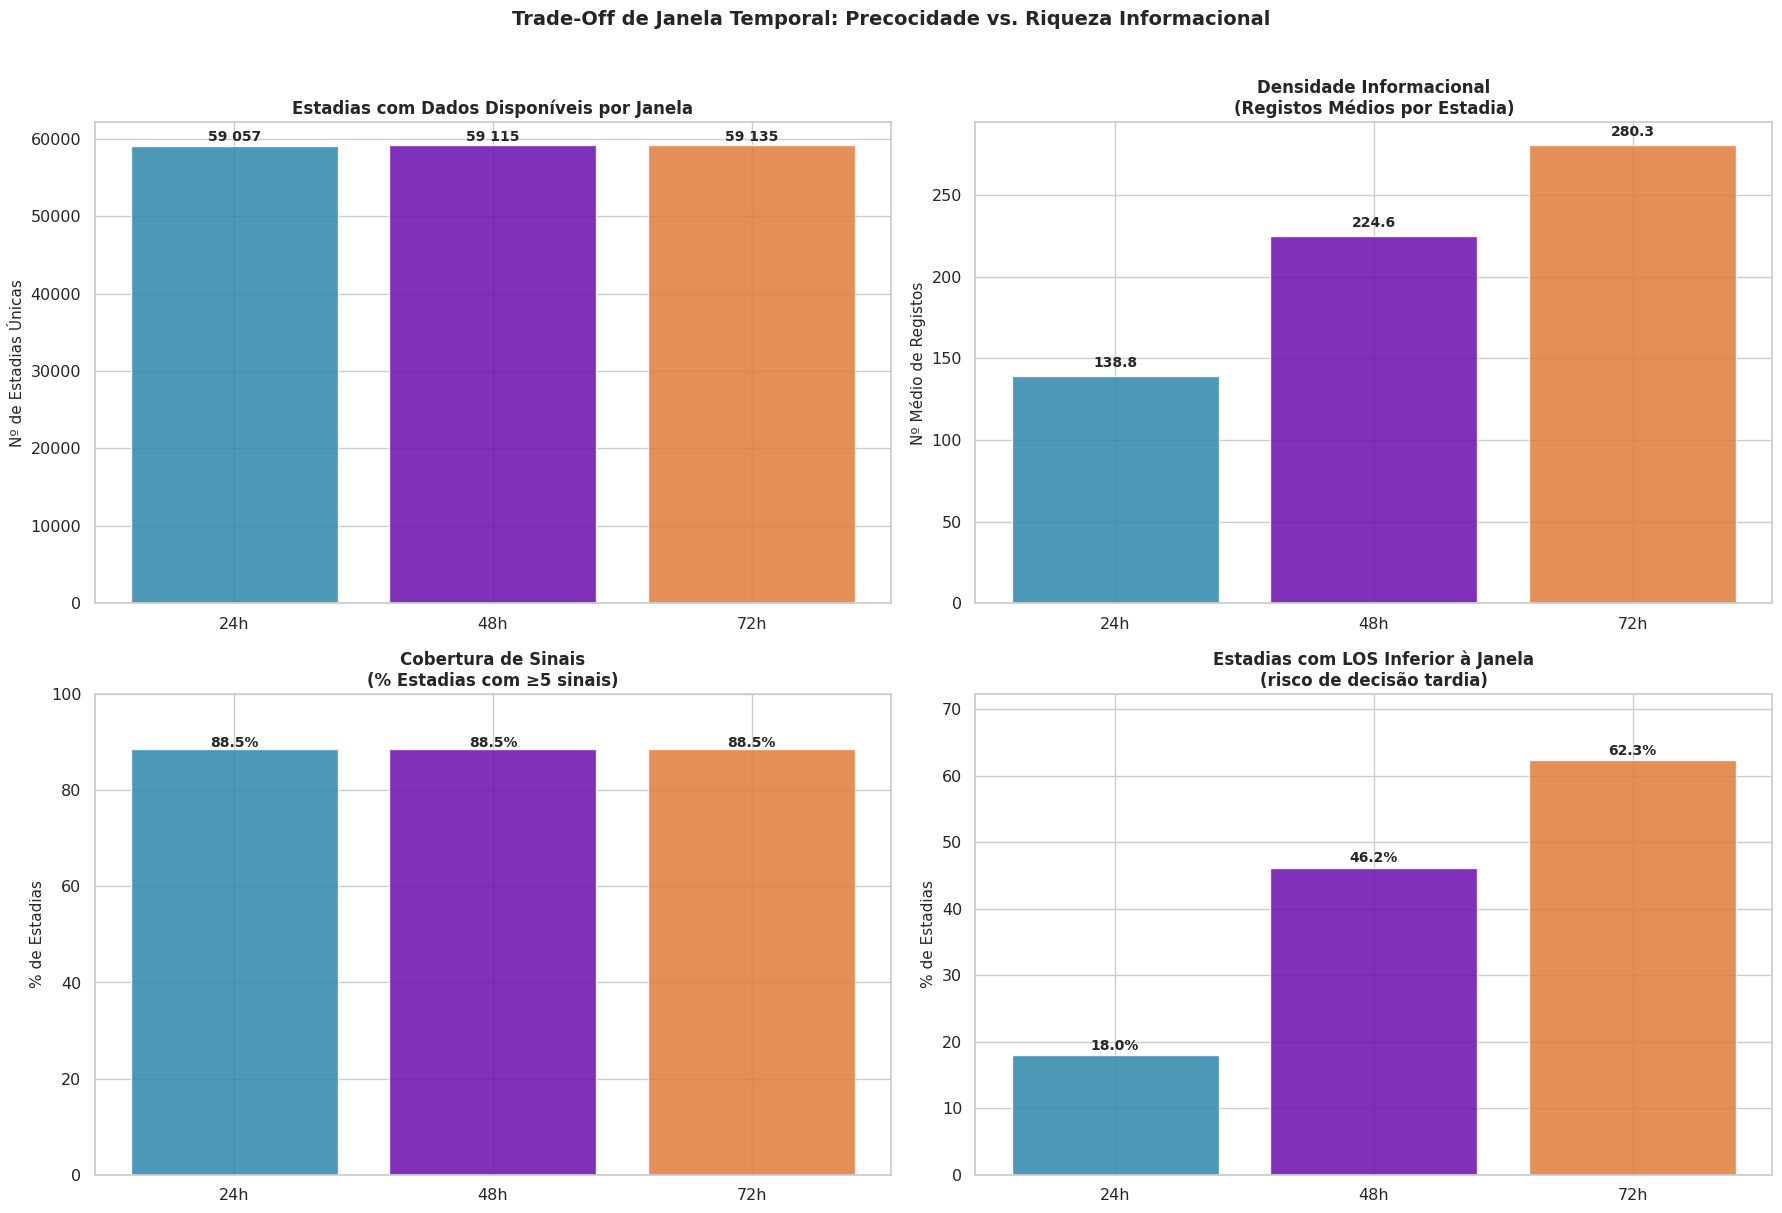

CPU times: user 1.96 s, sys: 25.7 ms, total: 1.99 s
Wall time: 2.05 s


In [22]:
%%time
import matplotlib.pyplot as plt

# Visualização da comparação entre janelas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

cores_janelas = {
    '24h': '#2E86AB',
    '48h': '#6A0DAD',
    '72h': '#E07B39'
}

janelas = plot_dados['janelas']
cores = [cores_janelas[j] for j in janelas]



# Gráfico 1: Estadias com dados disponíveis na janela
ax = axes[0, 0]

barras = ax.bar(
    janelas,
    plot_dados['estadias_com_dados'],
    color=cores,
    alpha=0.85,
    edgecolor='white'
)

for barra, val in zip(barras, plot_dados['estadias_com_dados']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + max(plot_dados['estadias_com_dados']) * 0.01,
        f'{val:,}'.replace(',', ' '),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Estadias com Dados Disponíveis por Janela', fontsize=12, fontweight='bold')
ax.set_ylabel('Nº de Estadias Únicas', fontsize=11)



# Gráfico 2: Registos médios por estadia
ax = axes[0, 1]

barras = ax.bar(
    janelas,
    plot_dados['registos_medios'],
    color=cores,
    alpha=0.85,
    edgecolor='white'
)

for barra, val in zip(barras, plot_dados['registos_medios']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + max(plot_dados['registos_medios']) * 0.02,
        f'{val:.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Densidade Informacional\n(Registos Médios por Estadia)', fontsize=12, fontweight='bold')
ax.set_ylabel('Nº Médio de Registos', fontsize=11)


# Gráfico 3: Cobertura de sinais clínicos
ax = axes[1, 0]

barras = ax.bar(
    janelas,
    plot_dados['cobertura_sinais'],
    color=cores,
    alpha=0.85,
    edgecolor='white'
)

for barra, val in zip(barras, plot_dados['cobertura_sinais']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Cobertura de Sinais\n(% Estadias com ≥5 sinais)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Estadias', fontsize=11)
ax.set_ylim(0, 100)


# Gráfico 4: Estadias com LOS inferior à janela
ax = axes[1, 1]

barras = ax.bar(
    janelas,
    plot_dados['los_menor_janela_pct'],
    color=cores,
    alpha=0.85,
    edgecolor='white'
)

for barra, val in zip(barras, plot_dados['los_menor_janela_pct']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Estadias com LOS Inferior à Janela\n(risco de decisão tardia)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Estadias', fontsize=11)
ax.set_ylim(0, max(plot_dados['los_menor_janela_pct']) + 10)


plt.suptitle(
    'Trade-Off de Janela Temporal: Precocidade vs. Riqueza Informacional',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig('comparacao_janelas.png', dpi=150, bbox_inches='tight')
plt.show()

> **Análise do *trade-off* temporal**
>
> A visualização resume de forma clara o compromisso entre precocidade da previsão e riqueza informacional.
>
> Em primeiro lugar, observa-se que o **número de estadias com dados disponíveis** é muito semelhante nas três janelas: 59 057 para 24h, 59 115 para 48h e 59 135 para 72h. Isto mostra que, em termos de cobertura da população analisada, a janela de 24h já capta praticamente todas as estadias relevantes.
>
> Em segundo lugar, a **densidade informacional média** aumenta com a dimensão da janela: 138.8 registos por estadia em 24h, 224.6 em 48h e 280.3 em 72h. Ou seja, janelas mais longas recolhem mais medições por doente, como seria esperado.
>
> No entanto, esse ganho não se traduz em maior diversidade clínica mínima. A **percentagem de estadias com pelo menos 5 sinais clínicos distintos** mantém-se estável em **88.5%** nas três janelas. Isto sugere que a maior parte da informação clínica essencial já está presente nas primeiras 24 horas.
>
> A diferença mais importante surge na última dimensão: a **percentagem de estadias com `LOS_DIAS` inferior à janela**. Este valor sobe rapidamente de **18.0% em 24h** para **46.2% em 48h** e **62.3% em 72h**. Assim, quanto maior a janela, maior a proporção de casos em que a previsão chegaria tarde demais para ter utilidade prática.
>
> Em conjunto, estes resultados mostram que a janela de **24 horas** oferece o melhor equilíbrio: mantém cobertura muito elevada, retém informação clínica suficiente e preserva a utilidade operacional da previsão. Por esse motivo, esta foi a janela escolhida para a construção da feature matrix final da Fase 1.

### 8.2 Aplicação da Janela Selecionada: 24 Horas

> **Conclusão e decisão metodológica**
>
> Com base na análise comparativa anterior, foi selecionada uma janela temporal inicial de **24 horas** para a construção da matriz preditiva final.
>
> Esta escolha representa um compromisso entre três critérios principais:
>
> 1. **Precocidade clínica**, porque permite gerar previsões ainda no primeiro dia de internamento em UCI;
> 2. **Cobertura da população analisada**, porque a janela de 24h já inclui uma grande quantidade de registos clínicos disponíveis;
> 3. **Densidade informacional suficiente**, porque a maioria das estadias apresenta vários sinais clínicos registados nas primeiras 24 horas.
>
> A janela de 24h também reduz o problema associado a janelas demasiado longas, como 48h ou 72h. Embora estas janelas contenham mais informação clínica, seriam demasiado tardias para uma proporção elevada de estadias curtas, tornando a previsão menos útil em contexto real de apoio à decisão.
>
> Assim, todas as variáveis da matriz final de Machine Learning serão calculadas exclusivamente com eventos observados entre a entrada na UCI (`INTIME`) e as primeiras **24 horas** de internamento.
>
> Para estadias com duração inferior a 24 horas, são utilizados apenas os eventos disponíveis até ao momento de saída da UCI (`OUTTIME`). Estes casos são mantidos nesta fase para preservar a distribuição real do problema e permitir uma análise global da população. No entanto, esta decisão será considerada na fase de modelação, uma vez que, num cenário real de deployment, uma previsão feita exatamente às 24h já não seria aplicável a pacientes que tiveram alta antes desse momento.
>
> Por essa razão, a Fase 2 deverá ter especial cuidado com estas estadias curtas, avaliando se devem ser mantidas na modelação principal ou tratadas separadamente numa análise de sensibilidade.

In [23]:
%%time
import gc


print("A instanciar a matriz longitudinal de 24 horas para modelação")

# Aplicação da janela de 24h
mask_24h = (
    (df_clean['HORAS_UCI'] >= 0) &
    (df_clean['HORAS_UCI'] <= 24)
)

df_24h = df_clean.loc[mask_24h].copy()

# Limpar memória
del mask_24h
gc.collect()

print(f"Shape final   : {df_24h.shape[0]:,} linhas × {df_24h.shape[1]} colunas".replace(',', ' '))
print(f"Estadias      : {df_24h['ICUSTAY_ID'].nunique():,}".replace(',', ' '))
print(f"Pacientes     : {df_24h['SUBJECT_ID'].nunique():,}".replace(',', ' '))
print(f"Sinais        : {df_24h['NOME_SINAL'].nunique()} variáveis clínicas")
print(f"Tempo mínimo  : {df_24h['HORAS_UCI'].min():.2f}h")
print(f"Tempo máximo  : {df_24h['HORAS_UCI'].max():.2f}h")

# Checks de segurança
assert df_24h['HORAS_UCI'].min() >= 0, "Erro: existem eventos antes da entrada na UCI."
assert df_24h['HORAS_UCI'].max() <= 24, "Erro: existem eventos fora da janela de 24h."

print("\nChecks concluídos: df_24h contém apenas eventos entre 0h e 24h após INTIME.")


A instanciar a matriz longitudinal de 24 horas para modelação
Shape final   : 8 198 353 linhas × 19 colunas
Estadias      : 59 057
Pacientes     : 44 940
Sinais        : 11 variáveis clínicas
Tempo mínimo  : 0.00h
Tempo máximo  : 24.00h

Checks concluídos: df_24h contém apenas eventos entre 0h e 24h após INTIME.
CPU times: user 6.34 s, sys: 2.48 s, total: 8.82 s
Wall time: 8.84 s


## 9. Visualização Temporal: Timeline de 3 Perfis Clínicos

Esta secção apresenta uma visualização temporal dos sinais clínicos nas primeiras 24 horas de internamento em UCI, usando três estadias com durações finais distintas de `LOS_DIAS`.

O objetivo é ilustrar como os dados longitudinais registados em `CHARTEVENTS` variam entre diferentes perfis de estadia e reforçar a importância de agregar os sinais clínicos ao nível de `ICUSTAY_ID` antes da modelação.

Foram selecionados três perfis contrastantes:

- **Perfil A - LOS curto (<2 dias):** estadia de curta duração, potencialmente associada a estabilização rápida, transferência ou alta precoce;
- **Perfil B - LOS médio (3–7 dias):** estadia intermédia, representativa de um episódio UCI com monitorização clínica continuada;
- **Perfil C - LOS longo (>14 dias):** estadia prolongada, associada a maior complexidade clínica e necessidade de acompanhamento intensivo.

Esta análise tem finalidade exploratória. A seleção dos perfis serve para visualizar padrões temporais individuais, não para retirar conclusões estatísticas gerais sobre todos os pacientes.

A procurar estadias representativas para os 3 perfis clínicos



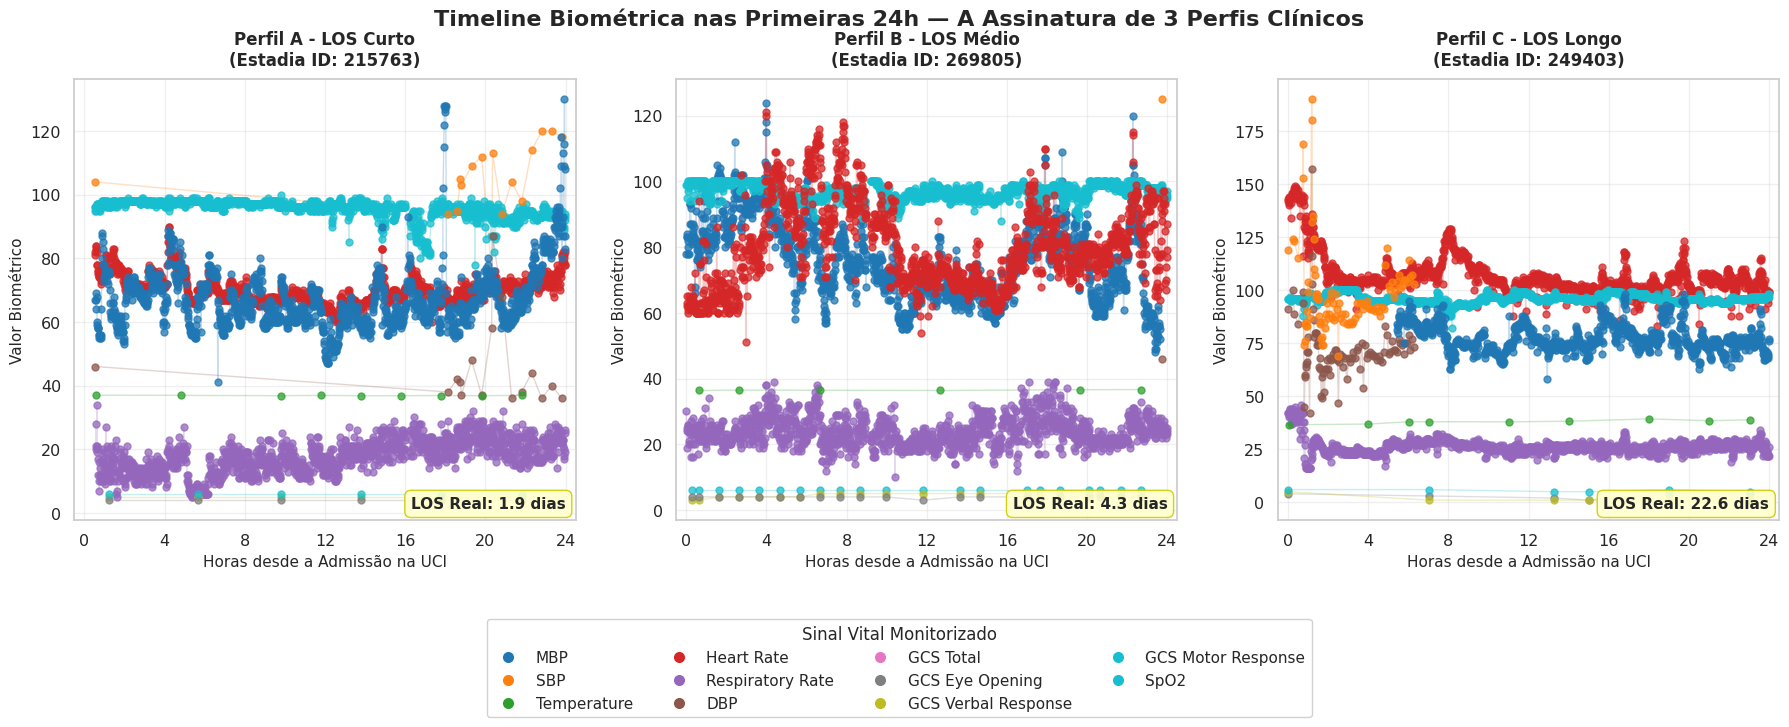

In [24]:
# %%time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print("A procurar estadias representativas para os 3 perfis clínicos\n")

# Seleção de 1 ICUSTAY_ID representativo por perfil
los_por_estadia = df_24h[['ICUSTAY_ID', 'LOS_DIAS']].drop_duplicates('ICUSTAY_ID').set_index('ICUSTAY_ID')

def escolher_estadia(los_min, los_max, min_registos=50):
    """Seleciona a estadia na UCI com mais registos dentro do intervalo de LOS especificado."""
    ids_validos = los_por_estadia[
        (los_por_estadia['LOS_DIAS'] >= los_min) &
        (los_por_estadia['LOS_DIAS'] <  los_max)
    ].index
    if len(ids_validos) == 0:
        return None

    # Contar registos na matriz base limpa agrupando por ICUSTAY_ID
    contagens = df_clean[(df_clean['ICUSTAY_ID'].isin(ids_validos)) & (df_clean['HORAS_UCI'] <= 24)].groupby('ICUSTAY_ID').size()
    contagens = contagens[contagens >= min_registos]
    return contagens.idxmax() if len(contagens) > 0 else None

id_curto  = escolher_estadia(0.5,  2)
id_medio  = escolher_estadia(3,    7)
id_longo  = escolher_estadia(14, 100)

perfis = {
    f'Perfil A - LOS Curto\n(Estadia ID: {id_curto})':  id_curto,
    f'Perfil B - LOS Médio\n(Estadia ID: {id_medio})':  id_medio,
    f'Perfil C - LOS Longo\n(Estadia ID: {id_longo})':  id_longo,
}

# Paleta de cores para os sinais vitais
sinais_unicos = df_clean['NOME_SINAL'].unique()
palette_sinais = dict(zip(sinais_unicos, plt.cm.tab10(np.linspace(0, 1, len(sinais_unicos)))))

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False)

for ax, (titulo, icustay_id) in zip(axes, perfis.items()):
    if icustay_id is None:
        ax.text(0.5, 0.5, 'Sem dados\npara este perfil', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(titulo, fontsize=11, fontweight='bold')
        continue

    # Extrair a timeline da estadia diretamente da matriz não agregada
    df_perf = df_clean[(df_clean['ICUSTAY_ID'] == icustay_id) & (df_clean['HORAS_UCI'] <= 24)].sort_values('HORAS_UCI')
    los_val  = los_por_estadia.loc[icustay_id, 'LOS_DIAS']

    for nome_sinal in df_perf['NOME_SINAL'].unique():
        dados = df_perf[df_perf['NOME_SINAL'] == nome_sinal]
        ax.scatter(dados['HORAS_UCI'], dados['VALUENUM'],
                   label=nome_sinal, color=palette_sinais.get(nome_sinal, 'grey'),
                   s=25, alpha=0.75, zorder=3)
        # Linha de tendência suave
        if len(dados) >= 3:
            ax.plot(dados['HORAS_UCI'], dados['VALUENUM'],
                    color=palette_sinais.get(nome_sinal, 'grey'),
                    alpha=0.25, linewidth=1)

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Horas desde a Admissão na UCI', fontsize=11)
    ax.set_ylabel('Valor Biométrico', fontsize=11)
    ax.set_xlim(-0.5, 24.5)
    ax.set_xticks(range(0, 25, 4))
    ax.grid(True, alpha=0.3)

    # Anotação do LOS real
    ax.text(0.98, 0.02, f'LOS Real: {los_val:.1f} dias',
            transform=ax.transAxes, fontsize=11, ha='right', va='bottom', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFFFCC', edgecolor='#CCCC00', alpha=0.9))

# Legenda unificada fora dos subplots
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cor, markersize=9, label=sinal) for sinal, cor in palette_sinais.items()]
fig.subplots_adjust(bottom=0.25)
fig.legend(handles=handles, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 0.12), fontsize=11,
           title='Sinal Vital Monitorizado', title_fontsize=12, framealpha=0.9)

plt.suptitle('Timeline Biométrica nas Primeiras 24h — A Assinatura de 3 Perfis Clínicos', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('timeline_perfis_clinicos.png', dpi=150, bbox_inches='tight')
plt.show()

> **Análise das timelines dos três perfis clínicos**
>
> A visualização compara a evolução dos sinais clínicos nas primeiras 24 horas de três estadias com durações finais distintas: LOS curto, médio e longo.
>
> No **Perfil A**, correspondente a uma estadia curta (`LOS = 1.9 dias`), observa-se uma evolução relativamente estável dos sinais monitorizados ao longo do primeiro dia, sem grandes oscilações persistentes nos principais sinais clínicos.
>
> No **Perfil B**, com LOS médio (`LOS = 4.3 dias`), verifica-se maior variabilidade temporal, sobretudo nos sinais cardiovasculares e respiratórios. Este padrão sugere uma monitorização mais dinâmica durante as primeiras 24 horas.
>
> No **Perfil C**, associado a uma estadia prolongada (`LOS = 22.6 dias`), observa-se maior instabilidade inicial em alguns sinais, com valores mais dispersos nas primeiras horas. Este perfil ilustra como estadias longas podem apresentar padrões fisiológicos mais complexos logo na fase inicial.
>
> Esta análise tem finalidade ilustrativa e não permite generalizar conclusões para toda a população analisada. No entanto, reforça a importância de transformar os dados longitudinais das primeiras 24 horas numa matriz agregada por `ICUSTAY_ID`, usando estatísticas como média, mínimo, máximo, desvio-padrão e número de medições por sinal clínico.

## 10. Construção da Feature Matrix: Agregação *Wide* por Estadia na UCI

Esta secção representa o **output final da Fase 1** e o **input direto da Fase 2**, dedicada à modelação preditiva.

Até este ponto, o dataset `df_24h` encontra-se no formato *long*, ou seja, cada linha corresponde a uma medição clínica individual registada durante as primeiras 24 horas da estadia em UCI. Para aplicar modelos clássicos de Machine Learning, é necessário transformar estes dados para formato *wide*, onde cada linha representa uma única estadia (`ICUSTAY_ID`) e cada coluna corresponde a uma variável preditiva.

Esta transformação é feita através de agregação estatística por `ICUSTAY_ID`, usando os sinais clínicos observados nas primeiras 24 horas.

### Estratégia de Feature Engineering

Para cada uma das 11 variáveis clínicas selecionadas, são calculadas 5 estatísticas de resumo:

- `mean`: valor médio do sinal durante as primeiras 24 horas;
- `std`: variabilidade do sinal ao longo da janela temporal;
- `min`: valor mínimo registado;
- `max`: valor máximo registado;
- `count`: número de medições registadas, usado como indicador da intensidade de monitorização.

Assim, são geradas **55 features clínicas**:

```text
11 variáveis clínicas × 5 estatísticas = 55 features

In [25]:
%%time

import time
import gc

_t0 = time.time()

print("A construir a Feature Matrix da Fase 1")


# Pivot com agregações estatísticas
pivot = (
    df_24h
    .groupby(['ICUSTAY_ID', 'NOME_SINAL'])['VALUENUM']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .unstack('NOME_SINAL')
)

# Achatar o MultiIndex de colunas:
# de ('mean', 'Heart Rate') para 'Heart_Rate_mean'
pivot.columns = [
    f"{sinal.replace(' ', '_').replace('(', '').replace(')', '')}_{stat}"
    for stat, sinal in pivot.columns
]

pivot = pivot.reset_index()

# Juntar variáveis demográficas + target
demo_cols = ['ICUSTAY_ID', 'SUBJECT_ID', 'IDADE', 'GENDER_BIN', 'LOS_DIAS']

demo = (
    df_24h[demo_cols]
    .drop_duplicates('ICUSTAY_ID')
    .reset_index(drop=True)
)

df_features = pivot.merge(demo, on='ICUSTAY_ID', how='inner')

# Reordenar colunas principais para ficarem no início
cols_inicio = ['ICUSTAY_ID', 'SUBJECT_ID', 'IDADE', 'GENDER_BIN', 'LOS_DIAS']
cols_restantes = [c for c in df_features.columns if c not in cols_inicio]
df_features = df_features[cols_inicio + cols_restantes]

# Correção semântica das features de contagem e desvio-padrão
count_cols = [c for c in df_features.columns if c.endswith('_count')]

for count_col in count_cols:
    prefixo_sinal = count_col.replace('_count', '')
    std_col = f'{prefixo_sinal}_std'

    if std_col in df_features.columns:
        df_features.loc[df_features[count_col] == 1, std_col] = 0

# Se um sinal não foi medido, o número de medições é 0
df_features[count_cols] = df_features[count_cols].fillna(0).astype(int)

# Definir features preditivas
feature_cols = [
    c for c in df_features.columns
    if c not in ['ICUSTAY_ID', 'SUBJECT_ID', 'LOS_DIAS']
]

features_clinicas = [
    c for c in feature_cols
    if c not in ['IDADE', 'GENDER_BIN']
]

n_nulos = int(df_features[feature_cols].isna().sum().sum())

print("Feature Matrix da Fase 1")

print(f"Shape total            : {df_features.shape[0]:,} estadias × {df_features.shape[1]} colunas".replace(',', ' '))
print(f"Estadias únicas        : {df_features['ICUSTAY_ID'].nunique():,}".replace(',', ' '))
print(f"Pacientes únicos       : {df_features['SUBJECT_ID'].nunique():,}".replace(',', ' '))
print(f"Features clínicas      : {len(features_clinicas)}")
print("Features demográficas  : 2 (IDADE, GENDER_BIN)")
print(f"Features preditivas    : {len(feature_cols)}")
print(f"Target (LOS_DIAS)      : min={df_features['LOS_DIAS'].min():.2f}d, mediana={df_features['LOS_DIAS'].median():.2f}d, max={df_features['LOS_DIAS'].max():.2f}d")
print(f"Nulos presentes        : {n_nulos:,} a tratar na Fase 2".replace(',', ' '))
print(f"Tempo de processamento : {time.time() - _t0:.1f}s")


display(
    df_features[
        [
            'ICUSTAY_ID',
            'SUBJECT_ID',
            'IDADE',
            'GENDER_BIN',
            'LOS_DIAS',
            'Heart_Rate_mean',
            'Heart_Rate_std',
            'Heart_Rate_count',
            'SpO2_mean',
            'SpO2_min',
            'SpO2_count',
            'GCS_Total_mean',
            'GCS_Total_count'
        ]
    ].head(8)
)

gc.collect()

A construir a Feature Matrix da Fase 1
Feature Matrix da Fase 1
Shape total            : 59 057 estadias × 60 colunas
Estadias únicas        : 59 057
Pacientes únicos       : 44 940
Features clínicas      : 55
Features demográficas  : 2 (IDADE, GENDER_BIN)
Features preditivas    : 57
Target (LOS_DIAS)      : min=0.01d, mediana=2.14d, max=173.07d
Nulos presentes        : 932 744 a tratar na Fase 2
Tempo de processamento : 5.6s


,ICUSTAY_ID,SUBJECT_ID,IDADE,GENDER_BIN,LOS_DIAS,Heart_Rate_mean,Heart_Rate_std,Heart_Rate_count,SpO2_mean,SpO2_min,SpO2_count,GCS_Total_mean,GCS_Total_count
0,200001,55973,61.0,0,3.0786,100.760000,10.798457,25,98.076923,94.0,26,NaN,0
1,200003,27513,48.0,1,5.8884,99.386364,15.591017,44,95.533333,89.0,45,11.500000,8
2,200006,10950,54.0,1,1.3194,74.136364,5.036017,22,98.541667,94.0,24,15.000000,7
3,200007,20707,43.0,1,1.2914,94.064516,6.016286,31,95.750000,94.0,8,15.000000,5
4,200009,29904,47.0,0,2.1549,95.774194,5.542019,31,99.848485,95.0,33,7.571429,7
5,200010,11861,27.0,0,0.9659,95.869565,11.071275,23,99.090909,97.0,22,NaN,0
6,200011,93535,84.0,0,1.6330,71.000000,5.377422,25,95.440000,89.0,25,NaN,0
7,200012,28448,32.0,0,0.4465,95.818182,7.547426,11,97.272727,95.0,11,15.000000,4


CPU times: user 5.37 s, sys: 415 ms, total: 5.79 s
Wall time: 5.81 s


31

> **Análise da feature matrix final**
>
> A matriz final da Fase 1 contém 59 057 estadias UCI únicas e 60 colunas. Cada linha corresponde a uma única estadia (`ICUSTAY_ID`), cumprindo a unidade de análise definida para o projeto.
>
> A transformação de formato *long* para *wide* permitiu agregar os sinais clínicos das primeiras 24 horas em 55 features clínicas, resultantes da combinação de 11 variáveis com 5 estatísticas de resumo: média, desvio-padrão, mínimo, máximo e número de medições.
>
> A estas features foram adicionadas as variáveis demográficas `IDADE` e `GENDER_BIN`, bem como os identificadores `ICUSTAY_ID` e `SUBJECT_ID` e a variável-alvo `LOS_DIAS`.
>
> A presença de valores nulos na matriz final é esperada, uma vez que nem todos os sinais clínicos são medidos em todas as estadias. Estes nulos foram preservados nesta fase e serão tratados apenas na Fase 2, dentro da pipeline de Machine Learning, para evitar *data leakage*.
>
> Assim, `df_features` constitui o principal output da Fase 1: uma matriz preditiva agregada por estadia UCI, construída exclusivamente com informação disponível nas primeiras 24 horas de internamento.

### 10.1 Análise de Valores em Falta na Feature Matrix

Após a construção da matriz agregada por `ICUSTAY_ID`, é necessário quantificar os valores em falta nas variáveis preditivas. Em dados clínicos reais, a ausência de medições é esperada, porque nem todos os sinais são registados para todos os pacientes durante as primeiras 24 horas.

Nesta etapa, os valores nulos são apenas analisados e documentados. A imputação não é realizada na Fase 1, para evitar qualquer risco de *data leakage*. O tratamento dos nulos será feito na Fase 2, dentro da pipeline de Machine Learning e após a separação entre treino e teste.

In [26]:
%%time


print("Análise de valores em falta na feature matrix ")


feature_cols = [
    c for c in df_features.columns
    if c not in ['ICUSTAY_ID', 'SUBJECT_ID', 'LOS_DIAS']
]

n_total_celulas = df_features[feature_cols].shape[0] * df_features[feature_cols].shape[1]
n_nulos = int(df_features[feature_cols].isna().sum().sum())
pct_nulos = 100 * n_nulos / n_total_celulas

print(f"Total de células preditivas : {n_total_celulas:,}".replace(',', ' '))
print(f"Valores nulos              : {n_nulos:,}".replace(',', ' '))
print(f"Percentagem de nulos       : {pct_nulos:.2f}%")

missing_por_feature = (
    df_features[feature_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_por_feature.columns = ['Feature', '% Nulos']

print("\nTop 20 features com maior percentagem de valores em falta:")
display(missing_por_feature.head(20).round(2))



Análise de valores em falta na feature matrix 
Total de células preditivas : 3 366 249
Valores nulos              : 932 744
Percentagem de nulos       : 27.71%

Top 20 features com maior percentagem de valores em falta:


,Feature,% Nulos
0,GCS_Motor_Response_mean,60.57
1,GCS_Motor_Response_std,60.57
2,GCS_Motor_Response_min,60.57
3,GCS_Motor_Response_max,60.57
4,GCS_Verbal_Response_mean,60.56
5,GCS_Verbal_Response_min,60.56
6,GCS_Verbal_Response_max,60.56
7,GCS_Verbal_Response_std,60.56
8,GCS_Eye_Opening_mean,60.55
9,GCS_Eye_Opening_std,60.55


CPU times: user 58.2 ms, sys: 1.73 ms, total: 60 ms
Wall time: 61.4 ms


> **Análise dos valores em falta na feature matrix**
>
> A feature matrix apresenta 932 744 valores nulos em 3 366 249 células preditivas, correspondendo a 27.71% de valores em falta.
>
> A maior percentagem de nulos concentra-se nas variáveis associadas ao Glasgow Coma Scale, especialmente nas componentes `GCS_Motor_Response`, `GCS_Verbal_Response`, `GCS_Eye_Opening` e `GCS_Total`. Este padrão é esperado, uma vez que os registos neurológicos não são recolhidos com a mesma frequência que sinais continuamente monitorizados, como frequência cardíaca, SpO₂ ou frequência respiratória.
>
> Nesta versão final, as features de contagem (`*_count`) foram tratadas semanticamente: quando um sinal não foi medido, o número de medições foi definido como 0. Por isso, os nulos remanescentes correspondem sobretudo a estatísticas como média, mínimo, máximo e desvio-padrão de sinais ausentes.
>
> Estes nulos não foram imputados na Fase 1. A imputação será realizada apenas na Fase 2, dentro da pipeline de Machine Learning e após a separação treino/teste, evitando que estatísticas calculadas sobre o conjunto de teste influenciem o treino do modelo.
>
> A estratégia inicial prevista será imputação pela mediana para variáveis numéricas, eventualmente complementada com indicadores binários de ausência de medição, uma vez que a própria falta de registo pode conter informação clínica relevante.

### 10.2 Matriz de Correlação entre Sinais Clínicos

A matriz de correlação permite analisar relações lineares entre as variáveis clínicas agregadas na feature matrix. Esta análise é útil para identificar possíveis redundâncias entre features e verificar relações fisiológicas esperadas, como a associação entre variáveis de pressão arterial (`SBP`, `DBP` e `MBP`).

Nesta etapa, a correlação é usada apenas com finalidade exploratória. A decisão final sobre remoção ou manutenção de features será feita na Fase 2, através de modelos com regularização, análise de importância de variáveis e validação preditiva.

A calcular matriz de correlação entre sinais clínicos...



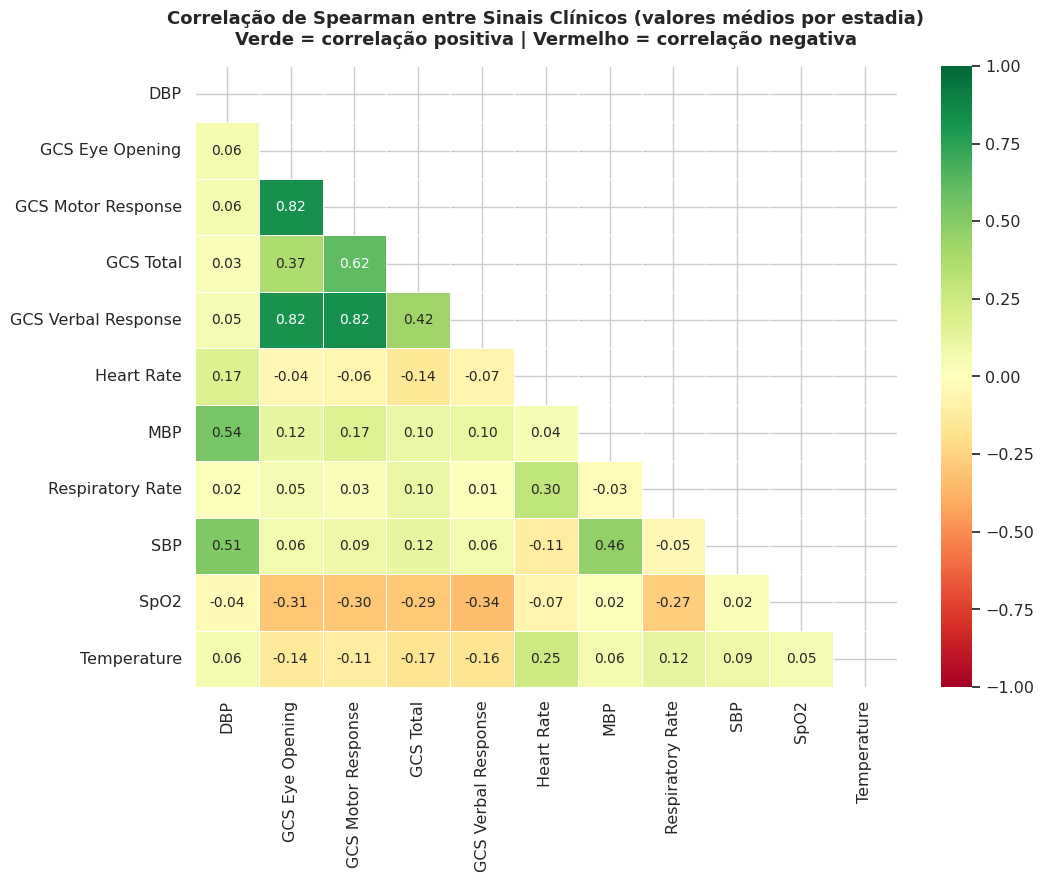

Pares com |correlação| > 0.4:


,Sinal A,Sinal B,Correlação Spearman
0,GCS Motor Response,GCS Eye Opening,0.821022
1,GCS Verbal Response,GCS Motor Response,0.820811
2,GCS Verbal Response,GCS Eye Opening,0.818144
3,GCS Total,GCS Motor Response,0.615345
4,MBP,DBP,0.540947
5,SBP,DBP,0.511972
6,SBP,MBP,0.459652
7,GCS Verbal Response,GCS Total,0.418052



Tempo execução: 1.4s
CPU times: user 1.36 s, sys: 19.5 ms, total: 1.38 s
Wall time: 1.4 s


In [27]:
%%time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

_t0 = time.time()
print("A calcular matriz de correlação entre sinais clínicos...\n")

cols_mean = [c for c in df_features.columns if c.endswith('_mean')]

corr_matrix = df_features[cols_mean].corr(method='spearman')

corr_matrix.columns = [c.replace('_mean', '').replace('_', ' ') for c in corr_matrix.columns]
corr_matrix.index   = [c.replace('_mean', '').replace('_', ' ') for c in corr_matrix.index]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10},
    ax=ax
)
ax.set_title('Correlação de Spearman entre Sinais Clínicos (valores médios por estadia)\n'
             'Verde = correlação positiva | Vermelho = correlação negativa',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlacao_sinais_vitais.png', dpi=150, bbox_inches='tight')
plt.show()

corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Sinal A', 'level_1': 'Sinal B', 0: 'Correlação Spearman'})
    .sort_values('Correlação Spearman', key=abs, ascending=False)
)
print("Pares com |correlação| > 0.4:")
display(corr_pairs[corr_pairs['Correlação Spearman'].abs() > 0.4].reset_index(drop=True))
print(f"\nTempo execução: {time.time()-_t0:.1f}s")

> **Análise da matriz de correlação**
>
> A matriz de correlação de Spearman mostra que a maioria dos sinais clínicos apresenta correlações fracas ou moderadas entre si, sugerindo que as variáveis selecionadas captam dimensões fisiológicas relativamente distintas.
>
> As correlações mais elevadas surgem entre as componentes do Glasgow Coma Scale. Observa-se uma forte associação entre `GCS Motor Response`, `GCS Eye Opening` e `GCS Verbal Response`, com correlações próximas de 0.82. Este resultado é esperado, uma vez que estas variáveis representam componentes relacionadas da avaliação neurológica do paciente.
>
> Também se observam correlações positivas moderadas entre as variáveis de pressão arterial: `DBP`, `SBP` e `MBP`. Por exemplo, `MBP` apresenta correlação de 0.54 com `DBP`, e `SBP` apresenta correlação de 0.51 com `DBP`. Isto é fisiologicamente coerente, dado que estas medidas pertencem ao mesmo sistema cardiovascular.
>
> Fora destes grupos, as correlações são geralmente baixas. Isto indica que variáveis como frequência cardíaca, frequência respiratória, temperatura e SpO₂ não são simplesmente redundantes entre si e podem acrescentar informação complementar ao modelo.
>
> Esta análise não implica a remoção imediata de features. Na Fase 2, a presença de correlações será tratada através de modelos com regularização, validação cruzada e análise de importância das variáveis.

## 11. Análise de Correlação: Features vs. LOS

Antes de avançar para a Fase 2, é útil analisar a associação entre as features construídas e a variável-alvo `LOS_DIAS`.

Nesta secção, são calculadas correlações entre cada variável preditiva e o tempo final de internamento na UCI. O objetivo não é selecionar definitivamente as features nem provar capacidade preditiva, mas sim obter uma primeira leitura exploratória sobre quais variáveis apresentam maior relação monotónica com o `LOS_DIAS`.

Esta análise tem dois objetivos principais:

1. **Validação exploratória do feature engineering:** verificar se algumas das variáveis agregadas nas primeiras 24 horas apresentam associação com o tempo de internamento final;

2. **Interpretação inicial:** identificar sinais clínicos e estatísticas de resumo potencialmente relevantes, que poderão ser comparados na Fase 2 com métodos de importância de variáveis, regularização e, se aplicável, técnicas de explicabilidade como SHAP.

As correlações devem ser interpretadas com cautela, porque relações fracas individualmente podem ainda contribuir para modelos multivariados, e uma correlação elevada não implica causalidade.

A calcular matrizes de correlação de Spearman (Robusto a distribuições assimétricas)



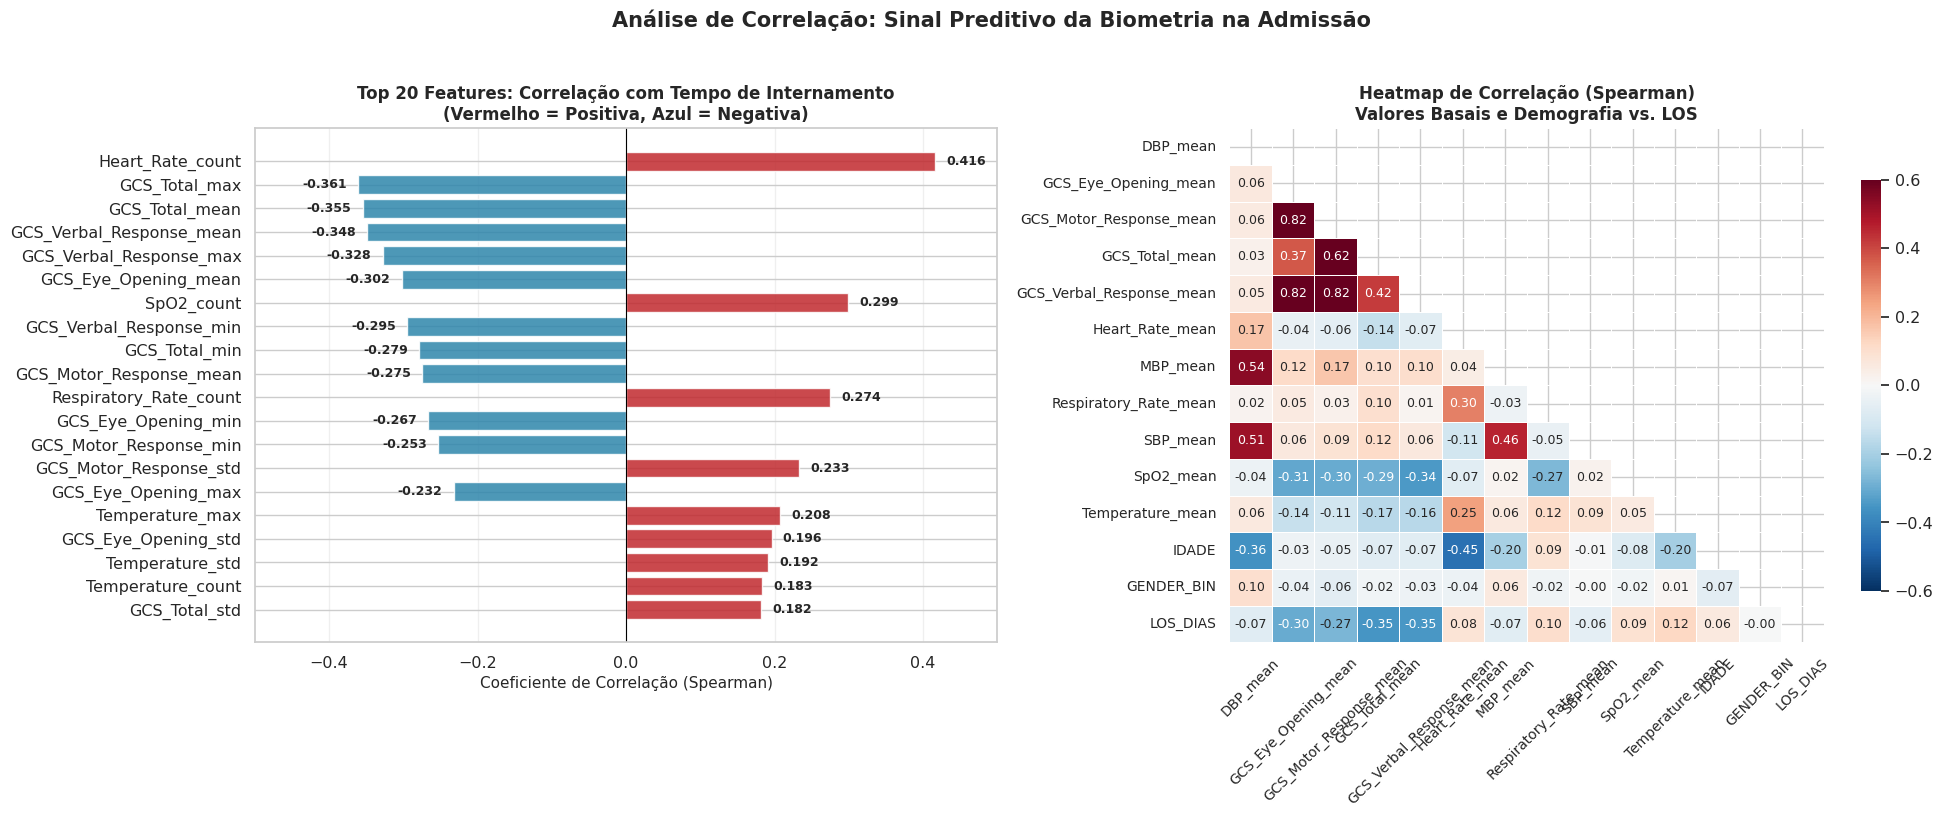

Top 5 features com associação positiva com LOS:
Heart_Rate_count          0.416271
SpO2_count                0.299156
Respiratory_Rate_count    0.274440
GCS_Motor_Response_std    0.232832
Temperature_max           0.207805

Top 5 features com associação negativa com LOS:
GCS_Total_max              -0.360708
GCS_Total_mean             -0.354739
GCS_Verbal_Response_mean   -0.348459
GCS_Verbal_Response_max    -0.327803
GCS_Eye_Opening_mean       -0.302281
CPU times: user 15.8 s, sys: 80.3 ms, total: 15.8 s
Wall time: 16 s


In [28]:
%%time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("A calcular matrizes de correlação de Spearman (Robusto a distribuições assimétricas)\n")

# Correlação de Spearman (Ordenada pelo valor absoluto para o Top 20)
correlacoes = (
    df_features[feature_cols + ['LOS_DIAS']]
    .corr(method='spearman')['LOS_DIAS']
    .drop('LOS_DIAS')
    .sort_values(key=abs, ascending=False)
)

# Top 20 features com maior impacto global
top20 = correlacoes.head(20)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Top 20 correlações (barras horizontais)
ax = axes[0]
cores_barra = ['#C1292E' if v > 0 else '#2E86AB' for v in top20.values]
barras = ax.barh(top20.index[::-1], top20.values[::-1],
                 color=cores_barra[::-1], alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente de Correlação (Spearman)', fontsize=11)
ax.set_title('Top 20 Features: Correlação com Tempo de Internamento\n(Vermelho = Positiva, Azul = Negativa)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, 0.5)

for barra, val in zip(barras, top20.values[::-1]):
    offset = 0.015 if val >= 0 else -0.015
    ax.text(val + offset, barra.get_y() + barra.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Gráfico 2: Heatmap completo (Apenas médias para legibilidade visual)
ax = axes[1]
cols_mean = [c for c in feature_cols if '_mean' in c] + ['IDADE', 'GENDER_BIN', 'LOS_DIAS']
corr_matrix = df_features[cols_mean].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            vmin=-0.6, vmax=0.6, annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap de Correlação (Spearman)\nValores Basais e Demografia vs. LOS',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.suptitle('Análise de Correlação: Sinal Preditivo da Biometria na Admissão',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('correlacao_features_los.png', dpi=150, bbox_inches='tight')
plt.show()

# Extração correta dos positivos e negativos

print("Top 5 features com associação positiva com LOS:")
print(correlacoes[correlacoes > 0].sort_values(ascending=False).head(5).to_string())

print("\nTop 5 features com associação negativa com LOS:")
print(correlacoes[correlacoes < 0].sort_values(ascending=True).head(5).to_string())


> **Análise da correlação entre features e `LOS_DIAS`**
>
> A análise de correlação de Spearman mostra que as features mais associadas positivamente ao tempo de internamento incluem sobretudo variáveis de contagem, isto é, o número de medições registadas nas primeiras 24 horas.
>
> A feature com maior correlação positiva é `Heart_Rate_count` (`ρ = 0.416`), seguida de `SpO2_count` (`ρ = 0.299`) e `Respiratory_Rate_count` (`ρ = 0.274`). Este padrão sugere que estadias mais longas tendem a estar associadas a maior intensidade de monitorização clínica logo no primeiro dia de UCI.
>
> Também surge entre os principais preditores positivos `GCS_Motor_Response_std` (`ρ = 0.233`), sugerindo que maior variabilidade na resposta motora poderá estar associada a estadias mais prolongadas. A feature `Temperature_max` (`ρ = 0.208`) apresenta uma associação positiva mais moderada.
>
> Por outro lado, as features com maior correlação negativa estão associadas ao Glasgow Coma Scale, nomeadamente `GCS_Total_max` (`ρ = -0.361`), `GCS_Total_mean` (`ρ = -0.355`) e `GCS_Verbal_Response_mean` (`ρ = -0.348`). Como valores mais elevados de GCS indicam melhor estado neurológico, esta associação negativa é clinicamente coerente: melhores valores neurológicos nas primeiras 24 horas tendem a estar associados a estadias mais curtas.
>
> Nenhuma feature individual apresenta uma correlação extremamente elevada com `LOS_DIAS`. Isto indica que o tempo de internamento em UCI deverá ser modelado através de uma abordagem multivariada, combinando múltiplas dimensões clínicas e demográficas.
>
> Estes resultados servem como interpretação exploratória inicial. A seleção final de variáveis deverá ser avaliada na Fase 2 através de modelos preditivos, validação cruzada e métodos de importância de features.

## 12. Encerramento da Fase 1 e Preparação para a Fase 2

A Fase 1 termina com a construção da matriz preditiva final (`df_features`). Nesta matriz, cada linha corresponde a uma estadia em UCI (`ICUSTAY_ID`) e cada coluna representa uma característica agregada a partir dos eventos clínicos registados nas primeiras 24 horas de internamento.

Esta matriz será o ponto de partida da Fase 2, dedicada à modelação preditiva do tempo de internamento em UCI (`LOS_DIAS`).

Na Fase 2 serão realizadas as seguintes etapas:

1. **Definição da variável-alvo**, usando `LOS_DIAS` como target principal;
2. **Separação treino/teste**, garantindo que a divisão é feita por `SUBJECT_ID` e não apenas por `ICUSTAY_ID`;
3. **Tratamento dos valores em falta**, através de imputação realizada apenas após a separação dos dados;
4. **Normalização ou escalonamento das variáveis**, quando necessário;
5. **Treino de modelos de regressão**;
6. **Validação cruzada e pesquisa de hiperparâmetros**;
7. **Avaliação do desempenho preditivo**, usando métricas como MAE, RMSE e R²;
8. **Interpretação dos resultados**, através da análise de importância das variáveis e, se aplicável, métodos de explicabilidade.

A janela de 24 horas foi mantida como janela principal por representar o melhor compromisso entre precocidade clínica, cobertura da população analisada e densidade informacional disponível.

### 12.1 Verificação Final da Matriz Preditiva

Antes de encerrar a Fase 1, é realizada uma validação final da matriz `df_features`. Esta verificação confirma a dimensão da matriz, a unicidade de `ICUSTAY_ID`, a presença da variável-alvo `LOS_DIAS`, o número de features preditivas e a quantidade de valores em falta que será tratada na Fase 2.

In [29]:
%%time


print("Verificação final da fase 1")


print(f"Shape df_features: {df_features.shape[0]:,} linhas × {df_features.shape[1]} colunas".replace(',', ' '))
print(f"ICUSTAY_ID únicos: {df_features['ICUSTAY_ID'].nunique():,}".replace(',', ' '))
print(f"SUBJECT_ID únicos: {df_features['SUBJECT_ID'].nunique():,}".replace(',', ' '))
print(f"ICUSTAY_ID é único por linha? {df_features['ICUSTAY_ID'].is_unique}")

print("\nVariável-alvo:")
print(f"LOS_DIAS mínimo: {df_features['LOS_DIAS'].min():.2f} dias")
print(f"LOS_DIAS máximo: {df_features['LOS_DIAS'].max():.2f} dias")
print(f"LOS_DIAS médio : {df_features['LOS_DIAS'].mean():.2f} dias")

feature_cols = [
    c for c in df_features.columns
    if c not in ['ICUSTAY_ID', 'SUBJECT_ID', 'LOS_DIAS']
]

print("\nFeatures:")
print(f"Nº de features preditivas: {len(feature_cols)}")
print(f"Valores nulos nas features: {df_features[feature_cols].isna().sum().sum():,}".replace(',', ' '))

assert df_features['ICUSTAY_ID'].is_unique, "Erro: existem ICUSTAY_ID duplicados."
assert (df_features['LOS_DIAS'] > 0).all(), "Erro: existem valores de LOS_DIAS <= 0."

print("\nChecks concluídos. A matriz df_features está pronta para a Fase 2.")


Verificação final da fase 1
Shape df_features: 59 057 linhas × 60 colunas
ICUSTAY_ID únicos: 59 057
SUBJECT_ID únicos: 44 940
ICUSTAY_ID é único por linha? True

Variável-alvo:
LOS_DIAS mínimo: 0.01 dias
LOS_DIAS máximo: 173.07 dias
LOS_DIAS médio : 5.00 dias

Features:
Nº de features preditivas: 57
Valores nulos nas features: 932 744

Checks concluídos. A matriz df_features está pronta para a Fase 2.
CPU times: user 127 ms, sys: 534 µs, total: 127 ms
Wall time: 133 ms


> **Análise da verificação final**
>
> A verificação final confirma que a matriz `df_features` está corretamente estruturada para a Fase 2. O dataset contém 59 057 estadias UCI e 60 colunas, sendo que cada linha corresponde a uma estadia única (`ICUSTAY_ID`).
>
> A matriz inclui 44 940 pacientes únicos, o que confirma que existem pacientes com mais do que uma estadia em UCI. Por esse motivo, a separação treino/teste na Fase 2 deverá ser feita por `SUBJECT_ID`, evitando que estadias do mesmo paciente apareçam simultaneamente nos dois conjuntos.
>
> A variável-alvo `LOS_DIAS` apresenta valores positivos, com mínimo de 0.01 dias, máximo de 173.07 dias e média de 5.00 dias. Estes valores são coerentes com a distribuição assimétrica anteriormente observada para o tempo de internamento.
>
> Foram identificadas 57 features preditivas: 55 features clínicas agregadas a partir dos sinais das primeiras 24 horas e 2 features demográficas (`IDADE` e `GENDER_BIN`). Existem ainda 932 744 valores nulos nas features, que serão tratados na Fase 2 através de imputação dentro da pipeline de Machine Learning.
>
> Assim, a Fase 1 termina com uma matriz limpa, validada e agregada ao nível da estadia em UCI, pronta para servir como input da modelação preditiva.

### 12.2 Resumo do Pipeline e Profiling Final de Performance

Por fim, é apresentado um resumo global da Fase 1, incluindo as principais decisões de extração, limpeza, transformação e agregação dos dados. Esta secção também regista o tempo total de execução do pipeline, permitindo avaliar o custo computacional associado à preparação da matriz preditiva.

A Fase 1 teve como principal objetivo transformar os dados longitudinais e de grande escala da tabela `CHARTEVENTS` numa matriz agregada por estadia em UCI (`ICUSTAY_ID`), adequada para a modelação preditiva da Fase 2.

A infraestrutura escolhida foi `Google Colab + BigQuery`, uma vez que o volume original da tabela `CHARTEVENTS` é demasiado elevado para ser processado de forma eficiente apenas em memória local.

In [30]:
%%time

import time

# Fim do cronómetro global iniciado na Secção 1.3
PIPELINE_END = time.time()

# Cálculo correto do tempo total: fim - início
tempo_total_segundos = PIPELINE_END - PIPELINE_START
tempo_total_minutos = tempo_total_segundos / 60.0

# Validação simples para evitar imprimir timestamps por engano
if tempo_total_segundos <= 0:
    raise ValueError(
        "Erro no cálculo do tempo: PIPELINE_END é menor ou igual a PIPELINE_START. "
        "Confirma se a célula 1.3 foi executada antes desta."
    )

if tempo_total_segundos > 24 * 60 * 60:
    print(
        "AVISO: o tempo total calculado é superior a 24 horas. "
        "Isto pode indicar que o cronómetro PIPELINE_START não foi reiniciado nesta execução."
    )

# Estatísticas principais
n_variaveis_clinicas = len(SINAIS_VITAIS)
n_itemids = len(ALL_ITEMIDS)

n_estadias = df_features['ICUSTAY_ID'].nunique()
n_pacientes = df_features['SUBJECT_ID'].nunique()
n_linhas_features, n_colunas_features = df_features.shape

feature_cols = [
    c for c in df_features.columns
    if c not in ['ICUSTAY_ID', 'SUBJECT_ID', 'LOS_DIAS']
]

features_clinicas = [
    c for c in feature_cols
    if c not in ['IDADE', 'GENDER_BIN']
]

n_nulos = int(df_features[feature_cols].isna().sum().sum())


print("FASE 1: RESUMO DO PIPELINE DE DADOS")


print("\nINFRAESTRUTURA E EXTRAÇÃO")
print("Ambiente utilizado                  : Google Colab + BigQuery")
print("Tabela principal                    : CHARTEVENTS")
print("Tabelas usadas na matriz final      : CHARTEVENTS, ICUSTAYS e PATIENTS")
print("Tabelas auxiliares/validadas        : D_ITEMS, ADMISSIONS e INPUTEVENTS_MV")
print("Volume original                     : 330M+ registos em CHARTEVENTS")

print("\nLIMPEZA E PREPARAÇÃO")
print(f"Variáveis clínicas selecionadas     : {n_variaveis_clinicas}")
print(f"ITEMIDs selecionados                : {n_itemids}")
print("Janela temporal final               : Primeiras 24h após admissão na UCI")
print("Correção HIPAA                      : Idades anonimizadas agregadas em 90 anos")
print("Temperatura                         : Convertida de Fahrenheit para Celsius")
print("Outliers fisiológicos               : Filtrados por limites clínicos definidos")
print("Valores nulos                       : Mantidos para tratamento na Fase 2, após o split")

print("\nMATRIZ PREDITIVA FINAL")
print(f"Dimensão                            : {n_linhas_features:,} estadias × {n_colunas_features} colunas".replace(',', ' '))
print(f"Estadias únicas                     : {n_estadias:,}".replace(',', ' '))
print(f"Pacientes únicos                    : {n_pacientes:,}".replace(',', ' '))
print(f"Features clínicas                   : {len(features_clinicas)}")
print("Features demográficas               : 2")
print(f"Features preditivas                 : {len(feature_cols)}")
print("Variável-alvo                       : LOS_DIAS")
print(f"Valores nulos                       : {n_nulos:,} a tratar na Fase 2".replace(',', ' '))

print("\nARTEFACTOS GERADOS")
print("df_clean                            : matriz longitudinal limpa após filtragem fisiológica")
print("df_24h                              : matriz longitudinal restrita às primeiras 24h")
print("df_features                         : matriz agregada por ICUSTAY_ID para a Fase 2")
print("ficheiro exportado                  : df_features_fase1.parquet")

print("\nPROFILING DE PERFORMANCE: FASE 1")
print(f"Tempo total de execução             : {tempo_total_segundos:.2f} segundos ({tempo_total_minutos:.2f} minutos)")
print("Nota                                : o tempo acima corresponde ao tempo decorrido desde")
print("                                      a célula 1.3, onde PIPELINE_START foi definido.")
print("                                      Os tempos apresentados por %%time em células individuais")
print("                                      referem-se apenas à execução local de cada célula.")



FASE 1: RESUMO DO PIPELINE DE DADOS

INFRAESTRUTURA E EXTRAÇÃO
Ambiente utilizado                  : Google Colab + BigQuery
Tabela principal                    : CHARTEVENTS
Tabelas usadas na matriz final      : CHARTEVENTS, ICUSTAYS e PATIENTS
Tabelas auxiliares/validadas        : D_ITEMS, ADMISSIONS e INPUTEVENTS_MV
Volume original                     : 330M+ registos em CHARTEVENTS

LIMPEZA E PREPARAÇÃO
Variáveis clínicas selecionadas     : 11
ITEMIDs selecionados                : 18
Janela temporal final               : Primeiras 24h após admissão na UCI
Correção HIPAA                      : Idades anonimizadas agregadas em 90 anos
Temperatura                         : Convertida de Fahrenheit para Celsius
Outliers fisiológicos               : Filtrados por limites clínicos definidos
Valores nulos                       : Mantidos para tratamento na Fase 2, após o split

MATRIZ PREDITIVA FINAL
Dimensão                            : 59 057 estadias × 60 colunas
Estadias únicas       

### 12.3 Discussão de Performance e Passagem para a Fase 2

> **Discussão final da Fase 1**
>
> A Fase 1 permitiu transformar os dados clínicos longitudinais do MIMIC-III numa matriz preditiva agregada ao nível da estadia em UCI. O pipeline partiu de tabelas hospitalares extensas, incluindo `CHARTEVENTS`, e produziu três artefactos principais: `df_clean`, `df_24h` e `df_features`.
>
> Do ponto de vista de performance, uma das decisões mais importantes foi realizar a extração inicial e a filtragem por `ITEMID` diretamente em BigQuery. Esta abordagem reduziu substancialmente o volume de dados transferido para o ambiente local e evitou a necessidade de carregar a tabela `CHARTEVENTS` completa em memória.
>
> As etapas de transformação temporal, cálculo de idade, cálculo do tempo desde a admissão e filtragem da janela de 24h foram realizadas com operações vetorizadas em Pandas, evitando iterações linha a linha sobre milhões de registos.
>
> A matriz final mantém os valores nulos observados nas features, uma vez que a imputação será realizada apenas na Fase 2, depois da separação treino/teste. Esta decisão reduz o risco de `data leakage` e mantém a separação metodológica entre preparação dos dados e modelação preditiva.
>
> Assim, a Fase 1 termina com uma base estruturada, documentada e validada. A matriz `df_features` fica preparada para ser usada na Fase 2, onde serão aplicados os procedimentos de imputação, normalização, validação cruzada, treino de modelos e avaliação preditiva.

| Etapa | Estratégia usada | Impacto no desempenho |
|---|---|---|
| Extração inicial | Filtragem por `ITEMID` diretamente em BigQuery | Reduziu o volume transferido para o Colab e evitou carregar `CHARTEVENTS` completo em memória |
| Cruzamento relacional | `JOIN`s executados no BigQuery | Transferência apenas dos registos clinicamente relevantes |
| Limpeza temporal | Operações vetorizadas em Pandas | Evitou loops linha a linha sobre milhões de registos |
| Filtragem da janela 24h | Redução temporal dos eventos | Diminuiu o volume antes da agregação final |
| Feature matrix | Agregação por `ICUSTAY_ID` | Converteu dados longitudinais para formato tabular adequado à Fase 2 |
| Exportação Parquet | Checkpoint final | Evita reprocessar a Fase 1 antes da modelação |

O profiling mais detalhado das fases de Machine Learning será realizado na Fase 2, incluindo tempo de imputação, normalização, treino, validação cruzada e pesquisa de hiperparâmetros por modelo.

> Uma limitação metodológica a considerar na Fase 2 é a fragmentação dos registos de Glasgow Coma Scale entre os sistemas CareVue e MetaVision. Nesta Fase 1, o `GCS_Total` direto e as componentes `GCS_Eye_Opening`, `GCS_Motor_Response` e `GCS_Verbal_Response` foram mantidos como variáveis distintas. Na Fase 2, poderá ser avaliada a criação de uma variável derivada de GCS total a partir das componentes, ou a comparação entre modelos com e sem esta consolidação.

### 12.4 Checkpoint Final: Exportação da Feature Matrix

Para garantir a reprodutibilidade e evitar o reprocessamento completo da Fase 1, a matriz final de features (`df_features`) é exportada para o Google Drive em formato Parquet.

Este ficheiro funciona como checkpoint entre a Fase 1 e a Fase 2. Na etapa de modelação preditiva, a matriz poderá ser carregada diretamente a partir deste ficheiro, sem necessidade de voltar a extrair e processar a tabela `CHARTEVENTS`.

O formato Parquet foi escolhido por ser mais eficiente do que CSV para dados tabulares de grande dimensão, preservando os tipos das variáveis e reduzindo o espaço ocupado em disco.

In [31]:
%%time

from google.colab import drive
import os

# Montar Google Drive
drive.mount('/content/drive', force_remount=True)

# Criar pasta de destino
caminho_pasta = '/content/drive/MyDrive/Projeto_MIMIC'
os.makedirs(caminho_pasta, exist_ok=True)

# Definir caminho de exportação
caminho_features = f'{caminho_pasta}/df_features_fase1.parquet'

# Exportar matriz final em formato Parquet
df_features.to_parquet(caminho_features, index=False)

# Verificação do ficheiro exportado
tamanho_mb = os.path.getsize(caminho_features) / (1024 ** 2)


print("EXPORTAÇÃO FINAL DA FEATURE MATRIX")

print("Feature matrix exportada com sucesso.")
print(f"Caminho: {caminho_features}")
print(f"Shape exportado: {df_features.shape[0]:,} linhas × {df_features.shape[1]} colunas".replace(',', ' '))
print(f"Tamanho do ficheiro: {tamanho_mb:.2f} MB")


Mounted at /content/drive
EXPORTAÇÃO FINAL DA FEATURE MATRIX
Feature matrix exportada com sucesso.
Caminho: /content/drive/MyDrive/Projeto_MIMIC/df_features_fase1.parquet
Shape exportado: 59 057 linhas × 60 colunas
Tamanho do ficheiro: 6.84 MB
CPU times: user 522 ms, sys: 47.1 ms, total: 569 ms
Wall time: 3.43 s
